Dependence — analysis (v4)

**Goal.** The FL clients see only their placed flow sensors. For the downstream task we need, per sensor, a
**quantified label** of which districts' signal it carries, through which physical channel, and how strongly —
and, per client pair, the dependence / similarity those sensors make visible. This notebook builds that label
from evidence that is checked before it is used:

| § | question | evidence | reads |
|---|---|---|---|
| 1 | are the computed quantities mechanically correct? | identities that must hold exactly (gates) | all files |
| 2 | do the estimators recover a **known** truth? | composite gauges (sums of simulated branch flows) | `composites`, `profiles` |
| 3 | does the channel model reproduce the **readings** of real sensors? | hourly reconstruction, init week (fit) and settled week (out of window) | `series_week`, `switch_*`, `labels` |
| 4 | which sensors carry another district's **intervention**, by channel? | branch-calibrated significance; matrices, anatomy, maps, monthly chain | `switch_link`, `hub_unit_link`, v2 `links`, `monthly_*` |
| 5 | which clients look alike **without** an intervention? | correlation of init-window series | v2 `obs_input_*` |
| 6 | the per-sensor evidence table and the label proposal | §1–§5 | — |
| 7 | evidence summary | §1–§6 | — |
| 8 | storage attribution — A per drifting district, **B sensor → hub unit → district** (chosen), C storage as a shared confounder | factorised switch terms | `switch_b`, `hub_elem`, `hub_units` |
| 9 | counting rules — per link, per placed sensor, per independent signal — for every channel and option | §4, §8 | `groups` |
| 10 | identifiability flags per sensor and per client pair | §3–§9 | `profiles` |
| 11 | shape-space channel split: total only, linearised split, observational variance shares (experiment) | profiles, switch fit, composites | `profiles`, `series_week`, `comp_switch` (v3) |
| 12 | per-sensor / per-pair exports | everything | — |
| 13 | diagnosis of the label stack's mixture: gate on true zeros, calibrated tiers, sign-flip exposure | the stack's own gains | `stack_gains` (v3) |
| 14 | replication: probe stack vs target worlds, per cell and per placed sensor | §4, §13 | `stack_gains` |
| 15 | does observational similarity recover interventional dependence (sensor and pair level)? | §5, §9 | — |
| 16 | the dependence the FL clients hold: placed sensors, shape space, unflagged, by channel | §4, §6b | — |
| 17 | placement objective proof of concept (demand transit + coverage), in and out of sample | §4, §13–§16 | — |

A section runs only if every gate in §1 passes. Nothing is re-simulated; every number traces to a file row.
Results are per world (drift district) throughout; partition summaries are shown alongside, never instead.

In [1]:
%matplotlib inline
import warnings, os, sys, pathlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.width", 230, "display.max_columns", 60, "display.max_rows", 400)
plt.rcParams.update({"figure.dpi": 90, "font.size": 7, "axes.titlesize": 7})

STUDY = "ky72_districting_all_districts"            # set to the study to analyse
REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
ROOT = pathlib.Path(os.environ["FEDWATER_OUTPUTS"]) if "FEDWATER_OUTPUTS" in os.environ \
    else REPO / "notebooks" / "outputs"
BASE = ROOT / STUDY
OUT = BASE / "dependence_analysis"
OUT.mkdir(exist_ok=True)
FPR = 0.05                                           # false-positive rate the significance rule is calibrated to

MAN = json.loads((BASE / "dependence" / "manifest.json").read_text())
assert MAN.get("version", 1) >= 2, "dependence files are v1 — rerun dependence_compute (v2)"
DP = {f.stem: pd.read_parquet(f) for f in sorted((BASE / "dependence").glob("*.parquet"))}
V2 = {k: pd.read_parquet(BASE / "storage_class_eval_v2" / f"{k}.parquet")
      for k in ("links", "D3_observational", "monthly_links", "monthly_hub", "monthly_districts")}
for d in list(DP.values()) + list(V2.values()):
    for c in ("element", "id", "signal"):
        if c in d.columns:
            d[c] = d[c].astype(str)

WKEY = ["network", "districting", "drift", "world"]
LB, PL_ALL, TP = DP["labels"], DP["placement"], DP["topology"]
# v3 placement keeps pump links (flagged); pumps carry no channel analysis here, so labelled sets exclude them
_isp = PL_ALL["is_pump"].astype(bool) if "is_pump" in PL_ALL.columns else pd.Series(False, index=PL_ALL.index)
PL = PL_ALL[~_isp].copy()
if "is_pump" in LB.columns:
    LB = LB[~LB["is_pump"].astype(bool)].copy()
V3 = MAN.get("version", 2) >= 3
PARTS = sorted(LB["districting"].unique())
NAMES = {m: sorted(c[2:] for c in LB.columns if c.startswith("w_District")) for m in PARTS}
WORLDS = DP["worlds"].sort_values(["districting", "drift"]).reset_index(drop=True)
TOPO = TP.set_index("element")["topo"]
LK = V2["links"].copy()
LK["topo"] = LK["element"].map(TOPO)
PLACED = {(r.world, r.id): r.slot_class for r in PL.itertuples()}
TOPO_COL = {"branch": "#2e8b57", "source_bridge": "#444444", "loop": "#e08214"}
print(f"{STUDY}: {len(WORLDS)} worlds, partitions {PARTS}; manifest {MAN['written']}")


def fit(x, y):
    # slope and R^2 of y on x (with intercept)
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3 or np.std(x[ok]) == 0:
        return np.nan, np.nan
    return float(np.polyfit(x[ok], y[ok], 1)[0]), float(np.corrcoef(x[ok], y[ok])[0, 1] ** 2)


def heat(ax, M, title, note=None, grey=None, vmax=None, xlab="drift k"):
    A = M.to_numpy(float)
    im = ax.imshow(A, cmap="viridis", vmin=0, vmax=vmax if vmax is not None else np.nanmax(A))
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            txt = f"{A[i, j]:.2f}" + (f"\n{note.iat[i, j]}" if note is not None else "")
            ax.text(j, i, txt, ha="center", va="center", fontsize=6,
                    color=("0.6" if grey is not None and grey.iat[i, j] else "w"))
    ax.set_xticks(range(A.shape[1]), [c[-1] for c in M.columns])
    ax.set_yticks(range(A.shape[0]), [c[-1] for c in M.index])
    ax.set_xlabel(xlab); ax.set_ylabel("client j"); ax.set_title(title)


def gate_banner():
    if not GATES_OK:
        raise RuntimeError("a gate in §1 failed — this section is not computed")

ky72_districting_all_districts: 12 worlds, partitions ['fast_greedy', 'girvan_newman', 'spectral']; manifest 2026-10-04T15:26:55


 1 · Gates — identities that must hold before anything is read

| gate | what must hold | why it matters |
|---|---|---|
| G1 | branch flow $=\sigma_s\sum_{n\in\text{down}(s)}d_n$ to solver precision | topology, orientation and demand-driven hydraulics are right; the branch truth is exact |
| G2 | switch-fit demand coefficients $a_{s,d}$ = signed exact $a^{\text{ex}}_{s,d}$ on branches (slope ≈ 1, $R^2$ high) | the regression and the $\sigma$ fix are correct where the answer is known |
| G3 | switch storage term on branches $\sum\lvert g^{\text{sto}}\rvert/\sum\lvert g\rvert<1\%$ | a branch cannot feel the hub; leakage here would contaminate every storage label |
| G4 | $\sum_u g^{\text{sto}}_{s,u}=g^{\text{sto}}_s$, $g^{\text{dem,resid}}+g^{\text{sto}}=g$; residual demand = exact on branches | the channel split is additive, the residual is exact where truth exists |
| G5 | $g$ recomputed from the exported weekly profiles = $g$ in the files; `dependence` $g$ = v2 $g$ | the series used for plots are the series behind the numbers |
| G6 | composite gauge: $g=g^{\text{dem}}_{\text{true}}+g^{\text{sto}}_{\text{true}}$ | the known truth is internally consistent |
| G7 | every pump and tank in exactly one hub unit | storage is counted once per physical signal |

In [2]:
G = []


def gate(name, value, ok, rule):
    G.append({"gate": name, "value": value, "rule": rule, "passed": bool(ok)})


BR = DP["branch"].copy()
NM_ALL = sorted({c[8:] for c in BR.columns if c.startswith("a_exact_") and "unsigned" not in c})
v = BR["series_err_max"].max()
gate("G1 branch series", f"max {v:.1e} over {len(BR)} rows", v < 1e-3, "< 1e-3")

ax_long = BR.melt(id_vars=["districting", "world", "id"], value_vars=[f"a_exact_{d}" for d in NM_ALL],
                  var_name="district", value_name="a_ex")
ax_long["district"] = ax_long["district"].str[8:]
SA = DP["switch_a"].merge(ax_long, on=["districting", "world", "id", "district"])
for m, g in SA.groupby("districting"):
    s, r = fit(g["a_ex"], g["a"])
    gate(f"G2 switch a vs exact a — {m}", f"slope {s:.3f}, R² {r:.3f}", 0.9 <= s <= 1.1 and r >= 0.9,
         "slope 0.9–1.1, R² ≥ 0.9")

SL = DP["switch_link"]
Jb = BR[WKEY + ["id", "g_exact_nat"]].merge(SL, on=WKEY + ["id"])
v = Jb["g_sto_switch"].abs().sum() / Jb["g_nat"].abs().sum()
gate("G3 storage term on branches", f"{v:.2e}", v < 0.01, "< 1 %")

UL = DP["hub_unit_link"]
su = UL.groupby(["world", "id"])["g_sto_unit"].sum(min_count=1).rename("su").reset_index().merge(SL, on=["world", "id"])
v1 = np.nanmax(np.abs(su["su"] - su["g_sto_switch"]))
v2_ = np.abs(SL["g_dem_resid"] + SL["g_sto_switch"] - SL["g_nat"]).max()
v3 = (np.abs(Jb["g_dem_resid"] - Jb["g_exact_nat"]) / Jb["g_nat"].abs().groupby(Jb["world"]).transform("max")).max()
gate("G4 additivity", f"units {v1:.1e}; resid {v2_:.1e}", max(v1, v2_) < 1e-9, "< 1e-9")
gate("G4 residual demand = exact on branches", f"max rel {v3:.1e}", v3 < 0.01, "< 1 % of the world's max |g|")

PR = DP["profiles"]
HC = [c for c in PR.columns if c.startswith("h")]
errs = []
for w, g in PR.groupby("world"):
    dr = g["drift"].iloc[0]
    dI = g[(g["kind"] == "district") & (g["signal"] == dr) & (g["window"] == "init")][HC].to_numpy(float)
    dF = g[(g["kind"] == "district") & (g["signal"] == dr) & (g["window"] == "settled")][HC].to_numpy(float)
    lk_ = g[g["kind"] == "link"]
    I = lk_[lk_["window"] == "init"].set_index("signal")[HC]
    F = lk_[lk_["window"] == "settled"].set_index("signal")[HC].loc[I.index]
    dD = dF - dI
    gg = ((F.to_numpy() - I.to_numpy()) @ dD.T)[:, 0] / float((dD ** 2).sum())
    ref = SL[SL["world"] == w].set_index("id")["g_nat"].loc[I.index]
    errs.append(np.max(np.abs(gg - ref.to_numpy())) / np.abs(ref).max())
gate("G5 profiles reproduce g", f"max rel {max(errs):.1e}", max(errs) < 1e-4, "< 1e-4")
j_ = SL.merge(LK[["world", "id", "gn"]], on=["world", "id"])
v = np.abs(j_["g_nat"] - j_["gn"]).max()
gate("G5 dependence g = v2 g", f"max {v:.1e} over {len(j_)} rows", v < 1e-9 and len(j_) == len(SL), "identical")

CP = DP["composites"].copy()
v = (np.abs(CP["g_nat"] - CP["g_dem_true"] - CP["g_sto_true"]) / CP["g_nat"].abs().max()).max()
gate("G6 composite linearity", f"{v:.1e}", v < 1e-9, "< 1e-9")

HU = DP["hub_units"]
mem = HU.drop_duplicates(["districting", "unit"])
cnt_p = pd.Series([p for s in mem["pumps"] for p in s.split(",") if p]).value_counts()
cnt_t = pd.Series([t for s in mem["tanks"] for t in s.split(",") if t]).value_counts()
n_part = len(PARTS)
ok = (cnt_p == n_part).all() and (cnt_t == n_part).all()
gate("G7 hub units partition the hub", f"{len(cnt_p)} pumps, {len(cnt_t)} tanks", ok, "each in exactly one unit")

GATES = pd.DataFrame(G)
display(GATES)
GATES_OK = bool(GATES["passed"].all())
display(Markdown("**All gates pass.**" if GATES_OK else "**A gate failed — §2–§6 are not computed.**"))
display(Markdown("**Hub units** (from the `.inp` controls)"))
display(mem[["districting", "unit", "tanks", "pumps", "active_pumps", "signal"]].reset_index(drop=True))

,gate,value,rule,passed
0,G1 branch series,max 2.0e-04 over 1980 rows,< 1e-3,True
1,G2 switch a vs exact a — fast_greedy,"slope 1.009, R² 0.994","slope 0.9–1.1, R² ≥ 0.9",True
2,G2 switch a vs exact a — girvan_newman,"slope 1.057, R² 0.955","slope 0.9–1.1, R² ≥ 0.9",True
3,G2 switch a vs exact a — spectral,"slope 1.000, R² 0.999","slope 0.9–1.1, R² ≥ 0.9",True
4,G3 storage term on branches,3.46e-04,< 1 %,True
5,G4 additivity,units 0.0e+00; resid 1.1e-16,< 1e-9,True
6,G4 residual demand = exact on branches,max rel 9.3e-04,< 1 % of the world's max |g|,True
7,G5 profiles reproduce g,max rel 9.9e-08,< 1e-4,True
8,G5 dependence g = v2 g,max 0.0e+00 over 7236 rows,identical,True
9,G6 composite linearity,7.8e-16,< 1e-9,True


**All gates pass.**

**Hub units** (from the `.inp` controls)

,districting,unit,tanks,pumps,active_pumps,signal
0,fast_greedy,unit:T-3,T-3,~@Pump-1,~@Pump-1,pumps_on
1,fast_greedy,unit:T-1,T-1,,,tankflow
2,fast_greedy,unit:T-2,T-2,,,tankflow
3,girvan_newman,unit:T-3,T-3,~@Pump-1,~@Pump-1,pumps_on
4,girvan_newman,unit:T-1,T-1,,,tankflow
5,girvan_newman,unit:T-2,T-2,,,tankflow
6,spectral,unit:T-3,T-3,~@Pump-1,~@Pump-1,pumps_on
7,spectral,unit:T-1,T-1,,,tankflow
8,spectral,unit:T-2,T-2,,,tankflow


 2 · Estimators on a known truth — composite gauges

A composite is a sum of simulated flows of pure branch links (one per district), so its district shares and
its demand / storage parts are known exactly (definitions in `dependence_compute`). It tests the
**estimators**, not the hydraulics.

**2a · Mixture.** Over the $K$ worlds of a partition each composite has one gain per drifting district $k$.
Three ways to turn gains into a mixture, compared with the true init volumetric share $\tau$:

| weight | definition | meaning |
|---|---|---|
| $w^{\text{vol}}_k$ | $g^{+,\text{nat}}_k\,\bar D_k\big/\sum_d g^{+,\text{nat}}_d\,\bar D_d$ | volume the gauge carries from $k$ ($g^{\text{nat}}$ is L/s per L/s of $k$'s demand, $\bar D_k$ its init mean) |
| $w^{\text{nat}}_k$ | $g^{+,\text{nat}}_k\big/\sum_d g^{+,\text{nat}}_d$ | native gains normalised without the volume weight |
| $w^{\text{shape}}_k$ | $g^{+,\text{shape}}_k\big/\sum_d g^{+,\text{shape}}_d$ | the stack's construction (pattern only, scale discarded) |

$g^+=\max(g,0)$. Only $w^{\text{vol}}$ is a volumetric mixture by construction; the table measures how far
the other two are from one.

**2a · first-district weight minus $\tau$** (pair composites; every pair, every partition)

count    min    50%    max
weight  tau                             
w_nat   0.50   18.0 -0.298 -0.036  0.253
        0.80   18.0 -0.299 -0.027  0.126
        0.95   18.0 -0.126 -0.010  0.036
w_shape 0.50   18.0 -0.158  0.154  0.330
        0.80   18.0 -0.029  0.115  0.163
        0.95   18.0  0.002  0.033  0.043
w_vol   0.50   18.0 -0.006  0.001  0.004
        0.80   18.0 -0.006 -0.001  0.003
        0.95   18.0 -0.006 -0.003  0.005

**Weight on districts not in the gauge** (should be 0) and **own weight of single-district gauges** (should be 1)

,"outside, vol (max)","outside, shape (max)",single own w_vol (min),single own w_shape (min)
districting,,,,
fast_greedy,0.0101,0.0038,0.9899,0.9974
girvan_newman,0.0154,0.0044,0.9846,0.9994
spectral,0.0128,0.0046,0.9872,0.9986


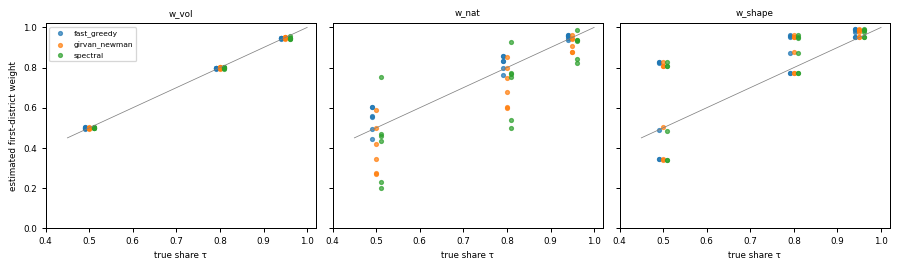

In [3]:
gate_banner()
DBAR = (PR[(PR["kind"] == "district") & (PR["window"] == "init")]
        .assign(m=lambda d: d[HC].mean(axis=1)).groupby(["districting", "signal"])["m"].first())
rows = []
for (m, cid), g in CP[CP["kind"].isin(["pair", "single"])].groupby(["districting", "comp_id"]):
    names = NAMES[m]
    g = g.set_index("drift").reindex(names)
    parts = g["parts"].dropna().iloc[0].split("|")
    tau = float(g["tau"].dropna().iloc[0])
    gp_n, gp_s = g["g_nat"].clip(lower=0), g["g_shape"].clip(lower=0)
    vol = gp_n * DBAR.loc[m].reindex(names)
    rows.append({"districting": m, "comp_id": cid, "kind": g["kind"].dropna().iloc[0], "tau": tau,
                 "first": parts[0], "w_vol": vol[parts[0]] / vol.sum(), "w_nat": gp_n[parts[0]] / gp_n.sum(),
                 "w_shape": gp_s[parts[0]] / gp_s.sum(),
                 "outside_vol": 1 - vol[parts].sum() / vol.sum(), "outside_shape": 1 - gp_s[parts].sum() / gp_s.sum()})
CW = pd.DataFrame(rows)
CW.to_parquet(OUT / "composite_weights.parquet", index=False)
q = CW[CW["kind"] == "pair"]
tab = q.melt(id_vars=["districting", "tau"], value_vars=["w_vol", "w_nat", "w_shape"], var_name="weight")
tab["err"] = tab["value"] - tab["tau"]
display(Markdown("**2a · first-district weight minus $\\tau$** (pair composites; every pair, every partition)"))
display(tab.groupby(["weight", "tau"])["err"].describe()[["count", "min", "50%", "max"]].round(3))
display(Markdown("**Weight on districts not in the gauge** (should be 0) and **own weight of single-district gauges** "
                 "(should be 1)"))
display(pd.DataFrame({"outside, vol (max)": CW.groupby("districting")["outside_vol"].max(),
                      "outside, shape (max)": CW.groupby("districting")["outside_shape"].max(),
                      "single own w_vol (min)": CW[CW["kind"] == "single"].groupby("districting")["w_vol"].min(),
                      "single own w_shape (min)": CW[CW["kind"] == "single"].groupby("districting")["w_shape"].min()}).round(4))
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for ax, col in zip(axes, ("w_vol", "w_nat", "w_shape")):
    for i, m in enumerate(PARTS):
        s = q[q["districting"] == m]
        ax.scatter(s["tau"] + (i - 1) * 0.01, s[col], s=10, alpha=0.7, label=m)
    ax.plot([0.45, 1], [0.45, 1], color="0.5", lw=0.6)
    ax.set(title=col, xlabel="true share τ", xlim=(0.4, 1.02), ylim=(0, 1.02))
axes[0].set_ylabel("estimated first-district weight"); axes[0].legend(fontsize=6)
fig.tight_layout(); plt.show()

**2b · Channel split.** Storage composites $=\text{base}_d+\lambda H_u$ (unit pump flow injected at
$r=\operatorname{sd}$ ratio 0.5, 1, 2). Errors are scaled by the composite's response to its **own** district's
drift, so a world where the truth is ≈ 0 does not blow the ratio up. `other drift` rows are the off-diagonal
case: the composite's response to a district it does not contain.

| estimate | of | definition |
|---|---|---|
| $g^{\text{sto}}_{\text{switch}}$ | $g^{\text{sto}}_{\text{true}}=\lambda\,g(H_u)$ | $\sum_p b_p\gamma_{p,k}$ from the switch fit |
| $g^{\text{dem,resid}}$ | $g^{\text{dem}}_{\text{true}}=g(\text{base}_d)$ | $g-g^{\text{sto}}_{\text{switch}}$ |
| $g^{\text{dem,own}}_{\text{switch}}$ | $g^{\text{dem}}_{\text{true}}$ | the regression's own coefficient $a_{k}$ |

**2b · absolute error / own-drift response** (quantiles over composites × worlds)

e_sto               e_dem_resid               e_dem_own              
                            0.50   0.90   0.99        0.50   0.90   0.99      0.50   0.90   0.99
districting   case                                                                              
fast_greedy   other drift  0.006  0.016  0.027       0.006  0.016  0.027     0.017  0.309  0.478
              own drift    0.005  0.013  0.014       0.005  0.013  0.014     0.044  0.473  0.501
girvan_newman other drift  0.005  0.013  0.020       0.005  0.013  0.020     0.019  0.131  0.218
              own drift    0.005  0.017  0.020       0.005  0.017  0.020     0.034  0.070  0.091
spectral      other drift  0.005  0.014  0.020       0.005  0.014  0.020     0.016  0.161  0.221
              own drift    0.006  0.017  0.018       0.006  0.017  0.018     0.023  0.271  0.284

by hub unit (q90 of `e_sto`)

districting,fast_greedy,girvan_newman,spectral
unit,,,
unit:T-3,0.015,0.014,0.016


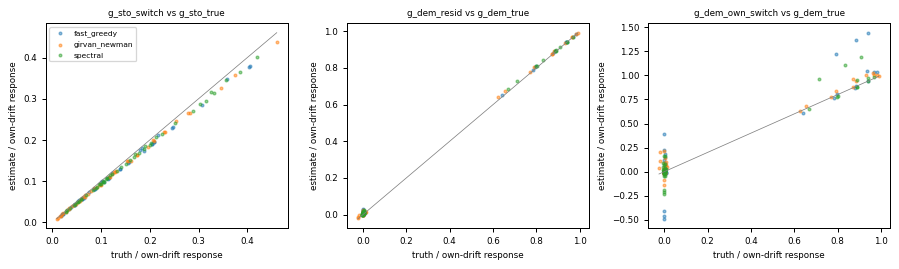

In [4]:
s = CP[CP["kind"] == "storage"].copy()
ref = s[s["parts"] == s["drift"]].set_index(["districting", "comp_id"])["g_nat"].abs().rename("scale")
s = s.join(ref, on=["districting", "comp_id"])
s["case"] = np.where(s["parts"] == s["drift"], "own drift", "other drift")
for c_, (est, tru) in {"e_sto": ("g_sto_switch", "g_sto_true"), "e_dem_resid": ("g_dem_resid", "g_dem_true"),
                       "e_dem_own": ("g_dem_own_switch", "g_dem_true")}.items():
    s[c_] = (s[est] - s[tru]).abs() / s["scale"]
CS = s
CS.to_parquet(OUT / "composite_split.parquet", index=False)
display(Markdown("**2b · absolute error / own-drift response** (quantiles over composites × worlds)"))
display(s.groupby(["districting", "case"])[["e_sto", "e_dem_resid", "e_dem_own"]]
        .quantile([0.5, 0.9, 0.99]).unstack().round(3))
display(Markdown("by hub unit (q90 of `e_sto`)"))
display(s.groupby(["districting", "unit"])["e_sto"].quantile(0.9).unstack(0).round(3))
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (est, tru) in zip(axes, (("g_sto_switch", "g_sto_true"), ("g_dem_resid", "g_dem_true"),
                                 ("g_dem_own_switch", "g_dem_true"))):
    for m in PARTS:
        z = s[s["districting"] == m]
        ax.scatter(z[tru] / z["scale"], z[est] / z["scale"], s=5, alpha=0.5, label=m)
    lim = [np.nanmin(s[tru] / s["scale"]), np.nanmax(s[tru] / s["scale"])]
    ax.plot(lim, lim, color="0.5", lw=0.6)
    ax.set(title=f"{est} vs {tru}", xlabel="truth / own-drift response", ylabel="estimate / own-drift response")
axes[0].legend(fontsize=6); fig.tight_layout(); plt.show()

**2c · What the composites cannot test.** They contain no tank-level effect and no storage path without a
switching pump. On real links both land in the residual demand channel. Exposure: share of storage-class links
whose best-correlated hub unit (settled $r^2$) is a unit without switching pumps.

In [5]:
U = UL.dropna(subset=["r2"]).merge(HU[["world", "unit", "signal"]], on=["world", "unit"])
best = U.loc[U.groupby(["world", "id"])["r2"].idxmax()].merge(LK[["world", "id", "storage"]], on=["world", "id"])
exp_ = (best[best["storage"]].groupby("districting")
        .apply(lambda g: pd.Series({"storage links": len(g),
                                    "best unit pumpless": (g["signal"] == "tankflow").mean(),
                                    "… and r² > 0.5": ((g["signal"] == "tankflow") & (g["r2"] > 0.5)).mean()})))
display(exp_.round(3))

,storage links,best unit pumpless,… and r² > 0.5
districting,,,
fast_greedy,1318.0,0.000,0.000
girvan_newman,1262.0,0.001,0.001
spectral,1293.0,0.000,0.000


 3 · Real sensors — does the channel model reproduce the readings?

Two models of a link's hourly flow, both evaluated on the last week of the init window (**fit**) and the last
week of the settled window (**out of window**: nothing is refitted after the drift):

| model | $\hat q_s(t)$ | fitted on | question |
|---|---|---|---|
| channel | $c_s+\sum_p b_{s,p}u_p(t)+\sum_d a_{s,d}D_d(t)$ | $b,a$: first differences over the whole init window (switch fit); $c_s$: init-week mean | does demand + pump state explain the reading, before **and after** the drift? |
| stack mixture | $\alpha_s+\beta_s\sum_k w_{s,k}D_k(t)$ | $\alpha,\beta$: init week | the original question — does the label mixture $w$ reproduce the reading? |

$R^2=1-\sum_t(q-\hat q)^2/\sum_t(q-\bar q)^2$ per week. Two expected limits, not fitting errors: the channel
model has no tank-level term (slow tank dynamics), and its demand term is a **fixed share of each district
total** — a link whose own few nodes convert land use during the drift (small branches of the drifting
district) no longer follows that share, although its projected response still does (branch ratio 0.94–1.03).
Settled $R^2$ is therefore also split by own-drift vs other worlds.

**3a · median $R^2$ by topology × class** (all links, all worlds)

R2_channel_init  R2_channel_settled  R2_mixture_init  R2_mixture_settled
districting   topo          class                                                                            
fast_greedy   branch        demand             0.952               0.908            0.954               0.931
              loop          demand             0.979               0.911            0.887               0.802
                            storage            0.999               0.989            0.046              -0.043
              source_bridge demand             0.977               0.243            0.623               0.739
                            storage            1.000               0.998            0.039              -0.033
girvan_newman branch        demand             0.949               0.895            0.953               0.922
              loop          demand             0.979               0.929            0.832               0.774
                            storage            0.998               0.990            0.118               0.045
              source_bridge demand             0.979               0.919            0.638               0.784
                            storage            0.999               0.997            0.031              -0.003
spectral      branch        demand             0.947               0.875            0.947               0.923
              loop          demand             0.982               0.850            0.856               0.828
                            storage            0.998               0.989            0.107              -0.014
              source_bridge demand             0.985              -0.004            0.888               0.948
                            storage            0.999               0.998            0.011              -0.046

**channel model, settled week: own-drift vs other worlds** (median, 5 % quantile)

0.50    0.05
districting   topo          own                 
fast_greedy   branch        False  0.921  -0.390
                            True   0.830 -12.415
              loop          False  0.984   0.548
                            True   0.965  -0.898
              source_bridge False  0.995  -2.753
                            True   0.998 -41.547
girvan_newman branch        False  0.916  -0.102
                            True   0.689 -15.533
              loop          False  0.984   0.421
                            True   0.969  -0.227
              source_bridge False  0.994   0.391
                            True   0.999   0.053
spectral      branch        False  0.901  -0.380
                            True  -0.106 -32.435
              loop          False  0.983   0.433
                            True   0.944  -0.911
              source_bridge False  0.995  -2.437
                            True   0.998  -6.418

**placed sensors** (median per slot class)

R2_channel_init  R2_channel_settled  R2_mixture_init  R2_mixture_settled
districting   placed                                                                          
fast_greedy   mixed             0.997               0.979            0.188               0.080
              pure              0.990               0.983            0.990               0.987
girvan_newman mixed             0.986               0.944            0.302               0.212
              pure              0.993               0.980            0.993               0.982
spectral      mixed             0.998               0.991            0.370               0.101
              pure              0.994               0.992            0.995               0.994

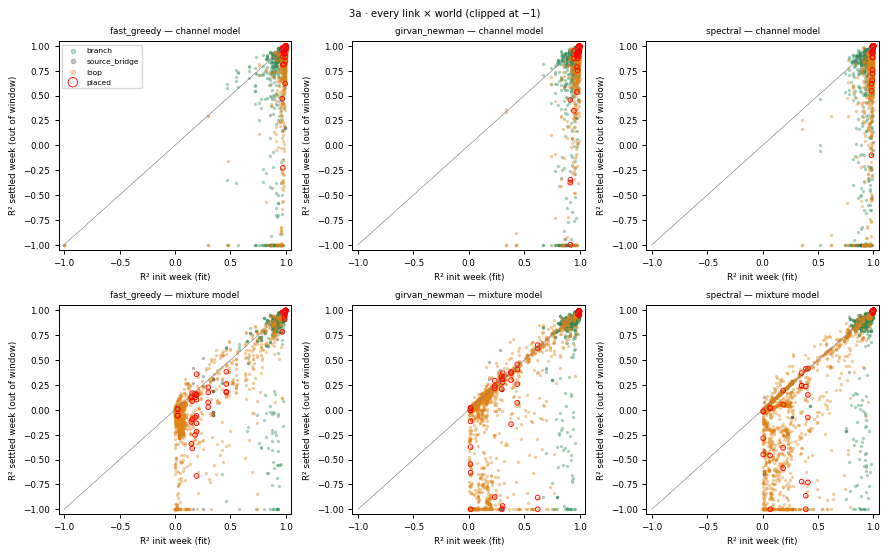

In [6]:
gate_banner()
SW = DP["series_week"]
TC = [c for c in SW.columns if c.startswith("t")]
SB = DP["switch_b"]
SAa = DP["switch_a"]


def r2w(y, yh):
    tot = ((y - y.mean(axis=1, keepdims=True)) ** 2).sum(axis=1)
    return np.where(tot > 1e-12, 1 - ((y - yh) ** 2).sum(axis=1) / np.where(tot > 1e-12, tot, 1), np.nan)


REC, SER = [], {}
for wr in WORLDS.itertuples():
    sw = SW[SW["world"] == wr.world]
    names = NAMES[wr.districting]
    get = lambda kind, win: sw[(sw["kind"] == kind) & (sw["window"] == win)].set_index("signal")[TC]
    Qi, Qf = get("link", "init"), get("link", "settled")
    ids = Qi.index
    Qf = Qf.loc[ids]
    Di, Df = get("district", "init").loc[names].to_numpy(float), get("district", "settled").loc[names].to_numpy(float)
    b = SB[SB["world"] == wr.world].pivot(index="id", columns="pump", values="b").reindex(ids)
    pumps = list(b.columns)
    Hi, Hf = get("hub", "init"), get("hub", "settled")
    Ui = Hi.loc[[f"pump:{p}" for p in pumps]].to_numpy(float) if pumps else np.zeros((0, len(TC)))
    Uf = Hf.loc[[f"pump:{p}" for p in pumps]].to_numpy(float) if pumps else np.zeros((0, len(TC)))
    a = SAa[SAa["world"] == wr.world].pivot(index="id", columns="district", values="a").reindex(ids)[names].to_numpy(float)
    B = b.to_numpy(float) if pumps else np.zeros((len(ids), 0))
    Pi, Pf = B @ Ui + a @ Di, B @ Uf + a @ Df
    qi, qf = Qi.to_numpy(float), Qf.to_numpy(float)
    c = (qi - Pi).mean(axis=1, keepdims=True)
    W = LB[LB["districting"] == wr.districting].set_index("id").reindex(ids)[[f"w_{d}" for d in names]].fillna(0).to_numpy(float)
    Xi, Xf = W @ Di, W @ Df
    al, be = np.full(len(ids), np.nan), np.full(len(ids), np.nan)
    for r_ in range(len(ids)):
        if np.std(Xi[r_]) > 1e-12:
            be[r_], al[r_] = np.polyfit(Xi[r_], qi[r_], 1)
    Wi, Wf = al[:, None] + be[:, None] * Xi, al[:, None] + be[:, None] * Xf
    REC.append(pd.DataFrame({"world": wr.world, "districting": wr.districting, "drift": wr.drift, "id": ids,
                             "R2_channel_init": r2w(qi, c + Pi), "R2_channel_settled": r2w(qf, c + Pf),
                             "R2_mixture_init": r2w(qi, Wi), "R2_mixture_settled": r2w(qf, Wf)}))
    SER[wr.world] = {"ids": list(ids), "q": np.hstack([qi, qf]), "chan": np.hstack([c + Pi, c + Pf]),
                     "mix": np.hstack([Wi, Wf]), "U": np.hstack([Ui, Uf]).sum(axis=0) if pumps else None,
                     "sto": np.hstack([B @ Ui, B @ Uf]), "dem": np.hstack([a @ Di, a @ Df])}
REC = pd.concat(REC, ignore_index=True).merge(LK[["world", "id", "storage", "topo", "tier"]], on=["world", "id"], how="left")
REC["placed"] = [PLACED.get((w, i)) for w, i in zip(REC["world"], REC["id"])]
REC.to_parquet(OUT / "reconstruction.parquet", index=False)
REC["class"] = np.where(REC["storage"], "storage", "demand")
REC["own"] = [h == d for h, d in zip(REC.merge(LB[["districting", "id", "home"]], on=["districting", "id"], how="left")["home"], REC["drift"])]
display(Markdown("**3a · median $R^2$ by topology × class** (all links, all worlds)"))
display(REC.groupby(["districting", "topo", "class"])[["R2_channel_init", "R2_channel_settled", "R2_mixture_init",
                                                       "R2_mixture_settled"]].median().round(3))
display(Markdown("**channel model, settled week: own-drift vs other worlds** (median, 5 % quantile)"))
display(REC.groupby(["districting", "topo", "own"])["R2_channel_settled"].quantile([0.5, 0.05]).unstack().round(3))
display(Markdown("**placed sensors** (median per slot class)"))
display(REC.dropna(subset=["placed"]).groupby(["districting", "placed"])[
    ["R2_channel_init", "R2_channel_settled", "R2_mixture_init", "R2_mixture_settled"]].median().round(3))

fig, axes = plt.subplots(2, len(PARTS), figsize=(3.3 * len(PARTS), 6.2), squeeze=False)
for c_, m in enumerate(PARTS):
    z = REC[REC["districting"] == m]
    for r_, mod in enumerate(("channel", "mixture")):
        ax = axes[r_, c_]
        for tp_, col in TOPO_COL.items():
            t = z[z["topo"] == tp_]
            ax.scatter(t[f"R2_{mod}_init"].clip(-1, 1), t[f"R2_{mod}_settled"].clip(-1, 1), s=3, alpha=0.3, color=col, label=tp_)
        p = z.dropna(subset=["placed"])
        ax.scatter(p[f"R2_{mod}_init"].clip(-1, 1), p[f"R2_{mod}_settled"].clip(-1, 1), s=14, facecolors="none",
                   edgecolors="r", lw=0.7, label="placed")
        ax.plot([-1, 1], [-1, 1], color="0.5", lw=0.5)
        ax.set(title=f"{m} — {mod} model", xlabel="R² init week (fit)", ylabel="R² settled week (out of window)",
               xlim=(-1.05, 1.05), ylim=(-1.05, 1.05))
axes[0, 0].legend(fontsize=6, markerscale=2)
fig.suptitle("3a · every link × world (clipped at −1)", fontsize=8); fig.tight_layout(); plt.show()

**3b · Placed sensors, every world.** Black: reading. Blue: channel model. Orange dashed: stack mixture.
Left half: init week (fit); right half: settled week (out of window); grey shading: pump(s) on.

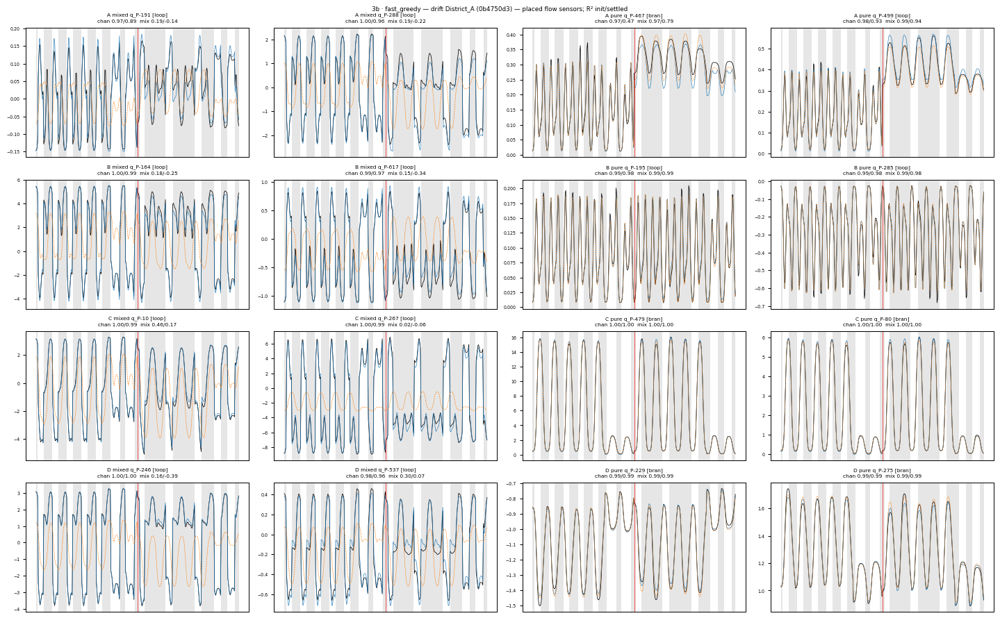

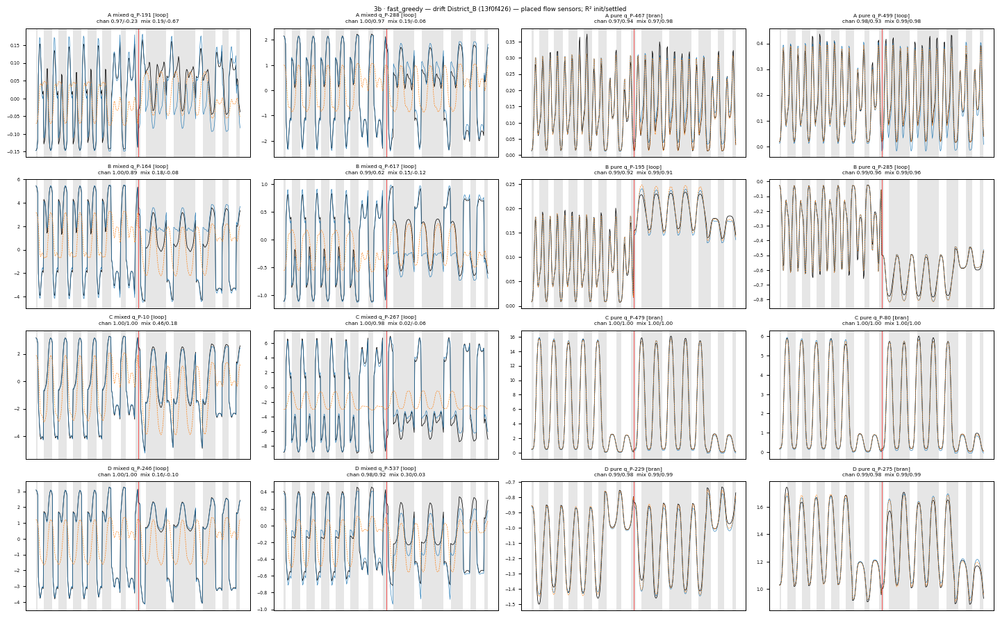

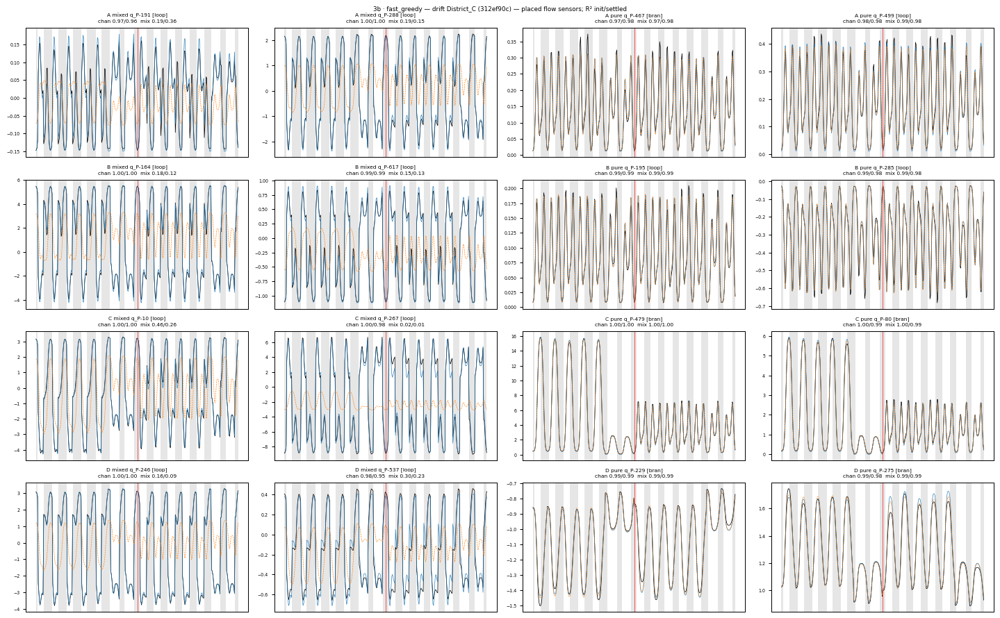

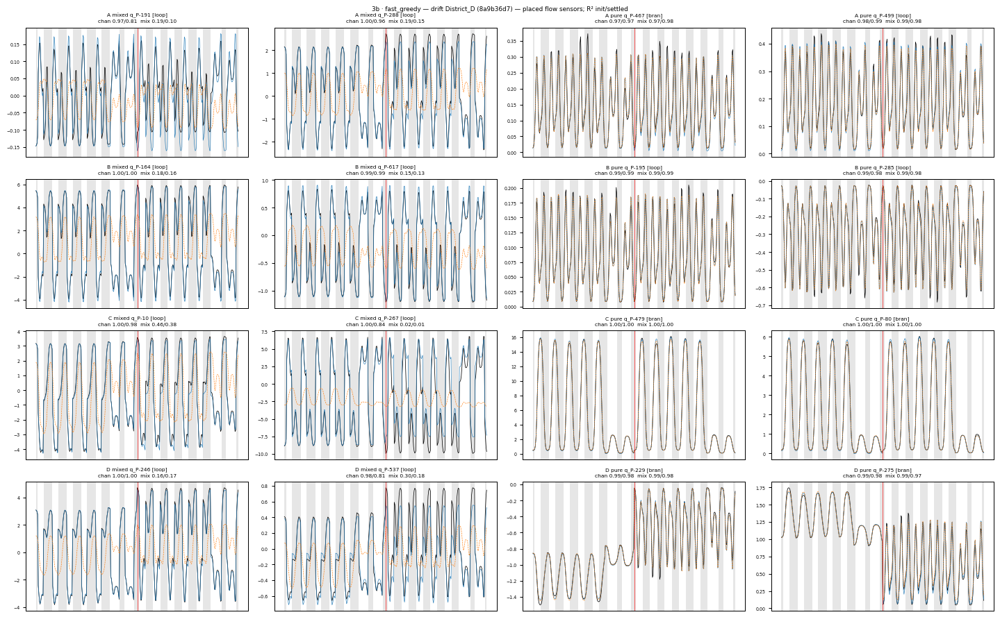

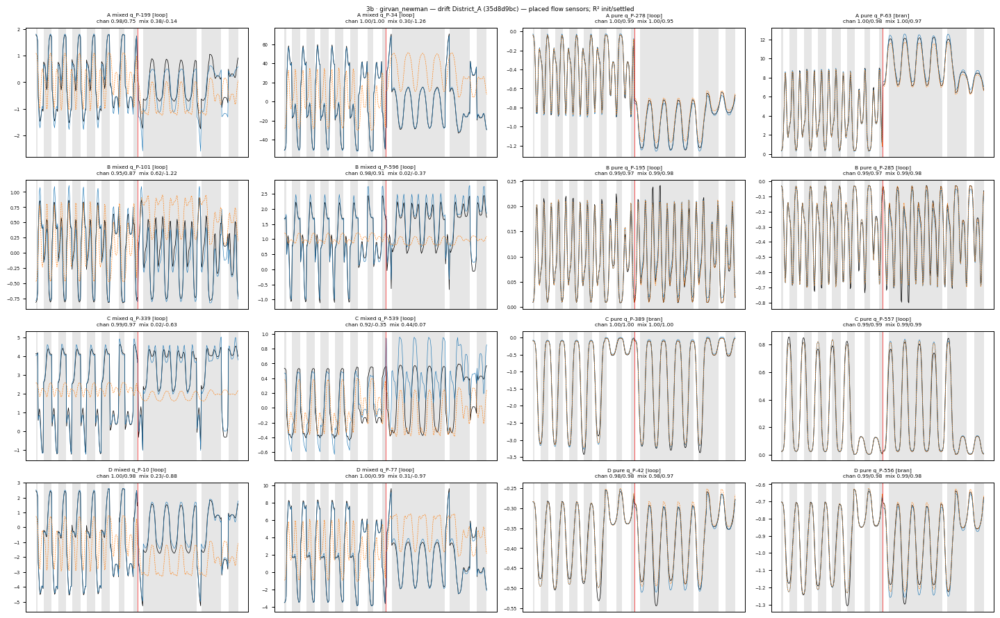

...

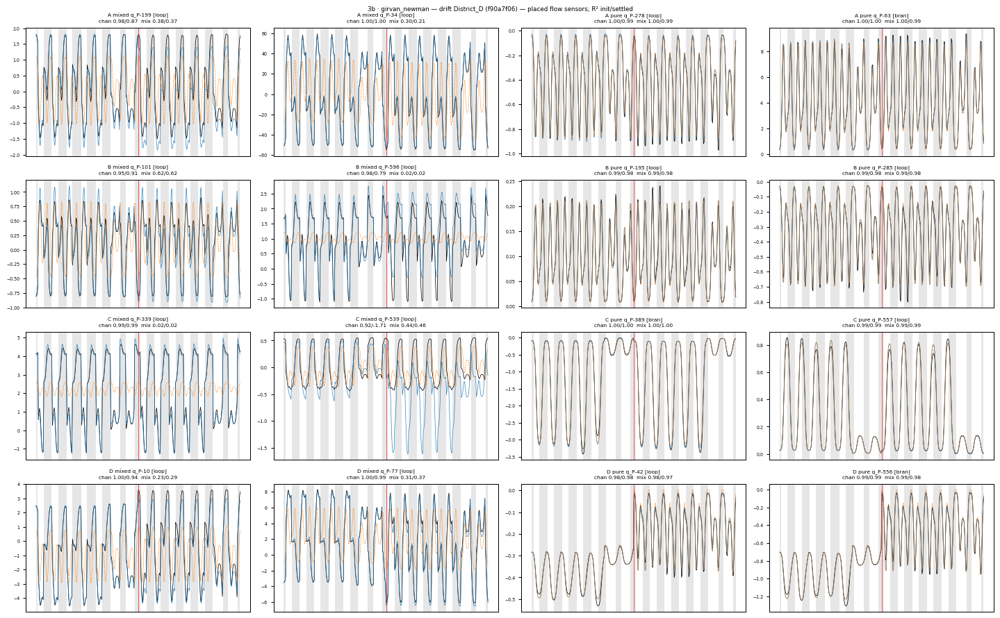

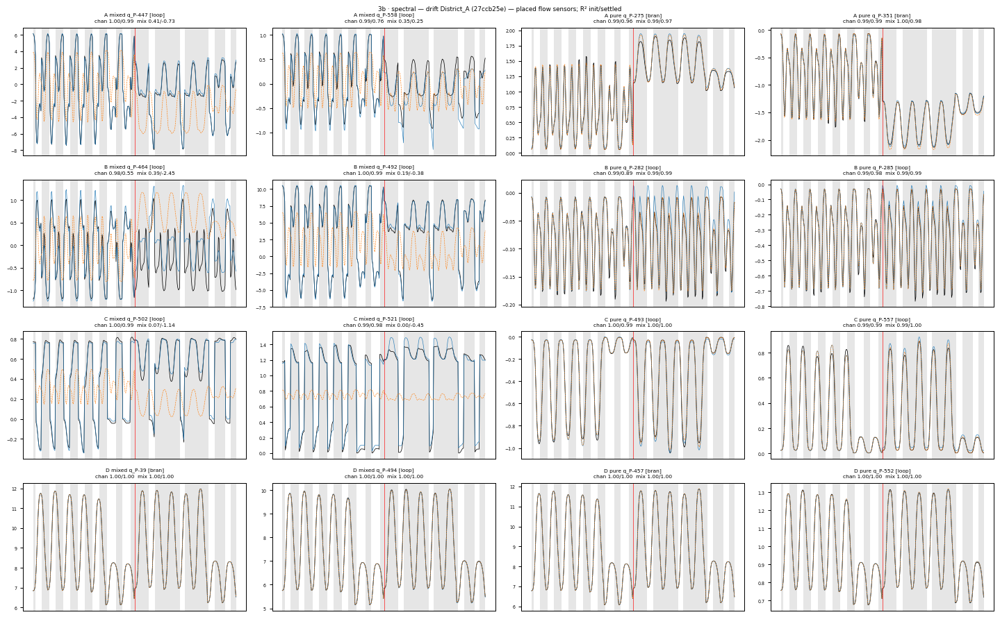

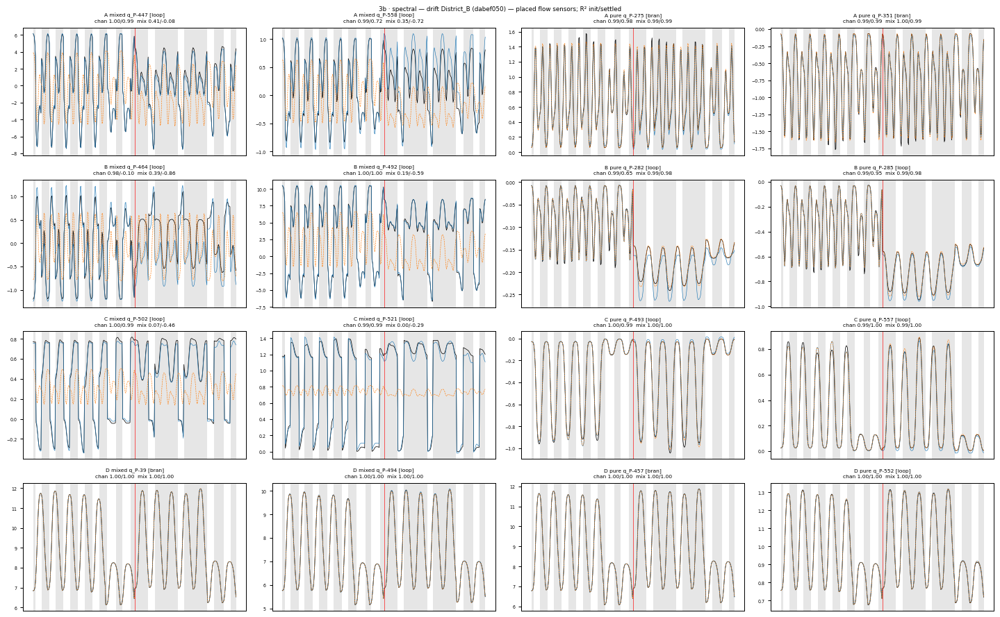

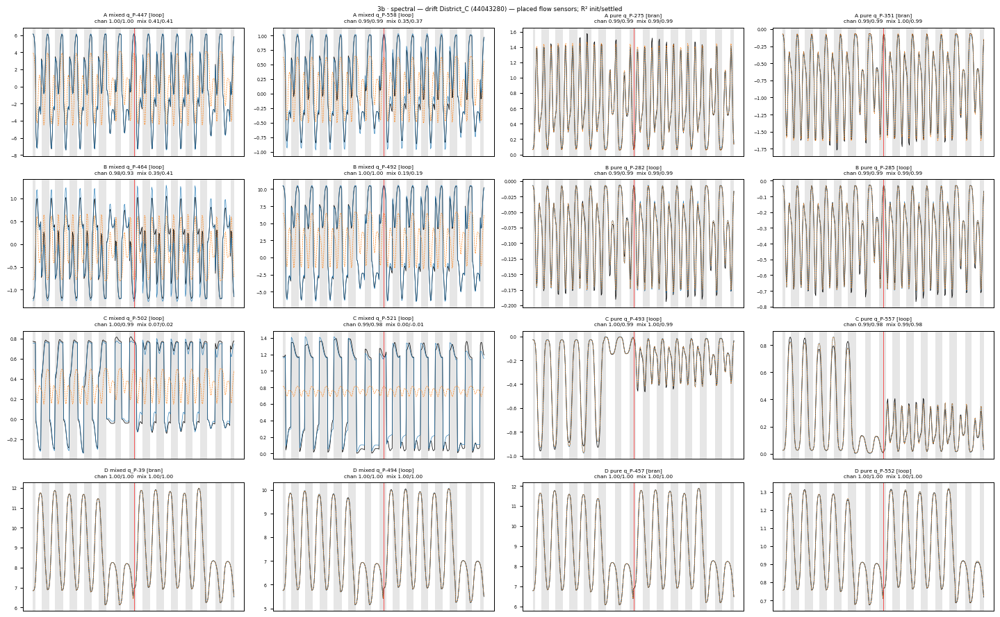

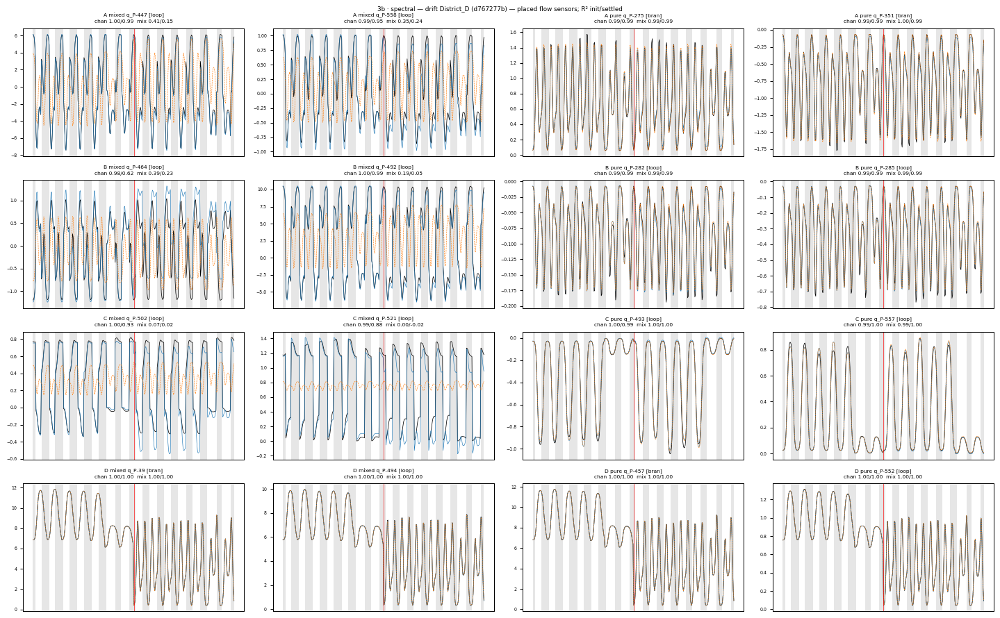

In [7]:
def panel(ax, w, sid, title):
    S_ = SER[w]
    i = S_["ids"].index(sid)
    t = np.arange(S_["q"].shape[1])
    if S_["U"] is not None:
        ax.fill_between(t, 0, 1, where=S_["U"] > 0, color="0.9", transform=ax.get_xaxis_transform(), lw=0)
    ax.plot(t, S_["q"][i], color="k", lw=0.6)
    ax.plot(t, S_["chan"][i], color="tab:blue", lw=0.5)
    ax.plot(t, S_["mix"][i], color="tab:orange", lw=0.5, ls="--")
    ax.axvline(len(TC), color="r", lw=0.5)
    ax.set_title(title, fontsize=6); ax.set_xticks([]); ax.tick_params(labelsize=5)


for wr in WORLDS.itertuples():
    p = REC[(REC["world"] == wr.world) & REC["placed"].notna()].sort_values(["placed", "id"])
    p = p.merge(PL[PL["world"] == wr.world][["id", "district"]], on="id").sort_values(["district", "placed"])
    n = len(p)
    cols = 4 if n <= 16 else 5
    fig, axes = plt.subplots(int(np.ceil(n / cols)), cols, figsize=(4 * cols, 2.5 * np.ceil(n / cols)), squeeze=False)
    for ax, r_ in zip(axes.flat, p.itertuples()):
        panel(ax, wr.world, r_.id, f"{r_.district[-1]} {r_.placed} {r_.id} [{r_.topo[:4]}]\n"
              f"chan {r_.R2_channel_init:.2f}/{r_.R2_channel_settled:.2f}  mix {r_.R2_mixture_init:.2f}/{r_.R2_mixture_settled:.2f}")
    for ax in list(axes.flat)[n:]:
        ax.axis("off")
    fig.suptitle(f"3b · {wr.districting} — drift {wr.drift} ({wr.world}) — placed flow sensors; R² init/settled", fontsize=7)
    fig.tight_layout(); plt.show()

**3c · Rule-selected population sensors.** Per partition, per stratum (topology × class), the links at the
10 / 50 / 90 % quantiles of channel-model settled $R^2$, pooled over worlds — what the typical and the
worst-explained links look like, without hand-picking.

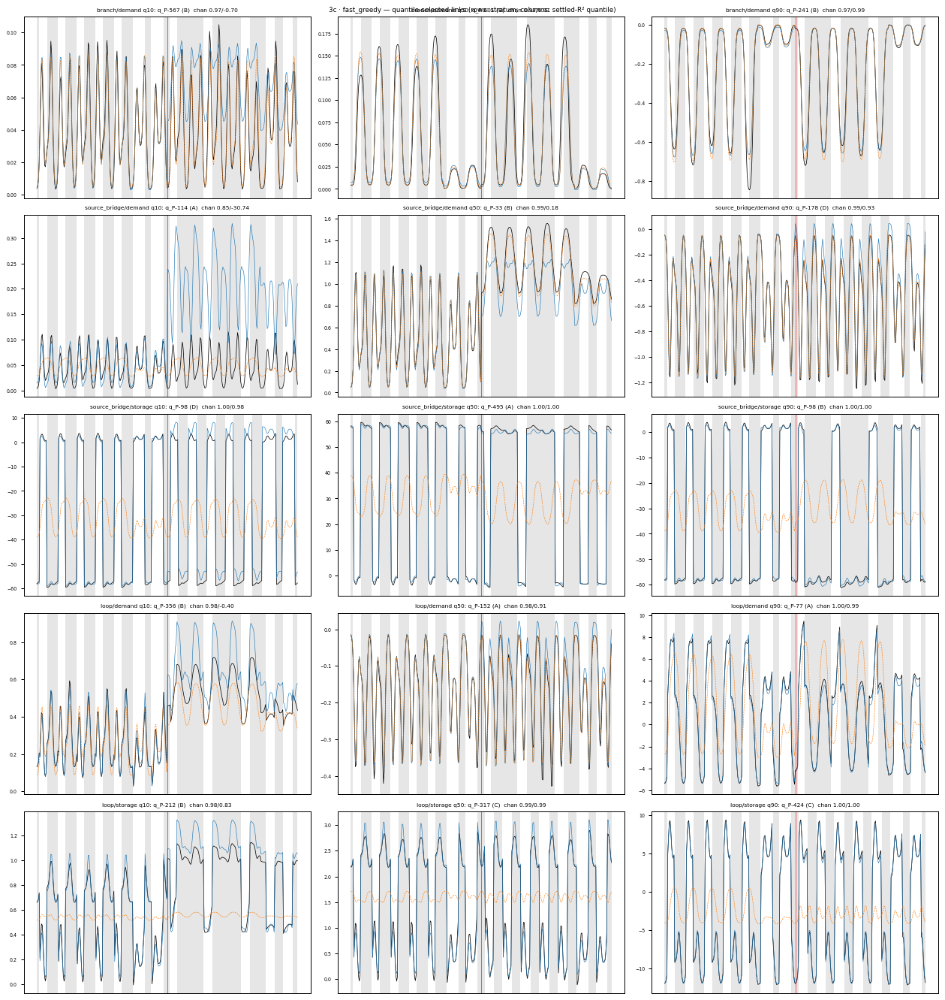

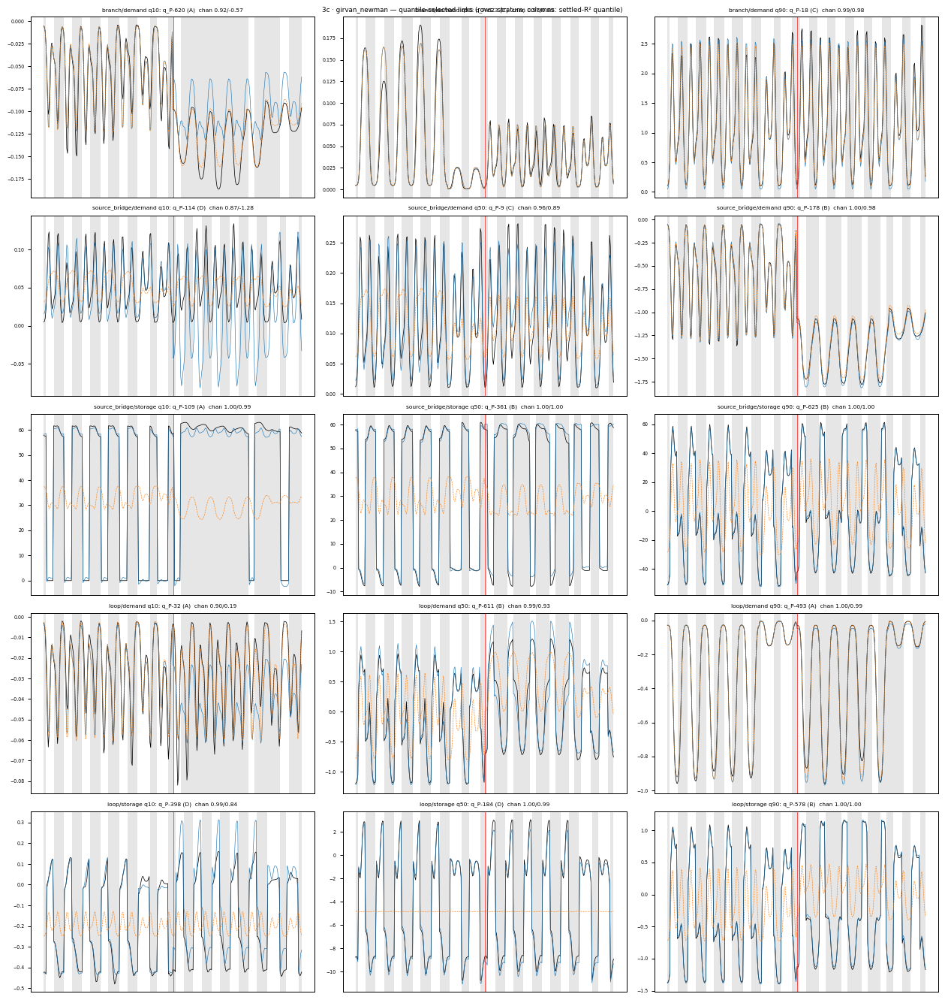

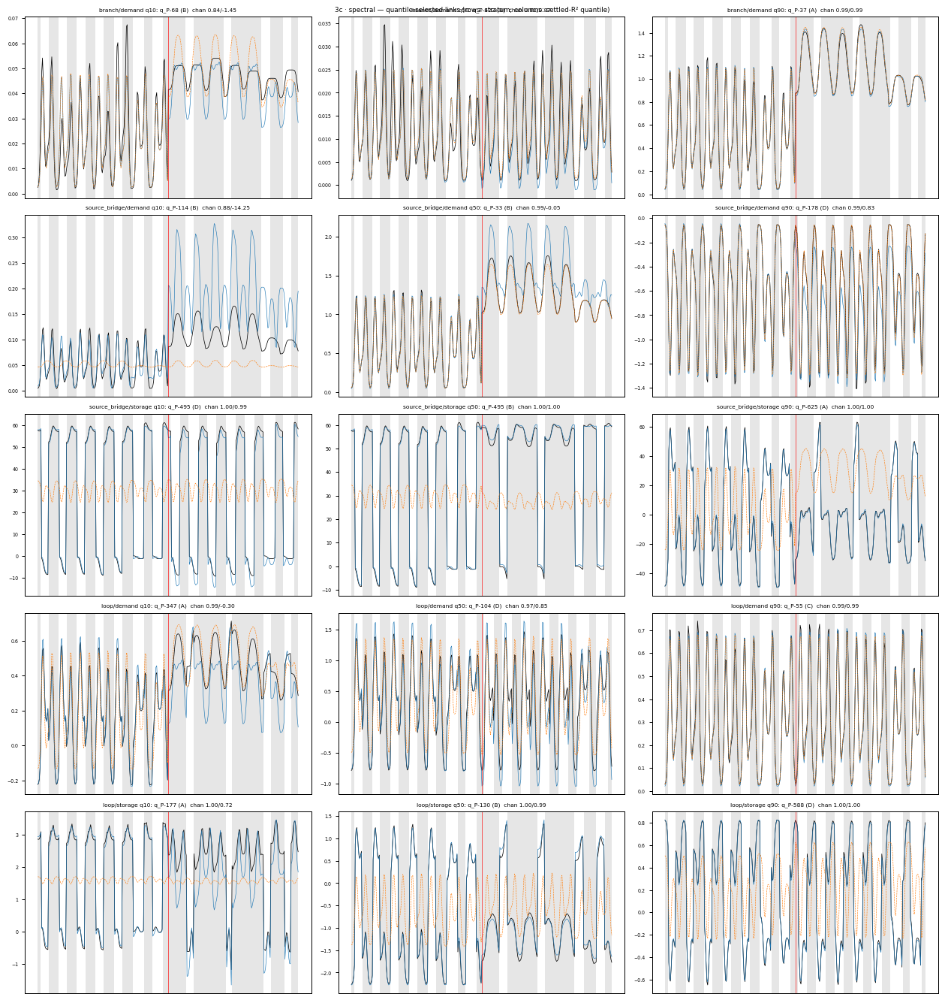

In [8]:
for m in PARTS:
    z = REC[(REC["districting"] == m)].dropna(subset=["R2_channel_settled"])
    strata = [(t, c) for t in ("branch", "source_bridge", "loop") for c in ("demand", "storage")
              if len(z[(z["topo"] == t) & (z["class"] == c)])]
    fig, axes = plt.subplots(len(strata), 3, figsize=(14, 3 * len(strata)), squeeze=False)
    for r_, (t, c) in enumerate(strata):
        s_ = z[(z["topo"] == t) & (z["class"] == c)].sort_values("R2_channel_settled").reset_index(drop=True)
        for c_, qn in enumerate((0.1, 0.5, 0.9)):
            row = s_.iloc[int(qn * (len(s_) - 1))]
            panel(axes[r_, c_], row["world"], row["id"],
                  f"{t}/{c} q{int(qn * 100)}: {row['id']} ({row['drift'][-1]})  chan {row['R2_channel_init']:.2f}/"
                  f"{row['R2_channel_settled']:.2f}")
    fig.suptitle(f"3c · {m} — quantile-selected links (rows: stratum; columns: settled-R² quantile)", fontsize=7)
    fig.tight_layout(); plt.show()

 4 · Interventional dependence — which sensors carry district $k$'s change, by channel

**Channels** (native, per link $s$, drift world $k$; validated in §1–§2):
$g_s=g^{\text{dem}}_s+g^{\text{sto}}_s$, $g^{\text{sto}}_s=\sum_u g^{\text{sto}}_{s,u}$ (switch-identified, per hub unit),
$g^{\text{dem}}_s=g_s-g^{\text{sto}}_s$ (residual; exact on branches by G4; contains tank-level and pumpless-unit
effects, §2c). Shape space has no linear split: only the total $g^{\text{shape}}_s$.
Every gain is **oriented** along the link's init mean flow ($\times\operatorname{sign}\bar q_s$): $g>0$ means more flow in
the direction the link normally carries; $g<0$ an inverse response. The `.inp` orientation is arbitrary and
would otherwise flip the sign of a third of the links.

**Significance.** $\sigma_s$ = RMS of the link's null gains (init split-half difference projected on each world's
$\Delta D_k$; one draw per world, $K$ per link) and $z=\lvert g\rvert/\sigma_s$. The threshold $c$ is **calibrated on
branch links**, where the truth is exact: negatives = branches of non-drifting districts (true response 0 up to
those districts' own month-to-month variation), positives = branches of the drifting district. $c$ = the
$(1-\text{FPR})$ quantile of the negatives' $z$, per partition and space; the same $c$ is applied to every link
and to each channel term. Its transfer from branches to loops is an assumption (the scale $\sigma_s$ is
link-specific; the multiplier is not).

In [9]:
gate_banner()
SIG = (LK.groupby(["districting", "id"])
       .agg(sig_nat=("gn_null", lambda x: float(np.sqrt(np.mean(np.square(x))))),
            sig_shape=("g_null", lambda x: float(np.sqrt(np.nanmean(np.square(x)))))).reset_index())
EV = (SL[WKEY + ["id", "element", "g_nat", "g_sto_switch", "g_dem_resid", "g_dem_own_switch", "g_dem_cross_switch"]]
      .merge(LK[["world", "id", "g", "storage", "tier", "home", "purity", "topo"]], on=["world", "id"])
      .merge(SIG, on=["districting", "id"]))
EV = EV.rename(columns={"g_nat": "g_tot", "g_sto_switch": "g_sto", "g_dem_resid": "g_dem", "g": "g_shape"})
for ch in ("tot", "dem", "sto"):
    EV[f"z_{ch}"] = EV[f"g_{ch}"].abs() / EV["sig_nat"]
EV["z_shape"] = EV["g_shape"].abs() / EV["sig_shape"]
dom = BR.copy()
Wx = np.nan_to_num(dom[[f"w_exact_init_{d}" for d in NM_ALL]].to_numpy(float), nan=-1)
dom["exact_home"] = np.array(NM_ALL)[Wx.argmax(axis=1)]
EV = EV.merge(dom[["world", "id", "exact_home", "g_exact_nat"]], on=["world", "id"], how="left")
ORI = (PR[(PR["kind"] == "link") & (PR["window"] == "init")].assign(mu=lambda d: d[HC].mean(axis=1))
       .drop_duplicates(["districting", "signal"]).set_index(["districting", "signal"])["mu"])
EV["orient"] = np.sign([ORI.get((m, i), np.nan) for m, i in zip(EV["districting"], EV["id"])])
EV["orient"] = EV["orient"].replace(0, 1.0)
for c_ in ("g_tot", "g_dem", "g_sto", "g_shape", "g_dem_own_switch", "g_dem_cross_switch", "g_exact_nat"):
    EV[c_] = EV[c_] * EV["orient"]
EV["own"] = EV["home"] == EV["drift"]
EV["mean_abs_flow"] = [abs(ORI.get((m, i), np.nan)) for m, i in zip(EV["districting"], EV["id"])]
MED_Q = EV.drop_duplicates(["districting", "id"])["mean_abs_flow"].median()
EV["placed"] = [PLACED.get((w, i)) for w, i in zip(EV["world"], EV["id"])]

cal = []
C = {}
for m in PARTS:
    b = EV[(EV["districting"] == m) & (EV["topo"] == "branch")]
    neg, pos = b[b["exact_home"] != b["drift"]], b[b["exact_home"] == b["drift"]]
    for sp_, z in (("native", "z_tot"), ("shape", "z_shape")):
        c = float(neg[z].quantile(1 - FPR))
        C[(m, sp_)] = c
        cal.append({"districting": m, "space": sp_, "c": c, "negatives": len(neg), "positives": len(pos),
                    "TPR": float((pos[z] > c).mean()), "pos z median": float(pos[z].median()),
                    "neg z median": float(neg[z].median()),
                    "storage term > c on branches": float((b["z_sto"] > c).mean()) if sp_ == "native" else np.nan})
display(Markdown("**4a · calibration on branch links**"))
display(pd.DataFrame(cal).round(3))
EV["c_nat"] = EV["districting"].map(lambda m: C[(m, "native")])
EV["c_shape"] = EV["districting"].map(lambda m: C[(m, "shape")])
for ch in ("tot", "dem", "sto"):
    EV[f"sig_{ch}"] = EV[f"z_{ch}"] > EV["c_nat"]
EV["sig_shape"] = EV["z_shape"] > EV["c_shape"]
EV["channel"] = np.select([EV["sig_dem"] & EV["sig_sto"], EV["sig_dem"], EV["sig_sto"]],
                          ["both", "demand", "storage"], "none")

# unit attribution of the storage term
ul = UL.dropna(subset=["g_sto_unit"]).assign(a=lambda d: d["g_sto_unit"].abs())
tot_u = ul.groupby(["world", "id"])["a"].transform("sum")
ul["unit_share"] = ul["a"] / tot_u.where(tot_u > 0)
top = ul.loc[ul.groupby(["world", "id"])["a"].idxmax(), ["world", "id", "unit", "unit_share"]]
EV = EV.merge(top.rename(columns={"unit": "sto_unit", "unit_share": "sto_unit_share"}), on=["world", "id"], how="left")
pl_r2 = (UL.merge(HU[["world", "unit", "signal"]], on=["world", "unit"]).query("signal == 'tankflow'")
         .groupby(["world", "id"])["r2"].max().rename("r2_pumpless"))
EV = EV.join(pl_r2, on=["world", "id"])
display(Markdown("**Share of links significant, by channel** (per world; own = the drifting district's links)"))
display(EV.groupby(["districting", "drift", "own"])["channel"].value_counts(normalize=True)
        .unstack().fillna(0).round(3))

**4a · calibration on branch links**

,districting,space,c,negatives,positives,TPR,pos z median,neg z median,storage term > c on branches
0,fast_greedy,native,7.544,495,165,1.0,204.045,0.800,0.0
1,fast_greedy,shape,5.460,495,165,1.0,743.229,0.759,NaN
2,girvan_newman,native,8.953,495,165,1.0,191.004,0.718,0.0
3,girvan_newman,shape,8.099,495,165,1.0,614.687,0.755,NaN
4,spectral,native,5.639,495,165,1.0,175.472,0.937,0.0
5,spectral,shape,6.759,495,165,1.0,416.303,0.704,NaN


**Share of links significant, by channel** (per world; own = the drifting district's links)

channel                          both  demand   none  storage
districting   drift      own                                 
fast_greedy   District_A False  0.314   0.027  0.540    0.120
                         True   0.718   0.189  0.009    0.084
              District_B False  0.547   0.041  0.326    0.085
                         True   0.411   0.495  0.062    0.031
              District_C False  0.046   0.008  0.356    0.590
                         True   0.204   0.776  0.000    0.020
              District_D False  0.414   0.058  0.404    0.124
                         True   0.616   0.372  0.000    0.012
girvan_newman District_A False  0.090   0.014  0.639    0.257
                         True   0.590   0.260  0.022    0.127
              District_B False  0.552   0.074  0.310    0.064
                         True   0.118   0.824  0.059    0.000
              District_C False  0.541   0.023  0.428    0.008
                         True   0.582   0.344  0.025    0.049
              District_D False  0.050   0.029  0.462    0.459
                         True   0.170   0.830  0.000    0.000
spectral      District_A False  0.427   0.027  0.364    0.182
                         True   0.481   0.336  0.022    0.160
              District_B False  0.450   0.018  0.411    0.120
                         True   0.637   0.289  0.033    0.041
              District_C False  0.622   0.028  0.320    0.030
                         True   0.471   0.471  0.000    0.059
              District_D False  0.016   0.019  0.318    0.647
                         True   0.000   1.000  0.000    0.000

**4b · Anatomy of every matrix entry.** Panel $(j,k)$: every link homed in $j$ in the world where $k$ drifts,
its $z$ for the demand (left) and storage (right) channel; colour = topology; red ring = placed sensor; dashed
line = the calibrated $c$. Title: share of $j$'s links significant per channel. An off-diagonal entry carried by
many independent links looks different from one carried by copies of one hub signal (a tight band on the
storage side).

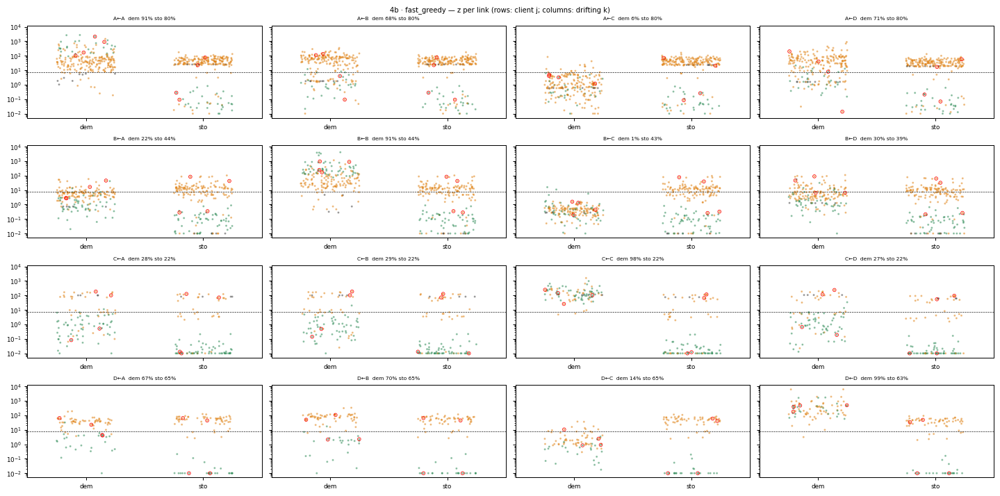

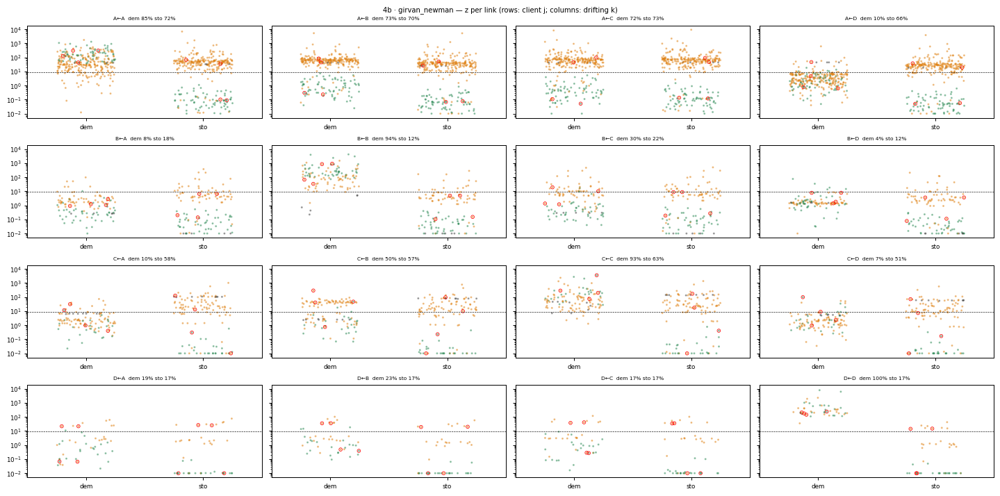

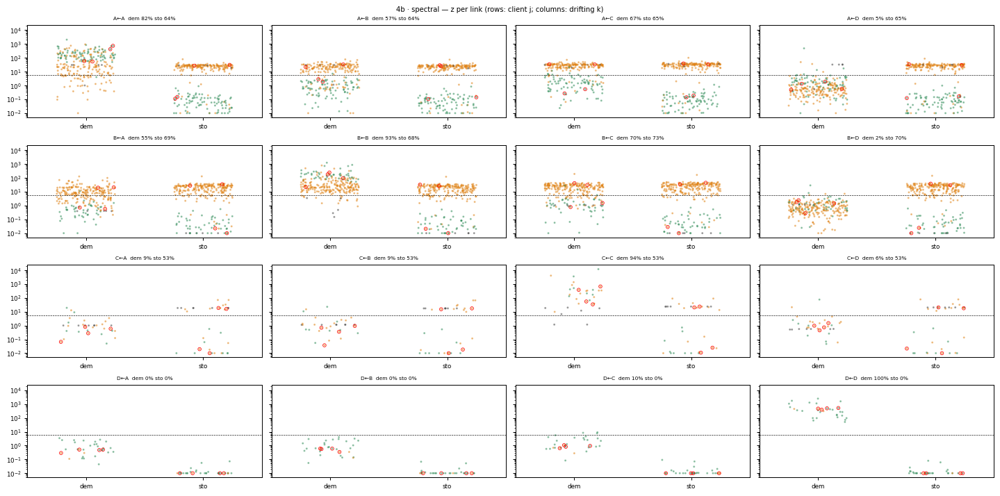

In [10]:
rng = np.random.default_rng(0)
for m in PARTS:
    names = NAMES[m]
    K = len(names)
    fig, axes = plt.subplots(K, K, figsize=(4 * K, 2 * K), sharey=True, squeeze=False)
    for i, j in enumerate(names):
        for k_, k in enumerate(names):
            ax = axes[i, k_]
            e = EV[(EV["districting"] == m) & (EV["drift"] == k) & (EV["home"] == j)]
            for x0, ch in ((0, "z_dem"), (1, "z_sto")):
                xs = x0 + rng.uniform(-0.25, 0.25, len(e))
                ax.scatter(xs, e[ch].clip(lower=1e-2), s=2, alpha=0.4, c=e["topo"].map(TOPO_COL).fillna("b"))
                p = e["placed"].notna().to_numpy()
                ax.scatter(xs[p], e[ch].clip(lower=1e-2)[p], s=14, facecolors="none", edgecolors="r", lw=0.6)
            ax.axhline(C[(m, "native")], color="k", ls="--", lw=0.5)
            ax.set_yscale("log"); ax.set_xticks([0, 1], ["dem", "sto"]); ax.set_xlim(-0.5, 1.5)
            ax.set_title(f"{j[-1]}←{k[-1]}  dem {e['sig_dem'].mean():.0%} sto {e['sig_sto'].mean():.0%}", fontsize=6)
    fig.suptitle(f"4b · {m} — z per link (rows: client j; columns: drifting k)", fontsize=8)
    fig.tight_layout(); plt.show()

**4c · Matrices.** $D_{\text{ch}}[j,k]=\operatorname{mean}_{s\in j}\lvert g_{\text{ch},s,k}\rvert$, divided by the
**total** diagonal $D_{\text{tot}}[k,k]$ of the same population (response read by column); second line: share
of $j$'s links significant in that channel. Grey numbers: share below the FPR (not distinguishable from the
null at population level). Population = every link; placed = the FL client's sensors (3–4 per client). Colour
scale per panel. **Channels can cancel**: on storage links the demand and storage terms often have opposite
signs (more demand → less tank fill per hour, longer pumping), so $\lvert g^{\text{dem}}\rvert+\lvert g^{\text{sto}}\rvert\ge\lvert g\rvert$
and a channel matrix can exceed the total one. Native magnitudes are dominated by trunk links.

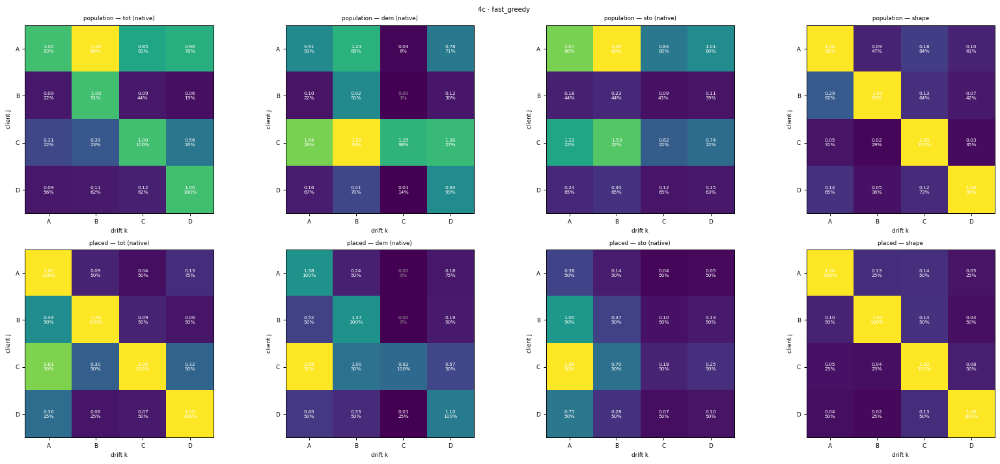

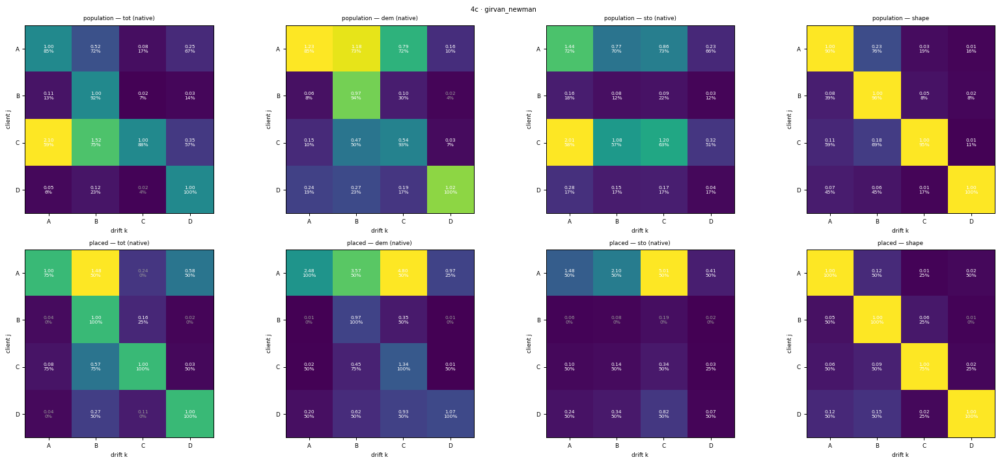

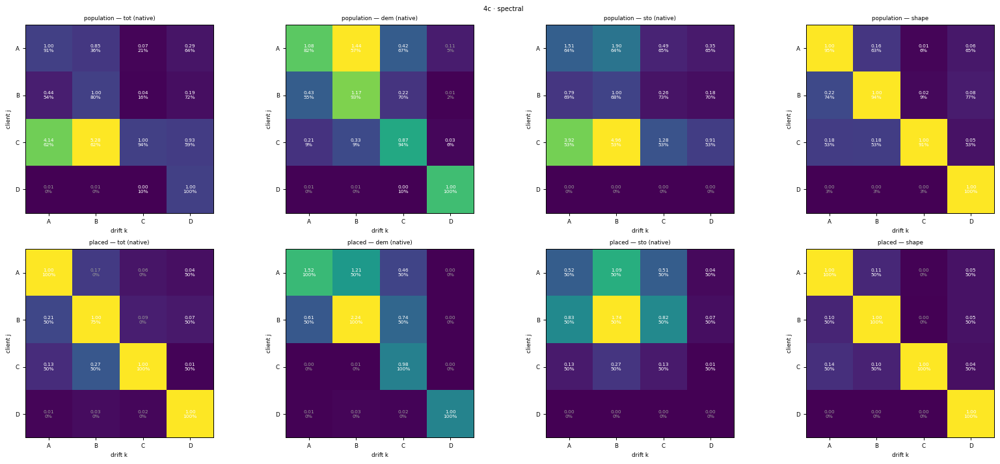

**Off-diagonal responses ($j\ne k$, significant): channel × v2 class × sign pattern** (share of significant off-diagonal link-world rows)

districting                          fast_greedy  girvan_newman  spectral
cls           channel signs                                              
demand-class  both    opposite sign        0.072          0.070     0.096
                      same sign            0.003          0.009     0.002
              demand                       0.047          0.050     0.035
              storage                      0.026          0.035     0.062
storage-class both    opposite sign        0.423          0.453     0.436
                      same sign            0.038          0.042     0.019
              demand                       0.009          0.016     0.000
              storage                      0.382          0.325     0.349

In [11]:
MAT = []
for m in PARTS:
    names = NAMES[m]
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for r_, (lev, e0) in enumerate((("population", EV), ("placed", EV[EV["placed"].notna()]))):
        e0 = e0[e0["districting"] == m]
        mats = {}
        for ch, gcol, scol in (("tot", "g_tot", "sig_tot"), ("dem", "g_dem", "sig_dem"), ("sto", "g_sto", "sig_sto"),
                               ("shape", "g_shape", "sig_shape")):
            Dm = e0.assign(v=e0[gcol].abs()).pivot_table(index="home", columns="drift", values="v", aggfunc="mean").reindex(index=names, columns=names)
            Fm = e0.pivot_table(index="home", columns="drift", values=scol, aggfunc="mean").reindex(index=names, columns=names)
            mats[ch] = (Dm, Fm)
        for c_, ch in enumerate(("tot", "dem", "sto", "shape")):
            Dm, Fm = mats[ch]
            diag = np.diag(mats["shape" if ch == "shape" else "tot"][0].to_numpy(float))
            R = Dm / diag[None, :]
            heat(axes[r_, c_], R, f"{lev} — {ch}" + (" (native)" if ch != "shape" else ""),
                 note=Fm.map(lambda v: f"{v:.0%}"), grey=Fm < FPR)
            for j in names:
                for k in names:
                    MAT.append({"districting": m, "level": lev, "channel": ch, "j": j, "k": k,
                                "D": Dm.at[j, k], "R": R.at[j, k], "frac_sig": Fm.at[j, k]})
    fig.suptitle(f"4c · {m}", fontsize=8); fig.tight_layout(); plt.show()
MAT = pd.DataFrame(MAT)
MAT.to_parquet(OUT / "matrices_interventional.parquet", index=False)
off = EV[~EV["own"] & (EV["channel"] != "none")]
display(Markdown("**Off-diagonal responses ($j\\ne k$, significant): channel × v2 class × sign pattern** "
                 "(share of significant off-diagonal link-world rows)"))
off = off.assign(cls=np.where(off["storage"], "storage-class", "demand-class"),
                 signs=np.where(off["channel"] == "both",
                                np.where(np.sign(off["g_dem"]) == np.sign(off["g_sto"]), "same sign", "opposite sign"), ""))
display(off.groupby("districting").apply(lambda g: g.groupby(["cls", "channel", "signs"]).size() / len(g))
        .unstack(0).fillna(0).round(3))

**4d · Where the response is.** One map per world: links coloured by the channel in which they respond
significantly to $k$'s drift; small dots = nodes of the drifting district; black squares = tanks, red
triangles = pumps; zoomed to the junctions (a long source main may leave the frame).

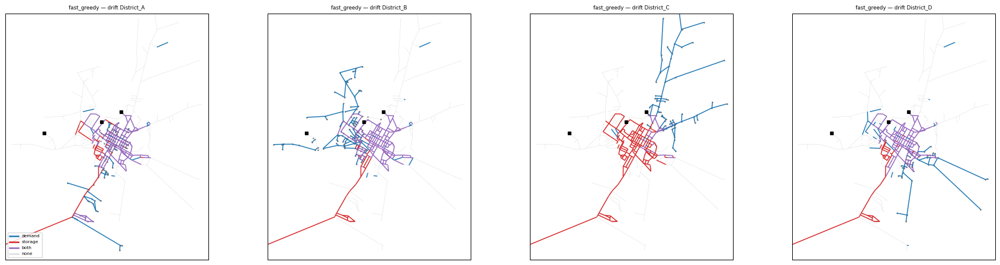

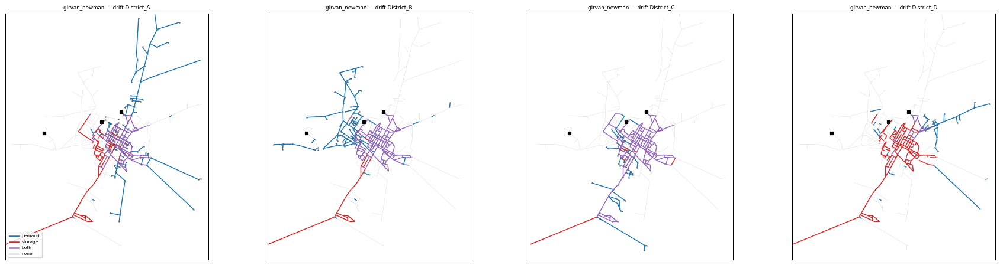

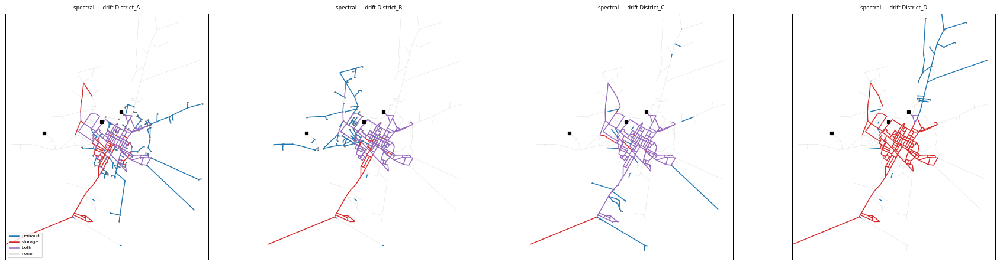

In [12]:
NODES = DP["nodes"]
ND = DP["node_district"]
CH_COL = {"demand": "#1f77b4", "storage": "#d62728", "both": "#9467bd", "none": "#dddddd"}
net = WORLDS["network"].iloc[0]
nd = NODES[NODES["network"] == net].set_index("node")
tp_ = TP[(TP["network"] == net) & TP["start"].isin(nd.index) & TP["end"].isin(nd.index)]
SEG = {r.element: [(nd.at[r.start, "x"], nd.at[r.start, "y"]), (nd.at[r.end, "x"], nd.at[r.end, "y"])]
       for r in tp_.itertuples()}
for m in PARTS:
    names = NAMES[m]
    fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 5), squeeze=False)
    for ax, k in zip(axes[0], names):
        e = EV[(EV["districting"] == m) & (EV["drift"] == k)].set_index("element")
        segs = [SEG[x] for x in SEG]
        cols = [CH_COL[e.at[x, "channel"]] if x in e.index else "#f4f4f4" for x in SEG]
        wid = [1.2 if (x in e.index and e.at[x, "channel"] != "none") else 0.4 for x in SEG]
        ax.add_collection(LineCollection(segs, colors=cols, linewidths=wid))
        kn = ND[(ND["districting"] == m) & (ND["district"] == k)]["node"]
        kn = nd.loc[nd.index.intersection(kn)]
        ax.scatter(kn["x"], kn["y"], s=1, color="0.4")
        for kind, mk, col in (("tank", "s", "k"), ("reservoir", "D", "k")):
            q_ = nd[nd["kind"] == kind]
            ax.plot(q_["x"], q_["y"], mk, color=col, ms=4)
        pm = tp_[tp_["link_type"].str.contains("Pump")]
        for r in pm.itertuples():
            ax.plot((nd.at[r.start, "x"] + nd.at[r.end, "x"]) / 2, (nd.at[r.start, "y"] + nd.at[r.end, "y"]) / 2, "^", color="r", ms=4)
        jn = nd[nd["kind"] == "junction"]
        (x0, x1), (y0, y1) = jn["x"].quantile([0.005, 0.995]), jn["y"].quantile([0.005, 0.995])
        px, py = 0.05 * (x1 - x0), 0.05 * (y1 - y0)
        ax.set_xlim(x0 - px, x1 + px); ax.set_ylim(y0 - py, y1 + py)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{m} — drift {k}", fontsize=7)
    axes[0, 0].legend(handles=[Line2D([0], [0], color=c, lw=2, label=l) for l, c in CH_COL.items()], fontsize=6, loc="lower left")
    fig.tight_layout(); plt.show()

**4e · The chain through the transition months.** Per world: the drifting district's demand change
(black), every hub element (grey), and for each other client $j$ the median monthly detection ratio of its
storage-class links (solid) and demand-class links (dashed). Ratio = monthly change score / the link's init
threshold (v2 S1); 1 = threshold. If $k$ reaches $j$ through storage, $j$'s storage links follow the hub
while its demand links stay below 1.

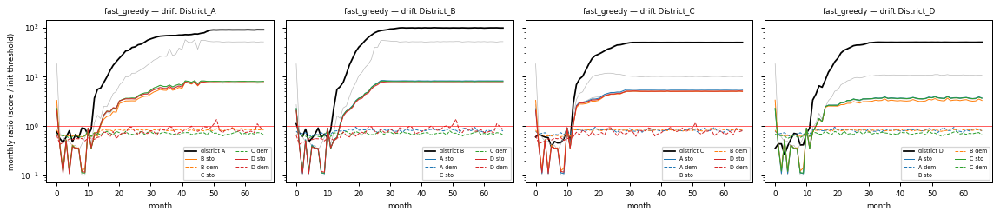

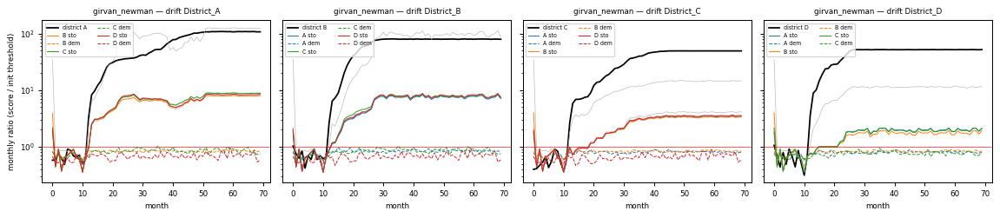

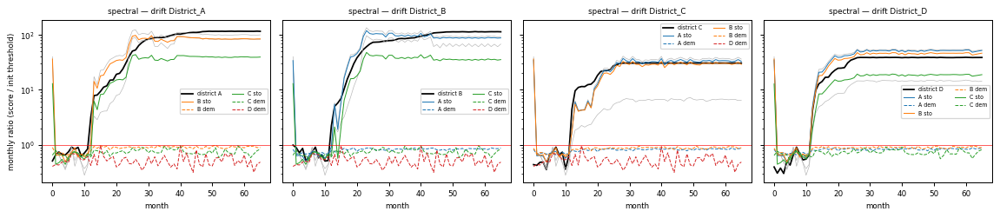

In [13]:
MLk, MH, MD = V2["monthly_links"], V2["monthly_hub"], V2["monthly_districts"]
cls = LK[["world", "id", "storage", "home"]]
for m in PARTS:
    names = NAMES[m]
    fig, axes = plt.subplots(1, len(names), figsize=(3.2 * len(names), 2.8), squeeze=False, sharey=True)
    for ax, k in zip(axes[0], names):
        wid = WORLDS[(WORLDS["districting"] == m) & (WORLDS["drift"] == k)]["world"].iloc[0]
        d = MD[(MD["world"] == wid) & (MD["district"] == k)].sort_values("month")
        ax.plot(d["month"], d["ratio"].clip(lower=1e-2), color="k", lw=1.4, label=f"district {k[-1]}")
        for el, h in MH[MH["world"] == wid].groupby("element"):
            ax.plot(h["month"], h["ratio"].clip(lower=1e-2), color="0.7", lw=0.5)
        ml = MLk[MLk["world"] == wid].merge(cls, on=["world", "id"])
        for i_, j in enumerate(n for n in names if n != k):
            col = plt.cm.tab10(names.index(j))
            for st, ls in ((True, "-"), (False, "--")):
                g = ml[(ml["home"] == j) & (ml["storage"] == st)].groupby("month")["ratio"].median()
                if len(g):
                    ax.plot(g.index, g.clip(lower=1e-2), ls=ls, color=col, lw=0.8, label=f"{j[-1]} {'sto' if st else 'dem'}")
        ax.axhline(1, color="r", lw=0.5)
        ax.set_yscale("log"); ax.set_title(f"{m} — drift {k}", fontsize=7); ax.set_xlabel("month")
        ax.legend(fontsize=5, ncol=2)
    axes[0, 0].set_ylabel("monthly ratio (score / init threshold)")
    fig.tight_layout(); plt.show()

 5 · Observational similarity — which clients look alike without any intervention

Init window (normal operation, no drift; shared by the worlds of a partition), hourly series of every link.
$\rho_{s,r}=\lvert\operatorname{corr}(x_s,x_r)\rvert$ on two bases: `raw` (as measured) and `anom` (each series minus
its hour-of-week mean — the daily / weekly cycle common to every demand-fed link removed).

| quantity | definition |
|---|---|
| $O^{\text{pop}}[j,k]$ | median of $\rho_{s,r}$ over $s\in j$, $r\in k$, $s\ne r$ (every link; = v2 `D3`, checked below) |
| $O^{\text{placed}}[j,k]$ | **mean** of $\rho_{s,r}$ over the placed sensors of the world (what the FL clients can compare; with 3–4 sensors per client a median hides the minority that carries the coupling) |
| $o_{s,k}$ | median of $\rho_{s,r}$ over $r$ placed in $k$, $r\ne s$ — per sensor, written to the evidence table |

**G8 · population $O$ reproduces v2 `D3_observational`:** max abs difference 0.0e+00 over 96 entries — pass

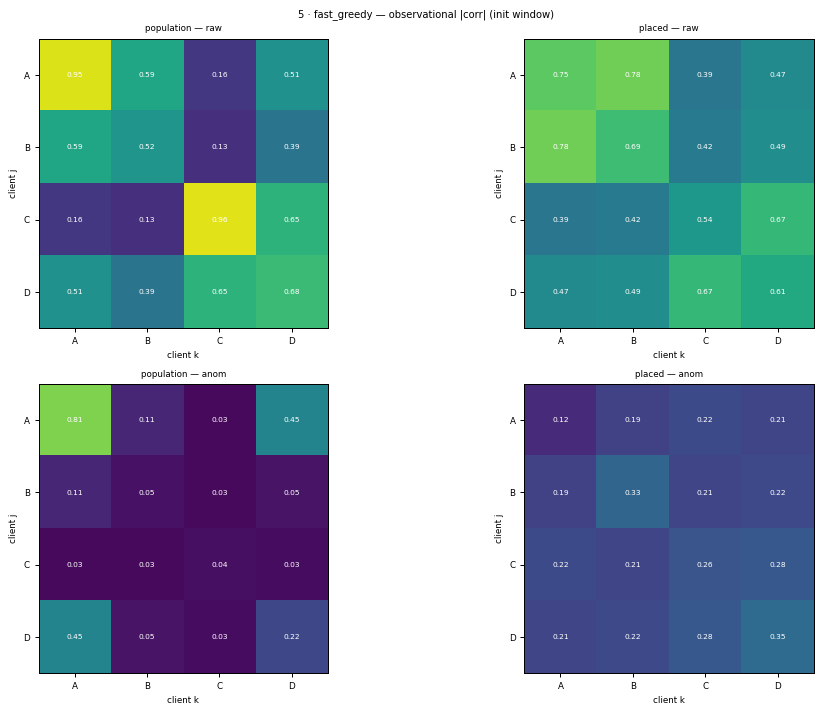

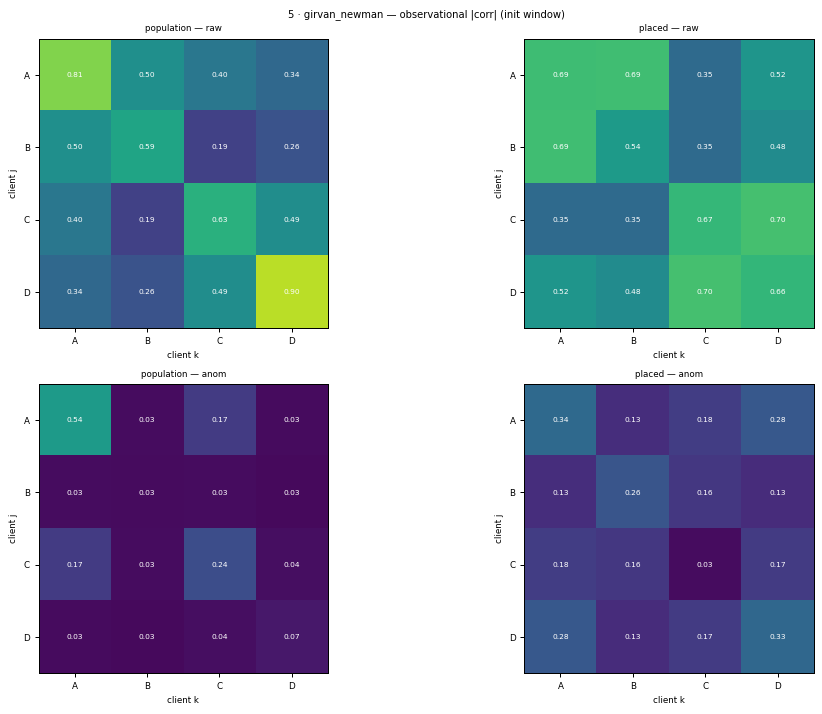

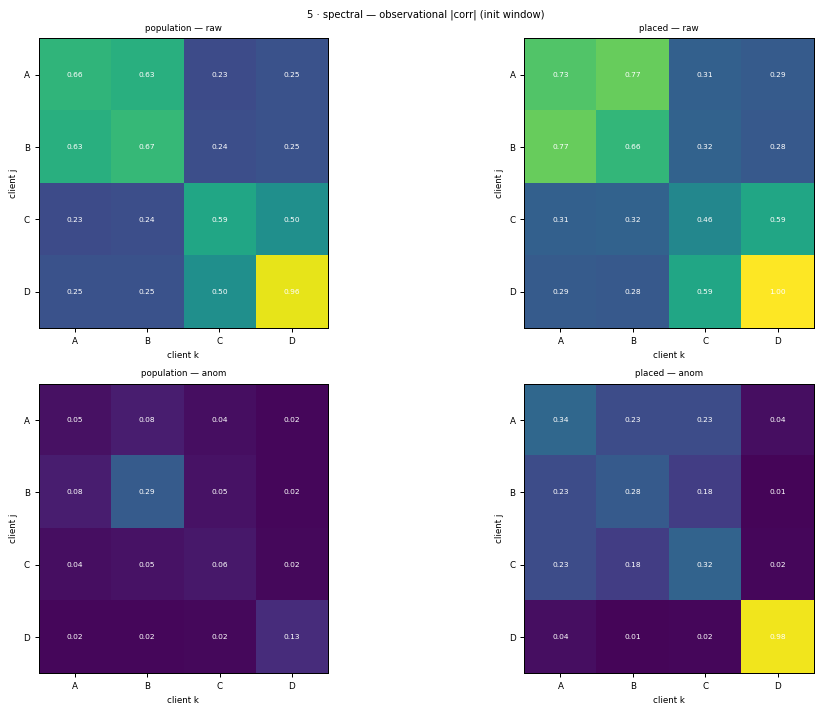

In [14]:
gate_banner()
D3 = V2["D3_observational"]
OBS, OSEN, chk, OPAIRS = [], [], [], []
for m in PARTS:
    z = np.load(BASE / "storage_class_eval_v2" / f"obs_input_{WORLDS['network'].iloc[0]}_{m}.npz", allow_pickle=True)
    ids, home = [str(i) for i in z["ids"]], np.asarray(z["home"]).astype(str)
    ix = {s: i for i, s in enumerate(ids)}
    names = NAMES[m]
    CM = {}
    for basis in ("raw", "anom"):
        X = z[basis].astype(float)
        sd = X.std(axis=0)
        Zs = np.nan_to_num((X - X.mean(axis=0)) / np.where(sd > 1e-12, sd, np.nan))
        Cb = np.abs(Zs.T @ Zs / len(Zs))
        np.fill_diagonal(Cb, np.nan)
        CM[basis] = Cb
        iu = np.triu_indices(len(ids), k=1)
        OPAIRS.append(pd.DataFrame({"districting": m, "basis": basis, "s": np.asarray(ids)[iu[0]],
                                    "r": np.asarray(ids)[iu[1]], "home_s": home[iu[0]], "home_r": home[iu[1]],
                                    "abs_corr": Cb[iu].astype(np.float32)}))
        for j in names:
            for k in names:
                v = float(np.nanmedian(Cb[np.ix_(home == j, home == k)]))
                OBS.append({"districting": m, "world": None, "level": "population", "basis": basis, "j": j, "k": k, "O": v})
                ref = D3[(D3["districting"] == m) & (D3["signal"] == basis) & (D3["subset"] == "all") & (D3["j"] == j) & (D3["k"] == k)]["O"]
                if len(ref):
                    chk.append(abs(v - float(ref.iloc[0])))
    for wr in WORLDS[WORLDS["districting"] == m].itertuples():
        pw = PL[PL["world"] == wr.world]
        for basis in ("raw", "anom"):
            Cb = CM[basis]
            for j in names:
                sj = [ix[s] for s in pw[pw["district"] == j]["id"] if s in ix]
                for k in names:
                    sk = [ix[s] for s in pw[pw["district"] == k]["id"] if s in ix]
                    OBS.append({"districting": m, "world": wr.world, "level": "placed", "basis": basis, "j": j, "k": k,
                                "O": float(np.nanmean(Cb[np.ix_(sj, sk)])) if sj and sk else np.nan})
        for k in names:
            sk = [ix[s] for s in pw[pw["district"] == k]["id"] if s in ix]
            for basis in ("raw", "anom"):
                o = np.nanmedian(CM[basis][:, sk], axis=1) if sk else np.full(len(ids), np.nan)
                OSEN.append(pd.DataFrame({"world": wr.world, "id": ids, "k": k, "basis": basis, "o": o}))
OBS, OSEN = pd.DataFrame(OBS), pd.concat(OSEN, ignore_index=True)
v = max(chk)
display(Markdown(f"**G8 · population $O$ reproduces v2 `D3_observational`:** max abs difference {v:.1e} "
                 f"over {len(chk)} entries — {'pass' if v < 1e-6 else 'FAIL'}"))
assert v < 1e-6, "observational recompute does not match v2"
OBS.to_parquet(OUT / "matrices_observational.parquet", index=False)
for m in PARTS:
    names = NAMES[m]
    ws = WORLDS[WORLDS["districting"] == m]
    if PL[PL["districting"] == m].groupby("world")["id"].apply(frozenset).nunique() == 1:
        ws = ws.head(1)                                  # identical placement in every world: shown once
    fig, axes = plt.subplots(2, 1 + len(ws), figsize=(6 * (1 + len(ws)), 8), squeeze=False)
    for r_, basis in enumerate(("raw", "anom")):
        o = OBS[(OBS["districting"] == m) & (OBS["basis"] == basis)]
        heat(axes[r_, 0], o[o["level"] == "population"].pivot(index="j", columns="k", values="O").reindex(index=names, columns=names),
             f"population — {basis}", vmax=1, xlab="client k")
        for c_, wr in enumerate(ws.itertuples(), start=1):
            heat(axes[r_, c_], o[o["world"] == wr.world].pivot(index="j", columns="k", values="O").reindex(index=names, columns=names),
                 f"placed — {basis}" + ("" if len(ws) == 1 else f" ({wr.drift[-1]} world)"), vmax=1, xlab="client k")
    fig.suptitle(f"5 · {m} — observational |corr| (init window)", fontsize=8); fig.tight_layout(); plt.show()

 6 · Per-sensor evidence and the label proposal

**Demand mixture of a sensor, from its own gains.** §2a showed that native gains weighted by district volume
recover the true volumetric share exactly on known mixtures. Applied to the **demand channel** of every real
link, using its $K$ gains (one per drift world of the partition):
$$v_{s,k}=\frac{\max(g^{\text{dem}}_{s,k},0)\,\bar D_k\,\mathbb 1[z^{\text{dem}}_{s,k}>c]}{\sum_d\max(g^{\text{dem}}_{s,d},0)\,\bar D_d\,\mathbb 1[z^{\text{dem}}_{s,d}>c]}$$
(oriented gains; only significant gains count, so a non-drift world's noise is never normalised up to a share).
Undefined when no district has a significant positive demand gain. Inverse responses are not volume and are
kept separately: $v^-_s$ = significant negative demand mass / total significant demand mass. Checked here
against the exact share on branch links (truth) and against the stack's $w$ (the current label).

In [15]:
EV = EV.merge(DBAR.rename("Dbar").reset_index().rename(columns={"signal": "drift"}), on=["districting", "drift"], how="left")
EV["vd"] = EV["g_dem"].clip(lower=0) * EV["Dbar"] * EV["sig_dem"]
EV["vneg"] = (-EV["g_dem"]).clip(lower=0) * EV["Dbar"] * EV["sig_dem"]
EV["v_dem"] = EV["vd"] / EV.groupby(["districting", "id"])["vd"].transform("sum").where(lambda x: x > 0)
EV["v_inverse"] = EV.groupby(["districting", "id"])["vneg"].transform("sum") / \
    (EV.groupby(["districting", "id"])["vd"].transform("sum") + EV.groupby(["districting", "id"])["vneg"].transform("sum")).where(lambda x: x > 0)
VM = EV.pivot_table(index=["districting", "id"], columns="drift", values="v_dem", dropna=False)
chk6 = []
for m in PARTS:
    names = NAMES[m]
    vm = VM.loc[m][names]
    b = BR[BR["districting"] == m].drop_duplicates("id").set_index("id")
    wx = b[[f"w_exact_init_{d}" for d in names]].set_axis(names, axis=1)
    common = wx.index.intersection(vm.index)
    l1_ex = 0.5 * (vm.loc[common] - wx.loc[common]).abs().sum(axis=1)
    lab = LB[LB["districting"] == m].set_index("id")[[f"w_{d}" for d in names]].set_axis(names, axis=1)
    cm2 = lab.index.intersection(vm.index)
    cl = LK[LK["districting"] == m].drop_duplicates("id").set_index("id").reindex(cm2)
    l1_st = 0.5 * (vm.loc[cm2] - lab.loc[cm2]).abs().sum(axis=1).where(vm.loc[cm2].notna().any(axis=1))
    chk6.append({"districting": m, "branches": len(common), "L1 vs exact: median": l1_ex.median(),
                 "L1 vs exact: max": l1_ex.max(),
                 "L1 vs stack w: demand-class median": l1_st[~cl["storage"].astype(bool)].median(),
                 "L1 vs stack w: storage-class median": l1_st[cl["storage"].astype(bool)].median(),
                 "v undefined: demand-class": float(vm.loc[cm2][~cl["storage"].astype(bool)].isna().all(axis=1).mean()),
                 "v undefined: storage-class": float(vm.loc[cm2][cl["storage"].astype(bool)].isna().all(axis=1).mean()),
                 "dominant agrees with stack home (v defined)": float(
                     (vm.loc[cm2].dropna(how="all").idxmax(axis=1) == cl["home"].loc[vm.loc[cm2].dropna(how="all").index]).mean())})
display(Markdown("**6a · $v$ against the exact share (branches) and the stack's $w$** — "
                 "$\\tfrac12\\lVert v-w\\rVert_1$ (0 = identical, 1 = disjoint)"))
display(pd.DataFrame(chk6).round(3))

**6a · $v$ against the exact share (branches) and the stack's $w$** — $\tfrac12\lVert v-w\rVert_1$ (0 = identical, 1 = disjoint)

,districting,branches,L1 vs exact: median,L1 vs exact: max,L1 vs stack w: demand-class median,L1 vs stack w: storage-class median,v undefined: demand-class,v undefined: storage-class,dominant agrees with stack home (v defined)
0,fast_greedy,165,0.0,0.024,0.002,0.488,0.040,0.521,0.900
1,girvan_newman,165,0.0,0.034,0.004,0.482,0.038,0.570,0.874
2,spectral,165,0.0,0.026,0.003,0.308,0.039,0.659,0.931


**6b · Sensor quality flags** — conditions under which a sensor's label is not trustworthy, whatever its $z$:

| flag | rule | why |
|---|---|---|
| `dead` | $\lvert\bar q_s\rvert<10^{-3}\times$ the network's median link flow | a near-zero flow has no physical mixture; $z$ is relative to its own (tiny) noise |
| `pumpless` | settled $r^2$ on a unit without switching pumps $>0.5$ | that storage path is not identified (§2c) and lands in the demand channel |
| `poor fit` | median over the partition's worlds of the channel-model settled $R^2<0.5$ | the reading is not explained by demand + pump state (§3); the median ignores the one world where a link's own nodes convert |

In [16]:
REC2 = REC[["world", "id", "R2_channel_init", "R2_channel_settled", "R2_mixture_init", "R2_mixture_settled"]]
SE = EV.merge(REC2, on=["world", "id"], how="left")
SE["flag_dead"] = SE["mean_abs_flow"] < 1e-3 * MED_Q
SE["flag_pumpless"] = SE["r2_pumpless"].fillna(0) > 0.5
FLAGS = SE.groupby(["districting", "id"]).agg(flag_dead=("flag_dead", "any"), flag_pumpless=("flag_pumpless", "any"),
                                               flag_poor_fit=("R2_channel_settled", lambda x: x.median() < 0.5))
SE = SE.join(FLAGS["flag_poor_fit"], on=["districting", "id"])
fl = FLAGS.join(PL.drop_duplicates(["districting", "id"]).set_index(["districting", "id"])["slot_class"], how="left")
display(Markdown(f"median link flow {MED_Q:.3g} L/s → `dead` below {1e-3 * MED_Q:.2g} L/s. Share flagged:"))
display(Markdown("population (share of links)"))
display(fl.groupby("districting")[["flag_dead", "flag_pumpless", "flag_poor_fit"]].mean().round(3))
display(Markdown("placed sensors (count)"))
display(fl.dropna(subset=["slot_class"]).groupby(["districting", "slot_class"])[["flag_dead", "flag_pumpless", "flag_poor_fit"]].sum())
vcols = VM.reset_index().melt(id_vars=["districting", "id"], var_name="k", value_name="v_dem_k")
SE.to_parquet(OUT / "sensor_evidence.parquet", index=False)
vcols.to_parquet(OUT / "sensor_demand_mixture.parquet", index=False)
OSEN.to_parquet(OUT / "sensor_observational.parquet", index=False)
display(Markdown(f"Written to `{OUT.name}/`: `sensor_evidence` ({len(SE)} rows: world × link — gains and $z$ per "
                 "channel, significance, channel, storage unit, pumpless exposure, reconstruction $R^2$), "
                 f"`sensor_demand_mixture` ({len(vcols)} rows: partition × link × $k$ — $v_{{s,k}}$), "
                 f"`sensor_observational` ({len(OSEN)} rows: world × link × $k$ × basis — $o_{{s,k}}$)."))

median link flow 0.425 L/s → `dead` below 0.00042 L/s. Share flagged:

population (share of links)

,flag_dead,flag_pumpless,flag_poor_fit
districting,,,
fast_greedy,0.002,0.000,0.086
girvan_newman,0.000,0.007,0.086
spectral,0.000,0.000,0.108


placed sensors (count)

flag_dead  flag_pumpless  flag_poor_fit
districting   slot_class                                         
fast_greedy   mixed               0              0              0
              pure                0              0              0
girvan_newman mixed               0              0              1
              pure                0              0              0
spectral      mixed               0              0              0
              pure                0              0              0

Written to `dependence_analysis/`: `sensor_evidence` (7236 rows: world × link — gains and $z$ per channel, significance, channel, storage unit, pumpless exposure, reconstruction $R^2$), `sensor_demand_mixture` (7236 rows: partition × link × $k$ — $v_{s,k}$), `sensor_observational` (57888 rows: world × link × $k$ × basis — $o_{s,k}$).

**6c · The placed sensors as labelled data (proposal).** For every world, each placed sensor and every
district $k$: what the sensor carries from $k$. Cell = channel letters where $z>c$ (`D` demand, `S` storage),
with the sign of the oriented gain, then $v_{s,k}$ (demand mixture share; `v–` = undefined) and $o_{s,k}$
(observational |corr| on anomalies with $k$'s placed sensors, the sensor itself excluded). `·` = nothing
significant. Significance of column $k$ comes from the world where $k$ drifts. `flags` from 6b.

In [17]:
osen_a = OSEN[OSEN["basis"] == "anom"].set_index(["world", "id", "k"])["o"]
same = PL.groupby("districting").apply(lambda g: g.groupby("world")["id"].apply(frozenset).nunique() == 1)
display(Markdown("Placement identical across the worlds of a partition: " +
                 ", ".join(f"{m} {'yes' if v else 'no'}" for m, v in same.items()) +
                 " — tables are shown once per partition where it is (the $o$ values are then also identical)."))
SHOW = pd.concat([WORLDS[WORLDS["districting"] == m].head(1 if same[m] else None) for m in PARTS])
for wr in SHOW.itertuples():
    names = NAMES[wr.districting]
    pw = PL_ALL[PL_ALL["world"] == wr.world].sort_values(["district", "slot_class"])
    rows = []
    for r_ in pw.itertuples():
        if "is_pump" in pw.columns and bool(r_.is_pump):
            rows.append({"client": r_.district[-1], "slot": r_.slot_class, "filled": getattr(r_, "filled_as", ""),
                         "id": r_.id, "flags": "pump — not labelled",
                         **{k[-1]: "" for k in names}})
            continue
        f_ = FLAGS.loc[(wr.districting, r_.id)] if (wr.districting, r_.id) in FLAGS.index else None
        row = {"client": r_.district[-1], "slot": r_.slot_class, "filled": getattr(r_, "filled_as", ""), "id": r_.id,
               "flags": ",".join(n[5:] for n in FLAGS.columns if f_ is not None and f_[n]) or "—"}
        for k in names:
            e = EV[(EV["districting"] == wr.districting) & (EV["drift"] == k) & (EV["id"] == r_.id)]
            if not len(e):
                row[k[-1]] = "n/a"; continue
            e = e.iloc[0]
            sg = lambda x: "+" if x > 0 else "−"
            ch = (f"D{sg(e['g_dem'])}" if e["sig_dem"] else "") + (f"S{sg(e['g_sto'])}" if e["sig_sto"] else "")
            v = VM.loc[(wr.districting, r_.id), k] if (wr.districting, r_.id) in VM.index else np.nan
            o = osen_a.get((wr.world, r_.id, k), np.nan)
            row[k[-1]] = f"{ch or '·'} v{v:.2f} o{o:.2f}" if np.isfinite(v) else f"{ch or '·'} v– o{o:.2f}"
        rows.append(row)
    display(Markdown(f"**{wr.districting} — {wr.drift} world ({wr.world})**"))
    display(pd.DataFrame(rows))

Placement identical across the worlds of a partition: fast_greedy yes, girvan_newman yes, spectral yes — tables are shown once per partition where it is (the $o$ values are then also identical).

**fast_greedy — District_A world (0b4750d3)**

,client,slot,filled,id,flags,A,B,C,D
0,A,mixed,mixed,q_P-288,—,D−S+ v– o0.01,D−S+ v– o0.41,S+ v– o0.50,D−S+ v– o0.50
1,A,mixed,mixed,q_P-191,—,D−S+ v0.00 o0.02,D−S+ v0.00 o0.29,S+ v0.00 o0.36,D+S+ v1.00 o0.32
2,A,pure,pure,q_P-467,—,D+ v1.00 o0.02,· v0.00 o0.02,· v0.00 o0.01,D+ v0.00 o0.01
3,A,pure,pure,q_P-499,—,D+ v1.00 o0.01,· v0.00 o0.02,· v0.00 o0.02,· v0.00 o0.01
4,B,mixed,mixed,q_P-164,—,D−S+ v– o0.28,D−S+ v– o0.03,S+ v– o0.40,D−S+ v– o0.39
5,B,mixed,mixed,q_P-617,—,D−S+ v– o0.37,D−S+ v– o0.02,S+ v– o0.42,D−S+ v– o0.41
6,B,pure,pure,q_P-285,—,· v0.00 o0.02,D+ v1.00 o0.02,· v0.00 o0.01,· v0.00 o0.03
7,B,pure,pure,q_P-195,—,· v0.00 o0.02,D+ v1.00 o0.03,· v0.00 o0.01,· v0.00 o0.04
8,C,mixed,mixed,q_P-267,—,D−S+ v0.00 o0.34,D−S+ v0.00 o0.39,D+S+ v1.00 o0.02,D−S+ v0.00 o0.50
9,C,mixed,mixed,q_P-10,—,D+S− v0.18 o0.34,D+S− v0.18 o0.39,D+S− v0.36 o0.02,D+S− v0.28 o0.50


**girvan_newman — District_A world (35d8d9bc)**

,client,slot,filled,id,flags,A,B,C,D
0,A,mixed,mixed,q_P-199,—,D−S+ v– o0.04,D−S+ v– o0.21,D−S+ v– o0.18,S+ v– o0.49
1,A,mixed,mixed,q_P-34,—,D+S− v0.43 o0.01,D+S− v0.16 o0.19,D+S− v0.23 o0.21,D+S− v0.17 o0.50
2,A,pure,pure,q_P-278,—,D+ v1.00 o0.04,· v0.00 o0.03,· v0.00 o0.03,· v0.00 o0.05
3,A,pure,pure,q_P-63,—,D+ v1.00 o0.04,· v0.00 o0.03,· v0.00 o0.03,· v0.00 o0.05
4,B,mixed,mixed,q_P-101,—,· v0.00 o0.27,D+ v0.82 o0.05,D+ v0.18 o0.16,· v0.00 o0.25
5,B,mixed,mixed,q_P-596,—,· v0.00 o0.21,D+ v1.00 o0.01,D− v0.00 o0.31,· v0.00 o0.19
6,B,pure,pure,q_P-285,—,· v0.00 o0.02,D+ v1.00 o0.05,· v0.00 o0.01,· v0.00 o0.02
7,B,pure,pure,q_P-195,—,· v0.00 o0.02,D+ v1.00 o0.05,· v0.00 o0.02,· v0.00 o0.03
8,C,mixed,mixed,q_P-539,poor_fit,S+ v– o0.17,D−S+ v– o0.32,D−S+ v– o0.03,D− v– o0.19
9,C,mixed,mixed,q_P-339,—,D−S+ v0.00 o0.48,D+S+ v1.00 o0.15,D−S+ v0.00 o0.04,S+ v0.00 o0.46


**spectral — District_A world (27ccb25e)**

,client,slot,filled,id,flags,A,B,C,D
0,A,mixed,mixed,q_P-447,—,D−S+ v– o0.01,D−S+ v– o0.41,D−S+ v– o0.45,S+ v– o0.01
1,A,mixed,mixed,q_P-558,—,D−S+ v– o0.02,D−S+ v– o0.40,D−S+ v– o0.46,S+ v– o0.00
2,A,pure,pure,q_P-351,—,D+ v1.00 o0.02,· v0.00 o0.01,· v0.00 o0.01,· v0.00 o0.06
3,A,pure,pure,q_P-275,—,D+ v1.00 o0.02,· v0.00 o0.01,· v0.00 o0.02,· v0.00 o0.07
4,B,mixed,mixed,q_P-464,—,D−S+ v– o0.41,D−S+ v– o0.01,D−S+ v– o0.24,S+ v– o0.01
5,B,mixed,mixed,q_P-492,—,D−S+ v– o0.50,D−S+ v– o0.01,D−S+ v– o0.47,S+ v– o0.01
6,B,pure,pure,q_P-285,—,· v0.00 o0.00,D+ v1.00 o0.01,· v0.00 o0.01,· v0.00 o0.01
7,B,pure,pure,q_P-282,—,· v0.00 o0.01,D+ v1.00 o0.01,· v0.00 o0.01,· v0.00 o0.02
8,C,mixed,mixed,q_P-521,—,S+ v0.00 o0.44,S+ v0.00 o0.23,D+S+ v1.00 o0.05,S+ v0.00 o0.01
9,C,mixed,mixed,q_P-502,—,S+ v– o0.43,S+ v– o0.23,D−S+ v– o0.05,S+ v– o0.01


 7 · Evidence summary (computed)

One row per partition: each line is a number from the sections above, so this table is valid for whichever
study is loaded. It states what the evidence supports, not a conclusion beyond it.

In [18]:
summ = []
for m in PARTS:
    cw = CW[(CW["districting"] == m) & (CW["kind"] == "pair")]
    cs = CS[CS["districting"] == m]
    e = EV[EV["districting"] == m]
    off = e[~e["own"] & (e["channel"] != "none")]
    ch6 = pd.DataFrame(chk6).set_index("districting").loc[m]
    f = fl.loc[m] if m in fl.index.get_level_values(0) else None
    summ.append({"districting": m, "gates": "pass" if GATES_OK else "FAIL",
                 "w_vol − τ (max abs)": (cw["w_vol"] - cw["tau"]).abs().max(),
                 "w_shape − τ (max abs)": (cw["w_shape"] - cw["tau"]).abs().max(),
                 "storage split error q90": cs["e_sto"].quantile(0.9),
                 "regression own-demand error q90": cs["e_dem_own"].quantile(0.9),
                 "calibrated c (native)": C[(m, "native")],
                 "TPR at FPR (branches)": [r["TPR"] for r in cal if r["districting"] == m and r["space"] == "native"][0],
                 "v vs exact L1 (max, branches)": ch6["L1 vs exact: max"],
                 "off-diag significant on storage-class links": off["storage"].mean(),
                 "storage links on pumpless units (r² > 0.5)": exp_.loc[m, "… and r² > 0.5"],
                 "placed flagged dead / pumpless / poor fit": "{} / {} / {}".format(
                     *[int(f.dropna(subset=["slot_class"])[c].sum()) for c in ("flag_dead", "flag_pumpless", "flag_poor_fit")])})
display(pd.DataFrame(summ).set_index("districting").T)

districting,fast_greedy,girvan_newman,spectral
gates,pass,pass,pass
w_vol − τ (max abs),0.005692,0.00628,0.006344
w_shape − τ (max abs),0.329788,0.3278,0.32643
storage split error q90,0.014896,0.013715,0.016398
regression own-demand error q90,0.414027,0.10428,0.193341
calibrated c (native),7.544427,8.952879,5.639451
TPR at FPR (branches),1.0,1.0,1.0
"v vs exact L1 (max, branches)",0.023847,0.033968,0.026473
off-diag significant on storage-class links,0.852262,0.835968,0.804384
storage links on pumpless units (r² > 0.5),0.0,0.000792,0.0


 8 · Storage attribution — three options on the same validated term

The switch-identified storage term factorises over physical hub units $u$ (pumps $p\in u$):
$$g^{\text{sto}}_{s,k}=\sum_u\sum_{p\in u}b_{s,p}\,\gamma_{p,k},\qquad \gamma_{p,k}=\frac{\langle\Delta U_p,\Delta D_k\rangle}{\lVert\Delta D_k\rVert^2}$$
($b_{s,p}$: L/s the link moves when pump $p$ switches, from the init-window switch fit; $\gamma_{p,k}$: how much
district $k$'s drift changes pump $p$'s on-time). The options differ only in what is labelled:

| option | sensor-level label | client-pair storage term $D^{\text{sto}}[j,k]$ | role here |
|---|---|---|---|
| **A** per drifting district | $g^{\text{sto}}_{s,k}$ | $\operatorname{agg}_{s\in j}\lvert g^{\text{sto}}_{s,k}\rvert$ | reference |
| **B** sensor → hub unit → district (chosen) | observation $\beta_{s,u}=\sum_{p\in u}\lvert b_{s,p}\rvert$ (+ significance, $r^2$); drive $\gamma_{u,k}=\sum_{p\in u}\gamma_{p,k}$ | $\sum_u\lvert\gamma_{u,k}\rvert\operatorname{agg}_{s\in j}\beta_{s,u}$ | primary |
| **Bp** pump-level variant of B | per pump: $\lvert b_{s,p}\rvert$, $\gamma_{p,k}$ | $\sum_p\lvert\gamma_{p,k}\rvert\operatorname{agg}_{s\in j}\lvert b_{s,p}\rvert$ | exact upper bound of A; differs from B only where a unit's pumps get opposite drives |
| **C** storage as shared confounder | demand channel only; `hub_coupled` flag | none (dependence = $D^{\text{dem}}$) | reference |

Expected relations if everything works: $D^{\text{Bp}}\ge D^{\text{A}}$ per link, exactly (triangle inequality);
$D^{\text{B}}\ge D^{\text{A}}$ too **unless** the staged pumps of one unit are driven in opposite directions — then the
unit's on-count barely moves while each pump does, and B (unit level) understates; **$D^{\text{A}}=D^{\text{B}}$ exactly for links whose units have one
switching pump** (KY7 everywhere); C ignores the coupling that §4e shows is real.

**Significance of an observation** $b_{s,p}$: calibrated on branch links, where $b=0$ by physics — threshold =
the $(1-\text{FPR})$ quantile of $\lvert t\rvert$ over branch × pump rows, per partition. **Drive** $\gamma_{u,k}$: tested
against the unit's split-half null ($z=\lvert\gamma\rvert/\lvert\text{null}\rvert$, with the links' calibrated $c$) when
`hub_units` carries `null_nat` (compute v3); otherwise reported unflagged.

In [19]:
gate_banner()
SBp = DP["switch_b"].drop_duplicates(["districting", "id", "pump"])      # b is fitted on the shared init window
HE = DP["hub_elem"]
HUu = DP["hub_units"]
PUMP2UNIT = {}
for r in HUu.drop_duplicates(["districting", "unit"]).itertuples():
    for p in str(r.pumps).split(","):
        if p:
            PUMP2UNIT[(r.districting, p)] = r.unit
SBp = SBp.assign(unit=[PUMP2UNIT.get((m, p)) for m, p in zip(SBp["districting"], SBp["pump"])])
br_ids = BR[["districting", "id"]].drop_duplicates()
T_B = {m: float(SBp.merge(br_ids, on=["districting", "id"]).query("districting == @m")["t"].abs().quantile(1 - FPR))
       for m in PARTS}
SBp["sig_b"] = SBp["t"].abs() > SBp["districting"].map(T_B)
SBp["orient"] = [np.sign(ORI.get((m, i), 1.0)) or 1.0 for m, i in zip(SBp["districting"], SBp["id"])]
SBp["b_oriented"] = SBp["b"] * SBp["orient"]
OBSU = (SBp.groupby(["districting", "id", "unit"])
        .agg(beta=("b", lambda x: float(np.abs(x).sum())), b_oriented_sum=("b_oriented", "sum"),
             sig_obs=("sig_b", "any"), n_pumps=("pump", "nunique")).reset_index())
r2u = UL.groupby(["districting", "id", "unit"])["r2"].mean().rename("r2_mean").reset_index()
OBSU = OBSU.merge(r2u, on=["districting", "id", "unit"], how="left")

# drive per unit and drifting district, from the pump elements
gp = HE[HE["element"].str.startswith("pump:")].assign(pump=lambda d: d["element"].str[5:])
gp["unit"] = [PUMP2UNIT.get((m, p)) for m, p in zip(gp["districting"], gp["pump"])]
DRIVE = gp.groupby(["districting", "world", "drift", "unit"])["g_nat"].sum().rename("gamma").reset_index()
if "null_nat" in HUu.columns:
    DRIVE = DRIVE.merge(HUu[["world", "unit", "null_nat", "g_nat"]], on=["world", "unit"], how="left")
    DRIVE["z_gamma"] = DRIVE["gamma"].abs() / DRIVE["null_nat"].abs()
    DRIVE["sig_gamma"] = DRIVE["z_gamma"] > DRIVE["districting"].map(lambda m: C[(m, "native")])
    unit_check = float(np.nanmax(np.abs(DRIVE["gamma"] - DRIVE["g_nat"])))
else:
    DRIVE["z_gamma"], DRIVE["sig_gamma"], unit_check = np.nan, np.nan, np.nan
if DRIVE["sig_gamma"].notna().any():
    DRIVE["driven"] = DRIVE["sig_gamma"].astype(bool)
    drive_rule = "split-half null with the links' calibrated c"
else:
    _mx = DRIVE.groupby(["districting", "unit"])["gamma"].transform(lambda x: x.abs().max())
    DRIVE["driven"] = DRIVE["gamma"].abs() >= 0.1 * _mx
    drive_rule = "PROVISIONAL |γ| ≥ 0.1·max_k|γ| (no unit null in these files — rerun compute v3)"

# consistency gate: the factorised term reproduces the stored storage term
chk = (SBp[["districting", "id", "pump", "b"]]
       .merge(gp[["districting", "world", "pump", "g_nat"]], on=["districting", "pump"])
       .assign(bg=lambda d: d["b"] * d["g_nat"]).groupby(["world", "id"])["bg"].sum()
       .rename("bg").reset_index().merge(SL[["world", "id", "g_sto_switch"]], on=["world", "id"]))
g9 = float(np.max(np.abs(chk["bg"] - chk["g_sto_switch"])) / max(SL["g_sto_switch"].abs().max(), 1e-12))
display(pd.DataFrame([{"check": "G9 Σ_p b·γ reproduces g_sto (max rel. error)", "value": f"{g9:.1e}", "passed": g9 < 1e-6},
                      {"check": "unit drive = Σ_p γ_p = unit-signal gain (v3 files)", "value":
                       ("n/a (v2 files)" if np.isnan(unit_check) else f"{unit_check:.1e}"),
                       "passed": bool(np.isnan(unit_check) or unit_check < 1e-9)}]))
assert g9 < 1e-6, "the factorised storage term does not reproduce g_sto"
display(Markdown(f"**Unit drive rule in force:** {drive_rule}."))
display(Markdown("**Observation threshold** $\\lvert t\\rvert$ (branch-calibrated, per partition): " +
                 ", ".join(f"{m} {v:.2f}" for m, v in T_B.items())))

# per link × world: option A and option B storage values
B_LINK = (OBSU[["districting", "id", "unit", "beta"]]
          .merge(DRIVE[["districting", "world", "drift", "unit", "gamma"]], on=["districting", "unit"])
          .assign(v=lambda d: d["beta"] * d["gamma"].abs())
          .groupby(["districting", "world", "drift", "id"])["v"].sum().rename("sto_B").reset_index())
EV = EV.drop(columns=[c for c in ("sto_B",) if c in EV.columns]).merge(B_LINK, on=["districting", "world", "drift", "id"], how="left")
EV["sto_B"] = EV["sto_B"].fillna(0.0)
BP_LINK = (SBp[["districting", "id", "pump", "b"]].merge(gp[["districting", "world", "drift", "pump", "g_nat"]],
                                                         on=["districting", "pump"])
           .assign(v=lambda d: d["b"].abs() * d["g_nat"].abs())
           .groupby(["districting", "world", "drift", "id"])["v"].sum().rename("sto_Bp").reset_index())
EV = EV.drop(columns=[c for c in ("sto_Bp",) if c in EV.columns]).merge(BP_LINK, on=["districting", "world", "drift", "id"], how="left")
EV["sto_Bp"] = EV["sto_Bp"].fillna(0.0)
EV["sto_A"] = EV["g_sto"].abs()
hub_coupled = (OBSU.groupby(["districting", "id"])["sig_obs"].any() | EV.groupby(["districting", "id"])["sig_sto"].any())
EV["hub_coupled"] = [bool(hub_coupled.get((m, i), False)) for m, i in zip(EV["districting"], EV["id"])]
single = OBSU.groupby(["districting", "id"])["n_pumps"].max().le(1)
EV["single_pump_units"] = [bool(single.get((m, i), True)) for m, i in zip(EV["districting"], EV["id"])]
tol = 1e-9 * max(EV["sto_A"].max(), 1e-12)
viol_p = EV["sto_Bp"] < EV["sto_A"] - tol
viol = EV["sto_B"] < EV["sto_A"] - tol
eq = EV[EV["single_pump_units"]]
display(pd.DataFrame([
    {"expected relation": "Bp ≥ A per link (triangle inequality, pump level — exact)", "rows": len(EV),
     "violations": int(viol_p.sum())},
    {"expected relation": "B ≥ A per link (unit level — fails only if a unit's pumps get opposite drives)",
     "rows": len(EV), "violations": int(viol.sum())},
    {"expected relation": "A = B where every unit has one switching pump", "rows": len(eq),
     "violations": int((np.abs(eq["sto_B"] - eq["sto_A"]) > 1e-9 * max(EV["sto_A"].max(), 1)).sum())}]))

assert int(viol_p.sum()) == 0, "pump-level triangle inequality violated: the factorisation is wrong"
cancel = (gp.groupby(["districting", "drift", "unit"])["g_nat"]
          .agg(n="size", net=lambda x: abs(x.sum()), gross=lambda x: x.abs().sum()).query("n > 1"))
cancel["cancelled_share"] = 1 - cancel["net"] / cancel["gross"].where(cancel["gross"] > 0)
if len(cancel):
    display(Markdown("**Within-unit cancellation of pump drives** (units with ≥ 2 switching pumps; share of the "
                     "pumps' gross drive that cancels in the unit sum — the cause of any B < A above)"))
    display(cancel[cancel["cancelled_share"] > 0.05].round(4) if (cancel["cancelled_share"] > 0.05).any()
            else pd.DataFrame([{"cancelled_share > 0.05": "none"}]))
display(Markdown("**Hub-unit drive $\\gamma_{u,k}$** (signed: + = the unit runs more when $k$'s demand rises; "
                 "bold-free table, `*` = significant against the unit's split-half null when available)"))
for m in PARTS:
    t = DRIVE[DRIVE["districting"] == m]
    tab = t.pivot_table(index="unit", columns="drift", values="gamma", aggfunc="first").reindex(columns=NAMES[m])
    if t["sig_gamma"].notna().any():
        sg = t.pivot_table(index="unit", columns="drift", values="sig_gamma", aggfunc="first").reindex(columns=NAMES[m])
        tab = tab.round(4).astype(str) + sg.map(lambda v: "*" if v else "")
    display(Markdown(f"*{m}*")); display(tab if t["sig_gamma"].notna().any() else tab.round(4))

,check,value,passed
0,G9 Σ_p b·γ reproduces g_sto (max rel. error),3.0e-16,True
1,unit drive = Σ_p γ_p = unit-signal gain (v3 fi...,0.0e+00,True


**Unit drive rule in force:** split-half null with the links' calibrated c.

**Observation threshold** $\lvert t\rvert$ (branch-calibrated, per partition): fast_greedy 2.30, girvan_newman 3.01, spectral 1.76

,expected relation,rows,violations
0,"Bp ≥ A per link (triangle inequality, pump lev...",7236,0
1,B ≥ A per link (unit level — fails only if a u...,7236,0
2,A = B where every unit has one switching pump,7236,0


**Hub-unit drive $\gamma_{u,k}$** (signed: + = the unit runs more when $k$'s demand rises; bold-free table, `*` = significant against the unit's split-half null when available)

*fast_greedy*

drift,District_A,District_B,District_C,District_D
unit,,,,
unit:T-3,0.0126*,0.0127*,0.0117*,0.0095*


*girvan_newman*

drift,District_A,District_B,District_C,District_D
unit,,,,
unit:T-3,0.0125*,0.0095*,0.0169*,0.007*


*spectral*

drift,District_A,District_B,District_C,District_D
unit,,,,
unit:T-3,0.0149*,0.014*,0.019*,0.0164*


 9 · Counting rules — from sensors to a client pair

For a per-link quantity $x_{s,k}$ (absolute value) and client $j$:

| rule | $D[j,k]$ | answers |
|---|---|---|
| `link` | mean over every link homed in $j$ | how much of $j$'s network carries $k$ (network property) |
| `placed` | mean over $j$'s placed flow sensors (pumps excluded) | what client $j$ can see — the training-label level |
| `signal` | mean over $j$'s **signal groups** (de-seasoned anomalies, $\rho^\*=0.98$, settled window of $k$'s world) of the group mean | how much **distinct** evidence $j$ has; copies count once |

Channels: `net` $\lvert g\rvert$, `dem` $\lvert g^{\text{dem}}\rvert$, `sto_A` $\lvert g^{\text{sto}}\rvert$, `sto_B`
$\sum_u\lvert\gamma_{u,k}\rvert\beta_{s,u}$. Option A = `dem` + `sto_A`, B = `dem` + `sto_B`, C = `dem`.
$R=D/D_{\text{dem}}[k,k]$ of the **same rule**: "$k$'s drift reaches $j$'s meters through this channel, relative to
how strongly it reaches $k$'s own meters through demand". `frac` = share of the counted units significant in
that channel (B: observation significant **and** the unit driven by $k$ — split-half null with v3 files,
provisional $\lvert\gamma\rvert\ge0.1\max$ rule otherwise; the rule in force is printed in §8).

**Off-diagonal $R$, mean over pairs** (channel × rule)

rule                    link  placed  signal
districting   channel                       
fast_greedy   dem      0.688   0.389   0.156
              net      0.429   0.184   0.100
              sto_A    0.744   0.339   0.137
              sto_B    0.744   0.339   0.137
              sto_Bp   0.744   0.339   0.137
girvan_newman dem      0.380   0.862   0.090
              net      0.411   0.286   0.082
              sto_A    0.558   0.645   0.089
              sto_B    0.558   0.645   0.089
              sto_Bp   0.558   0.645   0.089
spectral      dem      0.251   0.185   0.056
              net      0.921   0.061   0.346
              sto_A    1.045   0.227   0.330
              sto_B    1.045   0.227   0.330
              sto_Bp   1.045   0.227   0.330

**Do the rules rank the pairs alike?** Spearman of off-diagonal $D$ between rules, per channel

,districting,channel,link vs placed,link vs signal,placed vs signal
0,fast_greedy,dem,0.888,0.902,0.769
1,fast_greedy,net,0.294,0.643,0.126
2,fast_greedy,sto_A,-0.322,0.615,0.112
3,fast_greedy,sto_B,-0.322,0.615,0.112
4,fast_greedy,sto_Bp,-0.322,0.615,0.112
5,girvan_newman,dem,0.923,0.497,0.350
6,girvan_newman,net,0.594,0.755,0.245
7,girvan_newman,sto_A,0.497,0.587,-0.021
8,girvan_newman,sto_B,0.497,0.587,-0.021
9,girvan_newman,sto_Bp,0.497,0.587,-0.021


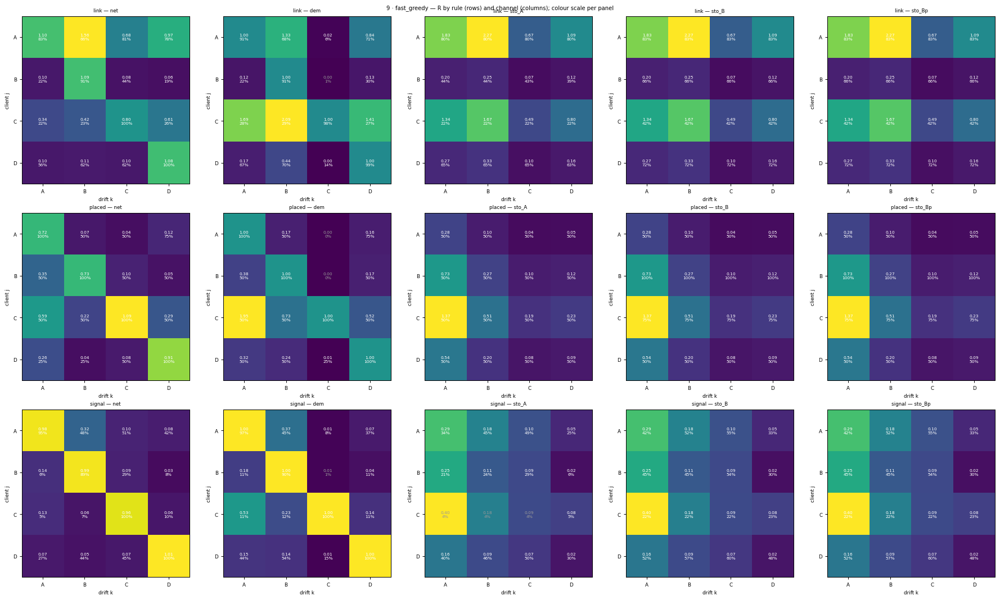

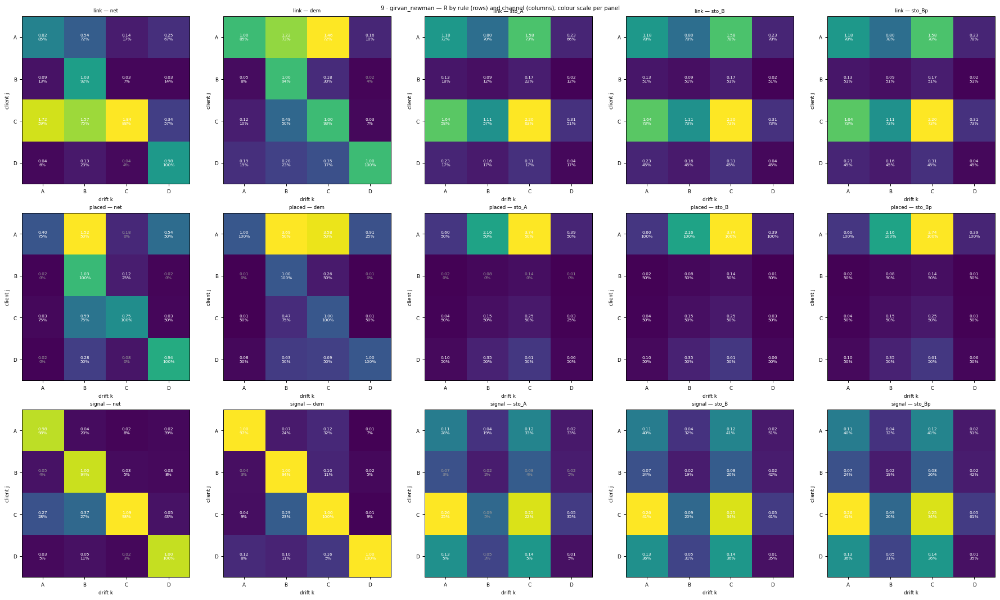

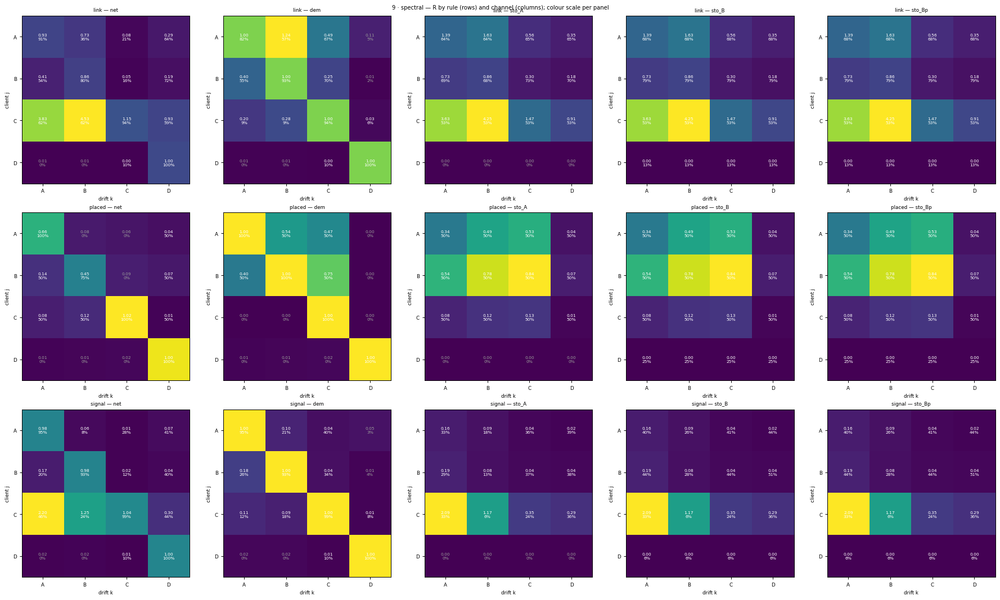

In [20]:
GR = DP["groups"]
basis = "anom" if "basis" in GR.columns else None
GRk = GR[(GR["kind"] == "link") & (GR["rho"] == 0.98) & ((GR["basis"] == basis) if basis else True)]
GRk = GRk.rename(columns={"signal": "id", "group": "sgroup"})[["world", "id", "sgroup"]]
EV = EV.drop(columns=[c for c in ("sgroup",) if c in EV.columns]).merge(GRk, on=["world", "id"], how="left")
sigB = (OBSU[["districting", "id", "unit", "sig_obs"]]
        .merge(DRIVE[["districting", "world", "unit", "driven"]], on=["districting", "unit"])
        .assign(s=lambda d: d["sig_obs"] & d["driven"].astype(bool))
        .groupby(["world", "id"])["s"].any().rename("sig_sto_B").reset_index())
EV = EV.drop(columns=[c for c in ("sig_sto_B",) if c in EV.columns]).merge(sigB, on=["world", "id"], how="left")
EV["sig_sto_B"] = EV["sig_sto_B"].fillna(False).astype(bool)
CHANNELS = {"net": ("g_tot", "sig_tot", True), "dem": ("g_dem", "sig_dem", True),
            "sto_A": ("sto_A", "sig_sto", False), "sto_B": ("sto_B", "sig_sto_B", False),
            "sto_Bp": ("sto_Bp", "sig_sto_B", False)}


def agg(e, col, scol, rule):
    e = e.assign(v=e[col].abs(), f=e[scol].astype(float))
    if rule == "placed":
        e = e[e["placed"].notna()]
    if rule == "signal":
        e = e.dropna(subset=["sgroup"]).groupby(["home", "drift", "sgroup"])[["v", "f"]].mean().reset_index()
    D_ = e.groupby(["home", "drift"]).agg(D=("v", "mean"), frac=("f", "mean"), n=("v", "size")).reset_index()
    return D_


MATA = []
for m in PARTS:
    e0 = EV[EV["districting"] == m]
    for rule in ("link", "placed", "signal"):
        ref = agg(e0, "g_dem", "sig_dem", rule)
        diag = ref[ref["home"] == ref["drift"]].set_index("drift")["D"]
        for ch, (col, scol, _) in CHANNELS.items():
            D_ = agg(e0, col, scol, rule)
            D_["R"] = D_["D"] / D_["drift"].map(diag)
            MATA.append(D_.assign(districting=m, rule=rule, channel=ch).rename(columns={"home": "j", "drift": "k"}))
MATA = pd.concat(MATA, ignore_index=True)
MATA.to_parquet(OUT / "matrices_attribution.parquet", index=False)
OBSU.to_parquet(OUT / "sensor_unit_observation.parquet", index=False)
DRIVE.to_parquet(OUT / "unit_drive.parquet", index=False)

off = MATA[MATA["j"] != MATA["k"]]
display(Markdown("**Off-diagonal $R$, mean over pairs** (channel × rule)"))
display(off.groupby(["districting", "channel", "rule"])["R"].mean().unstack("rule").round(3))
display(Markdown("**Do the rules rank the pairs alike?** Spearman of off-diagonal $D$ between rules, per channel"))
rk = []
for (m, ch), g in off.groupby(["districting", "channel"]):
    P_ = g.pivot_table(index=["j", "k"], columns="rule", values="D")
    rk.append({"districting": m, "channel": ch, **{f"{a} vs {b}": P_[a].corr(P_[b], method="spearman")
                                                   for a, b in (("link", "placed"), ("link", "signal"), ("placed", "signal"))}})
display(pd.DataFrame(rk).round(3))
for m in PARTS:
    names = NAMES[m]
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    for r_, rule in enumerate(("link", "placed", "signal")):
        for c_, ch in enumerate(CHANNELS):
            t = MATA[(MATA["districting"] == m) & (MATA["rule"] == rule) & (MATA["channel"] == ch)]
            Rm = t.pivot(index="j", columns="k", values="R").reindex(index=names, columns=names)
            Fm = t.pivot(index="j", columns="k", values="frac").reindex(index=names, columns=names)
            heat(axes[r_, c_], Rm, f"{rule} — {ch}", note=Fm.map(lambda v: f"{v:.0%}" if np.isfinite(v) else ""),
                 grey=Fm < FPR)
    fig.suptitle(f"9 · {m} — R by rule (rows) and channel (columns); colour scale per panel", fontsize=8)
    fig.tight_layout(); plt.show()

 10 · Identifiability flags

A label is only usable if the data could, in principle, reveal it. Flags are attached, never used to delete.

**Per client pair $(j,k)$, $j\ne k$**

| flag | rule | meaning |
|---|---|---|
| `same_signature` | init weekly profiles of $D_j$ and $D_k$ correlate $\ge 0.99$ (data-driven, not read from the map) | the two clients' normal-operation demand is alike **in shape**. A hypothesis about similarity, tested below per representation — not assumed |
| `not_detected_dem` / `not_detected_sto` | no counted unit of $j$ significant for $k$ in that channel (population: `link` rule; placed: `placed` rule) | "not detectable", not "zero" |
| `shared_hub` | every hub unit through which $j$ sees $k$ is driven by **every** district | storage evidence cannot say which district moved the hub |
| `unidentified_channel` | ≥ half of $j$'s links that respond to $k$ follow a unit without switching pumps ($r^2>0.5$) | the storage path is not identified; it sits in the demand channel |
| `shape_invisible` | a placed sensor of $j$ responds to $k$ natively, none in shape | the response is a level change the FL scaler removes |
| `placed_copies` | $j$'s placed sensors fall in fewer distinct signal groups than sensors | less independent evidence than sensors |

A unit is "driven by $k$" when its drive clears its split-half null (v3 files) or, without the null, when
$\lvert\gamma_{u,k}\rvert\ge 0.1\max_{k'}\lvert\gamma_{u,k'}\rvert$ — **provisional** rule, stated in the output.

**Per sensor**: `dead`, `pumpless`, `poor_fit` (§6b), `pump` (placed pump link, not labelled), `copy` (shares a
signal group with another placed sensor of its client in at least half the worlds), `level_only` (responds natively
to some drift but never in shape).

In [21]:
gate_banner()
# same signature: init district profiles
dpro = PR[(PR["kind"] == "district") & (PR["window"] == "init")].drop_duplicates(["districting", "signal"])
SAME = {}
for m in PARTS:
    P_ = dpro[dpro["districting"] == m].set_index("signal")[HC].reindex(NAMES[m])
    Cc = np.corrcoef(P_.to_numpy(float))
    for a, ja in enumerate(NAMES[m]):
        for b, kb in enumerate(NAMES[m]):
            SAME[(m, ja, kb)] = float(Cc[a, b])
blind = DRIVE.groupby(["districting", "unit"])["driven"].all()
seen = OBSU[OBSU["sig_obs"]].merge(LB[["districting", "id", "home"]], on=["districting", "id"])
PF = []
for m in PARTS:
    names = NAMES[m]
    e0 = EV[EV["districting"] == m]
    mt = MATA[MATA["districting"] == m].set_index(["rule", "channel", "j", "k"])["frac"]
    O_ = OBS[(OBS["districting"] == m) & (OBS["level"] == "population")].set_index(["basis", "j", "k"])["O"]
    for j in names:
        for k in names:
            if j == k:
                continue
            units_j = set(seen[(seen["districting"] == m) & (seen["home"] == j)]["unit"])
            drv = DRIVE[(DRIVE["districting"] == m) & (DRIVE["drift"] == k) & DRIVE["driven"]]
            via = units_j & set(drv["unit"])
            ek = e0[(e0["drift"] == k) & (e0["home"] == j)]
            resp = ek[ek["sig_tot"]]
            pk = ek[ek["placed"].notna()]
            grp = pk["sgroup"].nunique()
            PF.append({"districting": m, "j": j, "k": k, "same_signature": SAME[(m, j, k)] >= 0.99,
                       "signature_corr": SAME[(m, j, k)],
                       "O_raw": O_.get(("raw", j, k), np.nan), "O_anom": O_.get(("anom", j, k), np.nan),
                       "not_detected_dem_pop": mt.get(("link", "dem", j, k), 0) == 0,
                       "not_detected_sto_pop": mt.get(("link", "sto_B", j, k), 0) == 0,
                       "not_detected_dem_placed": mt.get(("placed", "dem", j, k), 0) == 0,
                       "not_detected_sto_placed": mt.get(("placed", "sto_B", j, k), 0) == 0,
                       "units_via": ",".join(sorted(via)),
                       "shared_hub": bool(via) and all(blind.get((m, u), False) for u in via),
                       "unidentified_channel": bool(len(resp)) and float((resp["r2_pumpless"].fillna(0) > 0.5).mean()) >= 0.5,
                       "shape_invisible": bool(pk["sig_tot"].any()) and not bool(pk["sig_shape"].any()),
                       "placed_sensors": len(pk), "placed_groups": int(grp),
                       "placed_copies": grp < len(pk)})
PF = pd.DataFrame(PF)
PF.to_parquet(OUT / "pair_flags.parquet", index=False)
display(Markdown(f"Unit drive rule: {drive_rule}."))
display(Markdown("**Is `same_signature` a similarity in the data?** Mean population $O$ by flag and basis — "
                 "raw series keep the weekly cycle, anomalies remove it"))
display(PF.groupby(["districting", "same_signature"])[["O_raw", "O_anom"]].mean().round(3))
flag_cols = ["same_signature", "not_detected_dem_pop", "not_detected_sto_pop", "not_detected_dem_placed",
             "not_detected_sto_placed", "shared_hub", "unidentified_channel", "shape_invisible", "placed_copies"]
display(Markdown("**Share of client pairs carrying each flag**"))
display(PF.groupby("districting")[flag_cols].mean().round(3))
for m in PARTS:
    t = PF[PF["districting"] == m].copy()
    t["flags"] = t.apply(lambda r: ",".join(c for c in flag_cols if r[c]) or "—", axis=1)
    display(Markdown(f"*{m}* — flags per pair (row j observes, column k drifts)"))
    display(t.pivot(index="j", columns="k", values="flags").reindex(index=NAMES[m], columns=NAMES[m]).fillna(""))

# per-sensor flags
cp = (EV[EV["placed"].notna()].groupby(["districting", "drift", "home", "sgroup"])["id"].transform("size") > 1)
EVp = EV[EV["placed"].notna()].assign(copy_world=cp)
copy_s = EVp.groupby(["districting", "id"])["copy_world"].mean().ge(0.5)
lvl = EV.groupby(["districting", "id"]).apply(lambda g: bool((g["sig_tot"] & ~g["sig_shape"]).any()) and not bool(g["sig_shape"].any()))
SF = FLAGS.copy()
SF["copy"] = [bool(copy_s.get(ix, False)) for ix in SF.index]
SF["level_only"] = [bool(lvl.get(ix, False)) for ix in SF.index]
SF = SF.reset_index()
SF = SF.merge(PL_ALL.drop_duplicates(["districting", "id"])[["districting", "id", "district", "slot_class"] +
              ([c for c in ("filled_as", "is_pump") if c in PL_ALL.columns])], on=["districting", "id"], how="outer")
if "is_pump" in SF.columns:
    SF["pump"] = SF["is_pump"].fillna(False).astype(bool)
SF.to_parquet(OUT / "sensor_flags.parquet", index=False)
pl_ = SF.dropna(subset=["slot_class"]).copy()
for c_ in ("flag_dead", "flag_pumpless", "flag_poor_fit", "copy", "level_only", "pump"):
    if c_ in pl_.columns:
        pl_[c_] = pl_[c_].fillna(False).astype(bool)
fcols = [c for c in ("flag_dead", "flag_pumpless", "flag_poor_fit", "copy", "level_only", "pump") if c in pl_.columns]
display(Markdown("**Placed sensors flagged** (count per partition × slot class)"))
display(pl_.groupby(["districting", "slot_class"])[fcols].sum())

Unit drive rule: split-half null with the links' calibrated c.

**Is `same_signature` a similarity in the data?** Mean population $O$ by flag and basis — raw series keep the weekly cycle, anomalies remove it

O_raw  O_anom
districting   same_signature               
fast_greedy   False           0.367   0.117
              True            0.590   0.108
girvan_newman False           0.335   0.059
              True            0.499   0.034
spectral      False           0.293   0.028
              True            0.632   0.080

**Share of client pairs carrying each flag**

,same_signature,not_detected_dem_pop,not_detected_sto_pop,not_detected_dem_placed,not_detected_sto_placed,shared_hub,unidentified_channel,shape_invisible,placed_copies
districting,,,,,,,,,
fast_greedy,0.167,0.000,0.0,0.167,0.0,1.0,0.0,0.0,0.667
girvan_newman,0.167,0.000,0.0,0.167,0.0,1.0,0.0,0.0,0.583
spectral,0.167,0.167,0.0,0.667,0.0,1.0,0.0,0.0,0.833


*fast_greedy* — flags per pair (row j observes, column k drifts)

k,District_A,District_B,District_C,District_D
j,,,,
District_A,,"same_signature,shared_hub","not_detected_dem_placed,shared_hub",shared_hub
District_B,"same_signature,shared_hub,placed_copies",,"not_detected_dem_placed,shared_hub,placed_copies","shared_hub,placed_copies"
District_C,"shared_hub,placed_copies","shared_hub,placed_copies",,"shared_hub,placed_copies"
District_D,"shared_hub,placed_copies","shared_hub,placed_copies",shared_hub,


*girvan_newman* — flags per pair (row j observes, column k drifts)

k,District_A,District_B,District_C,District_D
j,,,,
District_A,,"same_signature,shared_hub,placed_copies","shared_hub,placed_copies","shared_hub,placed_copies"
District_B,"same_signature,not_detected_dem_placed,shared_hub",,shared_hub,"not_detected_dem_placed,shared_hub"
District_C,shared_hub,"shared_hub,placed_copies",,shared_hub
District_D,"shared_hub,placed_copies","shared_hub,placed_copies","shared_hub,placed_copies",


*spectral* — flags per pair (row j observes, column k drifts)

k,District_A,District_B,District_C,District_D
j,,,,
District_A,,"same_signature,shared_hub,placed_copies","shared_hub,placed_copies","not_detected_dem_placed,shared_hub,placed_copies"
District_B,"same_signature,shared_hub,placed_copies",,"shared_hub,placed_copies","not_detected_dem_placed,shared_hub,placed_copies"
District_C,"not_detected_dem_placed,shared_hub","not_detected_dem_placed,shared_hub,placed_copies",,"not_detected_dem_placed,shared_hub"
District_D,"not_detected_dem_pop,not_detected_dem_placed,s...","not_detected_dem_pop,not_detected_dem_placed,s...","not_detected_dem_placed,shared_hub,placed_copies",


**Placed sensors flagged** (count per partition × slot class)

flag_dead  flag_pumpless  flag_poor_fit  copy  level_only  pump
districting   slot_class                                                                 
fast_greedy   mixed               0              0              0     6           0     0
              pure                0              0              0     0           0     0
girvan_newman mixed               0              0              1     4           0     0
              pure                0              0              0     0           0     0
spectral      mixed               0              0              0     8           0     0
              pure                0              0              0     1           0     0

 11 · Shape-space channel split — an experiment over the options

FL consumes per-client scaled series, so the label that matters downstream is in **shape** space, where §4 has no
channel split. Options:

| option | definition | validity question |
|---|---|---|
| (a) total only | $g^{\text{shape}}_s=\langle\Delta z_s,\Delta z_{D_k}\rangle/\lVert\Delta z_{D_k}\rVert^2$, $\Delta z=z(S_{\text{settled}})-z(S_{\text{init}})$ | none — but no channels |
| (b) linearised split | $\Delta z\approx\mathcal L(\Delta S)$, $\mathcal L(x)=\big(x-\bar x-z_0\langle z_0,x\rangle/T\big)/\sigma_0$ ($z_0,\sigma_0$: init profile); channels $\mathcal L(\Delta S^{\text{dem}})+\mathcal L(\Delta S^{\text{sto}})$, $\Delta S^{\text{sto}}=\sum_p b_{s,p}\Delta U_p$ | first-order: how large is $\lvert g^{\text{lin}}-g^{\text{shape}}\rvert$ at these drift sizes? |
| (c) mediator-blocked simulation | hub held on its pre-drift trajectory | **not run** — needs simulator changes |
| (d) observational variance shares | init week: $s_{\text{ch}}=\operatorname{cov}(\hat q_{\text{ch}},q)/\operatorname{var}(q)$ from the channel model's parts | describes normal operation, not the drift response |

$\mathcal L$ is linear, so (b) is exactly additive; its only error is the linearisation, measured here on every link
and on the composites (where the components are known). Agreement between (b), (d) and the native split shows
whether the choice changes the labels.

**(a) consistency** — shape gain recomputed from the exported profiles vs v2 `g`: corr 1.0000, sign disagreements 0.5% of link-worlds (v2's projection orients each window by its own mean flow, so links that reverse disagree in sign; the recomputation uses one orientation for both windows).

**(b) linearisation error** $\lvert g^{\text{lin}}-g^{\text{shape}}\rvert/\max_k\lvert g^{\text{shape}}\rvert$ per link (quantiles)

0.50   0.90   0.99
districting   topo          own                       
fast_greedy   branch        False  0.000  0.002  0.004
                            True   0.775  0.797  1.602
              loop          False  0.088  0.330  0.640
                            True   0.291  0.644  0.823
              source_bridge False  0.062  0.564  0.836
                            True   0.133  0.777  0.928
girvan_newman branch        False  0.001  0.002  0.004
                            True   0.610  0.794  1.533
              loop          False  0.027  0.293  1.466
                            True   0.282  0.793  1.240
              source_bridge False  0.049  0.525  0.832
                            True   0.253  0.767  0.920
spectral      branch        False  0.001  0.002  0.004
                            True   0.599  0.781  1.069
              loop          False  0.039  0.217  0.652
                            True   0.391  0.666  0.793
              source_bridge False  0.229  0.557  0.871
                            True   0.523  0.807  0.919

**(b) on composites** — linearisation error by composite kind (quantiles)

0.50   0.90   0.99
districting   kind                       
fast_greedy   pair    0.000  0.517  0.783
              single  0.000  0.578  0.762
              sto     0.090  0.313  0.630
girvan_newman pair    0.000  0.501  0.781
              single  0.000  0.575  0.758
              sto     0.101  0.514  0.648
spectral      pair    0.000  0.522  0.781
              single  0.000  0.585  0.761
              sto     0.062  0.445  0.603

**(b) estimated vs true shape-space storage term on storage composites** (error / composite's largest |shape gain|)

,0.50,0.90,0.99
districting,,,
fast_greedy,0.004,0.009,0.011
girvan_newman,0.003,0.018,0.028
spectral,0.004,0.012,0.024


**Do the options name the same dominant channel?** (link-worlds with both native channels significant; share agreeing)

,native vs shape-linear,native vs observational,shape-linear vs observational
districting,,,
fast_greedy,0.725,0.379,0.573
girvan_newman,0.607,0.506,0.452
spectral,0.694,0.687,0.602


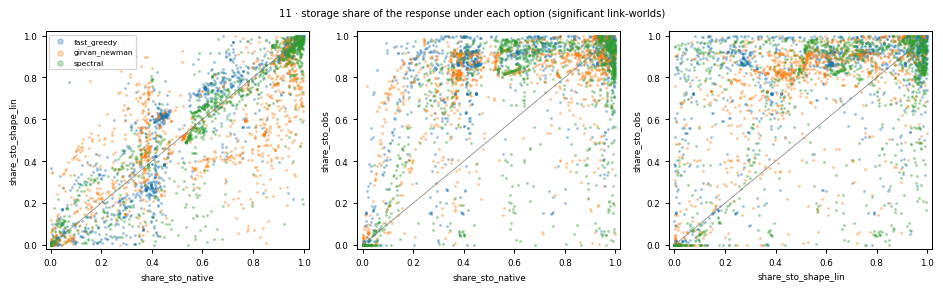

In [22]:
gate_banner()
EPS_ = 1e-12


def zr(A):
    s = A.std(axis=1, keepdims=True)
    return (A - A.mean(axis=1, keepdims=True)) / np.where(s > EPS_, s, np.nan)


def lin(x, z0, s0):
    T_ = x.shape[1]
    return (x - x.mean(axis=1, keepdims=True) - z0 * (np.nansum(z0 * x, axis=1, keepdims=True) / T_)) / s0


SS = []
for wr in WORLDS.itertuples():
    pw = PR[PR["world"] == wr.world]
    get = lambda kind, win: pw[(pw["kind"] == kind) & (pw["window"] == win)].set_index("signal")[HC]
    I, F = get("link", "init"), get("link", "settled")
    ids = I.index
    F = F.loc[ids]
    pI, pF = I.to_numpy(float), F.to_numpy(float)
    dI = get("district", "init").loc[[wr.drift]].to_numpy(float)
    dF = get("district", "settled").loc[[wr.drift]].to_numpy(float)
    dz = zr(dF) - zr(dI)
    nz = float((dz ** 2).sum())
    g_sh = ((zr(pF) - zr(pI)) @ dz.T)[:, 0] / nz
    z0, s0 = zr(pI), pI.std(axis=1, keepdims=True)
    s0 = np.where(s0 > EPS_, s0, np.nan)
    dS = pF - pI
    b = SBp[SBp["districting"] == wr.districting].pivot(index="id", columns="pump", values="b").reindex(ids).fillna(0.0)
    pumps = list(b.columns)
    if pumps:
        Hi, Hf = get("hub", "init"), get("hub", "settled")
        dU = Hf.loc[[f"pump:{p}" for p in pumps]].to_numpy(float) - Hi.loc[[f"pump:{p}" for p in pumps]].to_numpy(float)
        dS_sto = b.to_numpy(float) @ dU
    else:
        dS_sto = np.zeros_like(dS)
    proj_ = lambda X: (X @ dz.T)[:, 0] / nz
    g_lin = proj_(lin(dS, z0, s0))
    g_lin_sto = proj_(lin(dS_sto, z0, s0))
    g_lin_dem = proj_(lin(dS - dS_sto, z0, s0))
    S_ = SER[wr.world]
    ix = [S_["ids"].index(i) if i in S_["ids"] else None for i in ids]
    T0 = len(TC)
    q0 = np.array([S_["q"][i, :T0] if i is not None else np.full(T0, np.nan) for i in ix])
    st0 = np.array([S_["sto"][i, :T0] if i is not None else np.full(T0, np.nan) for i in ix])
    de0 = np.array([S_["dem"][i, :T0] if i is not None else np.full(T0, np.nan) for i in ix])
    vq = q0.var(axis=1)
    cov = lambda A: ((A - A.mean(axis=1, keepdims=True)) * (q0 - q0.mean(axis=1, keepdims=True))).mean(axis=1)
    SS.append(pd.DataFrame({"world": wr.world, "districting": wr.districting, "drift": wr.drift, "id": ids,
                            "g_shape_exact": g_sh, "g_shape_lin": g_lin, "g_shape_lin_sto": g_lin_sto,
                            "g_shape_lin_dem": g_lin_dem,
                            "obs_share_sto": np.where(vq > EPS_, cov(st0) / np.where(vq > EPS_, vq, 1), np.nan),
                            "obs_share_dem": np.where(vq > EPS_, cov(de0) / np.where(vq > EPS_, vq, 1), np.nan)}))
SS = pd.concat(SS, ignore_index=True).merge(
    EV[["world", "id", "orient", "topo", "storage", "own", "placed", "g_shape", "g_dem", "g_sto",
        "sig_dem", "sig_sto", "sig_tot", "sig_shape"]],
    on=["world", "id"], how="inner")
for c in ("g_shape_exact", "g_shape_lin", "g_shape_lin_sto", "g_shape_lin_dem"):
    SS[c] = SS[c] * SS["orient"]
scale = SS.groupby(["districting", "id"])["g_shape_exact"].transform(lambda x: x.abs().max())
SS["e_lin"] = (SS["g_shape_lin"] - SS["g_shape_exact"]).abs() / scale
SS["share_sto_native"] = SS["g_sto"].abs() / (SS["g_sto"].abs() + SS["g_dem"].abs())
SS["share_sto_shape_lin"] = SS["g_shape_lin_sto"].abs() / (SS["g_shape_lin_sto"].abs() + SS["g_shape_lin_dem"].abs())
SS["share_sto_obs"] = SS["obs_share_sto"].abs() / (SS["obs_share_sto"].abs() + SS["obs_share_dem"].abs())
SS.to_parquet(OUT / "shape_split.parquet", index=False)

v2c = SS[["g_shape_exact", "g_shape"]].corr().iat[0, 1]
signs = float((np.sign(SS["g_shape_exact"]) != np.sign(SS["g_shape"])).mean())
display(Markdown(f"**(a) consistency** — shape gain recomputed from the exported profiles vs v2 `g`: corr {v2c:.4f}, "
                 f"sign disagreements {signs:.1%} of link-worlds (v2's projection orients each window by its own mean "
                 "flow, so links that reverse disagree in sign; the recomputation uses one orientation for both windows)."))
display(Markdown("**(b) linearisation error** $\\lvert g^{\\text{lin}}-g^{\\text{shape}}\\rvert/\\max_k\\lvert g^{\\text{shape}}\\rvert$ "
                 "per link (quantiles)"))
display(SS.groupby(["districting", "topo", "own"])["e_lin"].quantile([0.5, 0.9, 0.99]).unstack().round(3))

# composites: linearisation error and the split on known components
CPp = PR[PR["kind"] == "composite"]
if len(CPp):
    rows = []
    for wr in WORLDS.itertuples():
        pw = CPp[CPp["world"] == wr.world]
        I = pw[pw["window"] == "init"].set_index("signal")[HC]
        F = pw[pw["window"] == "settled"].set_index("signal")[HC].loc[I.index]
        dd = PR[(PR["world"] == wr.world) & (PR["kind"] == "district") & (PR["signal"] == wr.drift)]
        dz = zr(dd[dd["window"] == "settled"][HC].to_numpy(float)) - zr(dd[dd["window"] == "init"][HC].to_numpy(float))
        nz = float((dz ** 2).sum())
        pI, pF = I.to_numpy(float), F.to_numpy(float)
        z0, s0 = zr(pI), pI.std(axis=1, keepdims=True)
        g_ex = ((zr(pF) - zr(pI)) @ dz.T)[:, 0] / nz
        g_li = (lin(pF - pI, z0, s0) @ dz.T)[:, 0] / nz
        for n_, cid in enumerate(I.index):
            rec_ = {"world": wr.world, "districting": wr.districting, "drift": wr.drift, "comp_id": cid,
                    "g_shape_exact": g_ex[n_], "g_shape_lin": g_li[n_]}
            if cid.startswith("sto:"):
                base = "single:" + cid.split(":")[1]
                if base in I.index:
                    dS_dem = (F.loc[base] - I.loc[base]).to_numpy(float)[None, :]
                    dS_sto = (pF[n_] - pI[n_])[None, :] - dS_dem
                    rec_["g_lin_dem_true"] = float((lin(dS_dem, z0[[n_]], s0[[n_]]) @ dz.T)[0, 0] / nz)
                    rec_["g_lin_sto_true"] = float((lin(dS_sto, z0[[n_]], s0[[n_]]) @ dz.T)[0, 0] / nz)
            rows.append(rec_)
    CSH = pd.DataFrame(rows)
    sc = CSH.groupby(["districting", "comp_id"])["g_shape_exact"].transform(lambda x: x.abs().max())
    CSH["e_lin"] = (CSH["g_shape_lin"] - CSH["g_shape_exact"]).abs() / sc
    CSH["kind"] = CSH["comp_id"].str.split(":").str[0]
    if "comp_switch" in DP:
        cw = DP["comp_switch"]
        bc = cw[cw["term_kind"] == "pump"].pivot_table(index=["world", "comp_id"], columns="term", values="coef")
        est = []
        for wr in WORLDS.itertuples():
            pw = PR[PR["world"] == wr.world]
            Hi = pw[(pw["kind"] == "hub") & (pw["window"] == "init")].set_index("signal")[HC]
            Hf = pw[(pw["kind"] == "hub") & (pw["window"] == "settled")].set_index("signal")[HC]
            if wr.world not in bc.index.get_level_values(0):
                continue
            bw = bc.loc[wr.world].dropna(axis=1, how="all")
            dU = Hf.loc[[f"pump:{p}" for p in bw.columns]].to_numpy(float) - Hi.loc[[f"pump:{p}" for p in bw.columns]].to_numpy(float)
            I = CPp[(CPp["world"] == wr.world) & (CPp["window"] == "init")].set_index("signal")[HC].loc[bw.index]
            dd = PR[(PR["world"] == wr.world) & (PR["kind"] == "district") & (PR["signal"] == wr.drift)]
            dz = zr(dd[dd["window"] == "settled"][HC].to_numpy(float)) - zr(dd[dd["window"] == "init"][HC].to_numpy(float))
            pI = I.to_numpy(float)
            z0, s0 = zr(pI), pI.std(axis=1, keepdims=True)
            g_sto_est = (lin(bw.fillna(0).to_numpy(float) @ dU, z0, s0) @ dz.T)[:, 0] / float((dz ** 2).sum())
            est.append(pd.DataFrame({"world": wr.world, "comp_id": bw.index, "g_lin_sto_est": g_sto_est}))
        CSH = CSH.merge(pd.concat(est), on=["world", "comp_id"], how="left") if est else CSH
    CSH.to_parquet(OUT / "composite_shape_split.parquet", index=False)
    display(Markdown("**(b) on composites** — linearisation error by composite kind (quantiles)"))
    display(CSH.groupby(["districting", "kind"])["e_lin"].quantile([0.5, 0.9, 0.99]).unstack().round(3))
    if "g_lin_sto_est" in CSH.columns:
        s_ = CSH.dropna(subset=["g_lin_sto_true", "g_lin_sto_est"])
        s_ = s_.assign(err=(s_["g_lin_sto_est"] - s_["g_lin_sto_true"]).abs()
                       / s_.groupby(["districting", "comp_id"])["g_shape_exact"].transform(lambda x: x.abs().max()))
        display(Markdown("**(b) estimated vs true shape-space storage term on storage composites** "
                         "(error / composite's largest |shape gain|)"))
        display(s_.groupby("districting")["err"].quantile([0.5, 0.9, 0.99]).unstack().round(3))
    else:
        display(Markdown("*Estimated-vs-true shape split on composites needs `comp_switch` (compute v3).*"))

# agreement between options, on links where both channels matter
both = SS[SS["sig_dem"] & SS["sig_sto"]]
dom_ch = lambda s: np.where(s >= 0.5, "storage", "demand")
agree = pd.DataFrame({"native vs shape-linear": (dom_ch(both["share_sto_native"]) == dom_ch(both["share_sto_shape_lin"])),
                      "native vs observational": (dom_ch(both["share_sto_native"]) == dom_ch(both["share_sto_obs"])),
                      "shape-linear vs observational": (dom_ch(both["share_sto_shape_lin"]) == dom_ch(both["share_sto_obs"]))})
agree["districting"] = both["districting"].to_numpy()
display(Markdown("**Do the options name the same dominant channel?** (link-worlds with both native channels "
                 "significant; share agreeing)"))
display(agree.groupby("districting").mean().round(3))
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))
for ax, (x, y) in zip(axes, (("share_sto_native", "share_sto_shape_lin"), ("share_sto_native", "share_sto_obs"),
                             ("share_sto_shape_lin", "share_sto_obs"))):
    for m in PARTS:
        z_ = SS[(SS["districting"] == m) & SS["sig_tot"]]
        ax.scatter(z_[x], z_[y], s=2, alpha=0.3, label=m)
    ax.plot([0, 1], [0, 1], color="0.5", lw=0.6)
    ax.set(xlabel=x, ylabel=y, xlim=(-0.02, 1.02), ylim=(-0.02, 1.02))
axes[0].legend(fontsize=6, markerscale=3)
fig.suptitle("11 · storage share of the response under each option (significant link-worlds)", fontsize=8)
fig.tight_layout(); plt.show()

 12 · Exports — the finest grain each section has

| file | one row per | content |
|---|---|---|
| `reconstruction_series` | world × link × series | hourly init week + settled week (336 values): reading `q`, channel model `chan` and its parts `sto`, `dem`, stack-mixture model `mix` |
| `calibration_rows` | world × branch link | negative / positive role, $z$ native and shape, threshold |
| `gate_G2_rows` | world × branch × district | switch-fit $a$ vs signed exact $a^{\text{ex}}$ |
| `observational_pairs` | partition × link pair × basis | $\lvert\operatorname{corr}\rvert$ (init window), both homes |
| `districting_table` | partition × district | size, assets, pumps, boundary links, transit / own demand, inbound and outbound $R$ per channel and rule |
| written earlier | | `sensor_evidence`, `reconstruction`, `sensor_demand_mixture`, `sensor_observational`, `sensor_flags`, `sensor_unit_observation`, `unit_drive`, `shape_split`, `composite_*`, `matrices_*`, `pair_flags` |

In [23]:
gate_banner()
rows = []
for w, S_ in SER.items():
    for key in ("q", "chan", "sto", "dem", "mix"):
        A = np.asarray(S_[key], np.float32)
        df = pd.DataFrame(A, columns=[f"h{t:03d}" for t in range(A.shape[1])])
        df.insert(0, "series", key)
        df.insert(0, "id", S_["ids"])
        df.insert(0, "world", w)
        rows.append(df)
pd.concat(rows, ignore_index=True).to_parquet(OUT / "reconstruction_series.parquet", index=False)

cr = EV[EV["topo"] == "branch"][["districting", "world", "drift", "id", "exact_home", "z_tot", "z_shape", "c_nat", "c_shape"]].copy()
cr["role"] = np.where(cr["exact_home"] == cr["drift"], "positive", "negative")
cr.to_parquet(OUT / "calibration_rows.parquet", index=False)
SA.to_parquet(OUT / "gate_G2_rows.parquet", index=False)
pd.concat(OPAIRS, ignore_index=True).to_parquet(OUT / "observational_pairs.parquet", index=False)

# districting table
ND, NODES_ = DP["node_district"], DP["nodes"]
tp_ = TP[TP["network"] == WORLDS["network"].iloc[0]]
mu = (PR[(PR["kind"] == "link") & (PR["window"] == "init")].drop_duplicates(["districting", "signal"])
      .assign(q=lambda d: d[HC].mean(axis=1)).set_index(["districting", "signal"])["q"])
dmu = (PR[(PR["kind"] == "district") & (PR["window"] == "init")].drop_duplicates(["districting", "signal"])
       .assign(q=lambda d: d[HC].mean(axis=1)).set_index(["districting", "signal"])["q"])
TANKS = set(NODES_[NODES_["kind"] == "tank"]["node"])
DT = []
for m in PARTS:
    n2d = ND[ND["districting"] == m].set_index("node")["district"]
    xy = NODES_.set_index("node")[["x", "y"]]
    for d in NAMES[m]:
        ns = n2d[n2d == d].index
        c_ = xy.loc[xy.index.intersection(ns)].mean()
        bl = tp_[[(n2d.get(a) != n2d.get(b)) and (n2d.get(a) == d or n2d.get(b) == d) and n2d.get(a) is not None
                  and n2d.get(b) is not None for a, b in zip(tp_["start"], tp_["end"])]]
        inside = tp_[[n2d.get(a) == d and n2d.get(b) == d for a, b in zip(tp_["start"], tp_["end"])]]
        transit = sum(abs(mu.get((m, "q_" + e), 0.0)) for e in bl["element"]) / max(abs(dmu.get((m, d), np.nan)), 1e-12)
        row = {"districting": m, "district": d, "n_nodes": len(ns), "x": c_["x"], "y": c_["y"],
               "pumps_inside": ",".join(inside[inside["link_type"].str.contains("Pump")]["element"]),
               "n_boundary": len(bl), "boundary_types": ",".join(sorted(set(bl["link_type"]))),
               "boundary_flow_over_demand": transit,
               "tanks_adjacent": ",".join(sorted(t for t in TANKS if any(
                   n2d.get(o) == d for o in pd.concat([tp_[tp_["start"] == t]["end"], tp_[tp_["end"] == t]["start"]])))),
               "signature": ",".join(k for k in NAMES[m] if k != d and SAME[(m, d, k)] >= 0.99) or "—"}
        mt = MATA[(MATA["districting"] == m)]
        for ch in CHANNELS:
            for rule in ("link", "placed"):
                t = mt[(mt["channel"] == ch) & (mt["rule"] == rule) & (mt["j"] != mt["k"])]
                row[f"R_in_{ch}_{rule}"] = t[t["j"] == d]["R"].mean()
                row[f"R_out_{ch}_{rule}"] = t[t["k"] == d]["R"].mean()
        DT.append(row)
DT = pd.DataFrame(DT)
DT.to_parquet(OUT / "districting_table.parquet", index=False)
display(Markdown("**Districting table** (inbound = mean $R$ of row $j$ off-diagonal; outbound = of column $k$)"))
display(DT[["districting", "district", "n_nodes", "pumps_inside", "n_boundary", "boundary_flow_over_demand", "signature",
            "R_in_net_link", "R_out_net_link", "R_in_sto_B_placed", "R_out_sto_B_placed", "R_in_dem_placed",
            "R_out_dem_placed"]].round(3))
display(Markdown("**Files in** `" + OUT.name + "/`"))
display(pd.DataFrame([{"file": f.name, "rows": len(pd.read_parquet(f)), "MB": round(f.stat().st_size / 1e6, 2)}
                      for f in sorted(OUT.glob("*.parquet"))]))

**Districting table** (inbound = mean $R$ of row $j$ off-diagonal; outbound = of column $k$)

,districting,district,n_nodes,pumps_inside,n_boundary,boundary_flow_over_demand,signature,R_in_net_link,R_out_net_link,R_in_sto_B_placed,R_out_sto_B_placed,R_in_dem_placed,R_out_dem_placed
0,fast_greedy,District_A,170,~@Pump-1,16,4.760,District_B,1.070,0.181,0.063,0.878,0.111,0.885
1,fast_greedy,District_B,158,,8,1.379,District_A,0.079,0.699,0.318,0.271,0.184,0.381
2,fast_greedy,District_C,87,,4,0.968,—,0.459,0.285,0.702,0.073,1.068,0.003
3,fast_greedy,District_D,66,,6,1.564,—,0.105,0.549,0.273,0.133,0.191,0.285
4,girvan_newman,District_A,237,,8,2.401,District_B,0.311,0.616,2.097,0.053,2.725,0.032
5,girvan_newman,District_B,105,,5,1.342,District_A,0.051,0.746,0.059,0.887,0.092,1.596
6,girvan_newman,District_C,99,~@Pump-1,9,4.511,—,1.210,0.073,0.071,1.496,0.161,1.511
7,girvan_newman,District_D,40,,2,1.000,—,0.071,0.209,0.353,0.143,0.469,0.308
8,spectral,District_A,215,,56,11.084,District_B,0.367,1.415,0.351,0.210,0.337,0.138
9,spectral,District_B,206,,54,9.216,District_A,0.215,1.754,0.484,0.202,0.387,0.186


**Files in** `dependence_analysis/`

,file,rows,MB
0,calibration_rows.parquet,1980,0.05
1,composite_shape_split.parquet,408,0.02
2,composite_split.parquet,144,0.04
3,composite_weights.parquet,66,0.01
4,districting_table.parquet,12,0.02
5,gate_G2_rows.parquet,7920,0.06
6,matrices_attribution.parquet,720,0.02
7,matrices_interventional.parquet,384,0.01
8,matrices_observational.parquet,480,0.01
9,observational_pairs.parquet,1089018,5.28


 13 · Diagnosis of the label stack's mixture (from its own gains)

The stack's labels decide the placement classes, so their errors propagate into what the FL clients hold.
`stack_gains` (compute v3) carries, per link and probe world, the stack's shape projection `proj`, its noise
draw `nu` and gain `g`. The stack's rule is rebuilt here **with the study's settings** and checked against the
stored labels before anything is changed:

| setting (study `sensor_placement.classes`) | value used |
|---|---|
| gate | `projection`: cell live if $\lvert\text{proj}\rvert>f\,\nu$, $f$ = `null_factor` |
| mixture rule | `magnitude`: mass $=\lvert g\rvert$ on live cells; $w$ = mass / total |
| tiers | core: purity $\ge$ `core_purity`; foreign: $\le$ `foreign_max`; mixed-eligible: second weight $\ge$ `mixed_min_foreign` and $\ge$ `min_n_mass` districts with mass |

Then three questions: **(a)** how often the gate admits a cell whose true response is zero (branch links of a
non-drifting district — the same negatives as §4a, here in the stack's own probe worlds); **(b)** what the tiers
become with a calibrated gate; **(c)** how many links — and how many **placed** sensors — are exposed to the
per-window sign alignment (a window's profile is oriented by that window's own mean flow, so a link whose mean
changes sign between windows is mirrored; a single orientation, as in this notebook, does not do that).

In [24]:
gate_banner()
STACK_F, STACK_RULE = 1.5, "magnitude"            # study: classes.null_factor, classes.mixture
CORE_P, FOREIGN_M, MIXED_MIN, MIN_N = 0.85, 0.15, 0.25, 2   # study: core_purity, foreign_max, mixed_min_foreign, min_n_mass
HAS_SG = "stack_gains" in DP
if not HAS_SG:
    display(Markdown("*`stack_gains` missing — rerun dependence_compute v3. §13–§14 and the out-of-sample part of §17 are skipped.*"))
else:
    SG = DP["stack_gains"]
    SG = SG[~SG["is_pump"].astype(bool)].copy() if "is_pump" in SG.columns else SG.copy()
    SG["z"] = SG["proj"].abs() / SG["nu"]
    DOMX = EV.dropna(subset=["exact_home"]).drop_duplicates(["districting", "id"]).set_index(["districting", "id"])["exact_home"]
    SG["exact_home"] = [DOMX.get((m, i)) for m, i in zip(SG["districting"], SG["id"])]

    def stack_w(s, f, rule):
        live = s["z"] > f
        mass = np.where(live, s["g"].abs() if rule == "magnitude" else s["g"].clip(lower=0), 0.0)
        t = s.assign(mass=mass).pivot_table(index="id", columns="drift_district", values="mass", aggfunc="first")
        tot = t.sum(axis=1)
        return t.div(tot.where(tot > 0), axis=0), (t > 0).sum(axis=1)

    def tiers(W, nm, home):
        pur = np.array([W.at[i, h] if (h in W.columns and i in W.index) else np.nan for i, h in zip(W.index, home.reindex(W.index))])
        sec = np.array([np.sort(np.nan_to_num(W.loc[i].drop(h).to_numpy()))[-1] if h in W.columns else np.nan
                        for i, h in zip(W.index, home.reindex(W.index))])
        tier = np.where(nm == 0, "unusable", np.where(pur >= CORE_P, "core", np.where(pur <= FOREIGN_M, "foreign", "transition")))
        return pd.DataFrame({"purity": pur, "second": sec, "tier": tier, "mixed_eligible": (sec >= MIXED_MIN) & (nm >= MIN_N),
                             "n_mass": nm}, index=W.index)

    C_STACK, rep, tv = {}, [], []
    for m in PARTS:
        s = SG[SG["districting"] == m]
        W0, nm0 = stack_w(s, STACK_F, STACK_RULE)
        L_ = LB[LB["districting"] == m].set_index("id")[[f"w_{d}" for d in W0.columns]].set_axis(W0.columns, axis=1)
        ci = W0.index.intersection(L_.index)
        neg = s[s["exact_home"].notna() & (s["exact_home"] != s["drift_district"])]
        pos = s[s["exact_home"].notna() & (s["exact_home"] == s["drift_district"])]
        c_ = float(neg["z"].quantile(1 - FPR))
        C_STACK[m] = c_
        rep.append({"districting": m, "reproduces stored w (max abs diff)": float((W0.loc[ci] - L_.loc[ci]).abs().max().max()),
                    "true-zero cells passing the stack gate": float((neg["z"] > STACK_F).mean()),
                    "calibrated factor (FPR on true zeros)": c_, "TPR at calibrated factor": float((pos["z"] > c_).mean()),
                    "shape excitation, max/min over districts": float(s.groupby("drift_district")["excite"].first().max()
                                                                       / s.groupby("drift_district")["excite"].first().min())})
        home = s.drop_duplicates("id").set_index("id")["district"]
        base = None
        plm = PL[(PL["districting"] == m)].drop_duplicates("id").set_index("id")["slot_class"]
        for name, f, rule in (("stack", STACK_F, STACK_RULE), ("calibrated, magnitude", c_, "magnitude"),
                              ("calibrated, positive", c_, "positive")):
            W_, nm_ = stack_w(s, f, rule)
            T_ = tiers(W_, nm_, home)
            base = T_ if base is None else base
            pm = T_.reindex(plm[plm == "mixed"].index)
            tv.append({"districting": m, "variant": name, **T_["tier"].value_counts(normalize=True).reindex(
                ["core", "transition", "foreign", "unusable"]).fillna(0).round(3).to_dict(),
                "mixed-eligible": T_["mixed_eligible"].mean(), "mean n_mass": T_["n_mass"].mean(),
                "placed mixed still mixed-eligible": f"{int(pm['mixed_eligible'].sum())}/{len(pm)}",
                "tier agrees with stack": float((T_["tier"] == base["tier"]).mean())})
    display(Markdown("**13a · reproduction and the gate on true-zero cells**"))
    display(pd.DataFrame(rep).round(4))
    display(Markdown("**13b · tiers with the calibrated gate**"))
    display(pd.DataFrame(tv).round(3))

    # 13c sign flips between windows (target worlds, raw orientation)
    lk_ = PR[PR["kind"] == "link"].assign(mu=lambda d: d[HC].mean(axis=1), sd=lambda d: d[HC].std(axis=1))
    fi = lk_[lk_["window"] == "init"].set_index(["world", "signal"])
    ff = lk_[lk_["window"] == "settled"].set_index(["world", "signal"])
    FL_ = fi[["districting", "mu", "sd"]].join(ff[["mu"]], rsuffix="_f")
    FL_["flip"] = np.sign(FL_["mu"]) != np.sign(FL_["mu_f"])
    FLIP = FL_.reset_index().groupby(["districting", "signal"]).agg(flip=("flip", "any"), mean_over_sd=("mu", "first"),
                                                                     sd=("sd", "first"))
    FLIP["mean_over_sd"] = FLIP["mean_over_sd"] / FLIP["sd"]
    fx = []
    for m in PARTS:
        fl_ = FLIP.loc[m]
        plm = PL[(PL["districting"] == m)].drop_duplicates("id").set_index("id")["slot_class"]
        fx.append({"districting": m, "links flipping in ≥1 world": float(fl_["flip"].mean()),
                   "links with |mean| < 0.1·sd": float((fl_["mean_over_sd"].abs() < 0.1).mean()),
                   "placed mixed flipping": f"{int(fl_['flip'].reindex(plm[plm == 'mixed'].index).fillna(False).sum())}/{int((plm == 'mixed').sum())}",
                   "placed pure flipping": f"{int(fl_['flip'].reindex(plm[plm == 'pure'].index).fillna(False).sum())}/{int((plm == 'pure').sum())}"})
    display(Markdown("**13c · exposure to the per-window sign alignment** (sign of the weekly mean differs between "
                     "init and settled in at least one target world)"))
    display(pd.DataFrame(fx))
    FLIP.reset_index().to_parquet(OUT / "sign_flips.parquet", index=False)

**13a · reproduction and the gate on true-zero cells**

,districting,reproduces stored w (max abs diff),true-zero cells passing the stack gate,calibrated factor (FPR on true zeros),TPR at calibrated factor,"shape excitation, max/min over districts"
0,fast_greedy,0.0,0.3253,8.7924,1.0,1.1475
1,girvan_newman,0.0,0.3232,10.0009,1.0,1.1303
2,spectral,0.0,0.2970,8.4528,1.0,1.1373


**13b · tiers with the calibrated gate**

,districting,variant,core,transition,foreign,unusable,mixed-eligible,mean n_mass,placed mixed still mixed-eligible,tier agrees with stack
0,fast_greedy,stack,0.380,0.469,0.151,0.000,0.496,3.299,8/8,1.000
1,fast_greedy,"calibrated, magnitude",0.386,0.449,0.146,0.018,0.491,2.708,8/8,0.972
2,fast_greedy,"calibrated, positive",0.418,0.393,0.171,0.018,0.449,2.030,5/8,0.869
3,girvan_newman,stack,0.420,0.479,0.101,0.000,0.486,3.017,8/8,1.000
4,girvan_newman,"calibrated, magnitude",0.433,0.441,0.109,0.017,0.423,1.876,8/8,0.955
5,girvan_newman,"calibrated, positive",0.572,0.131,0.043,0.254,0.106,1.058,3/8,0.562
6,spectral,stack,0.400,0.509,0.091,0.000,0.431,3.028,6/8,1.000
7,spectral,"calibrated, magnitude",0.413,0.478,0.093,0.017,0.416,2.289,6/8,0.957
8,spectral,"calibrated, positive",0.451,0.391,0.138,0.020,0.413,1.995,6/8,0.871


**13c · exposure to the per-window sign alignment** (sign of the weekly mean differs between init and settled in at least one target world)

,districting,links flipping in ≥1 world,links with |mean| < 0.1·sd,placed mixed flipping,placed pure flipping
0,fast_greedy,0.059701,0.031509,5/8,0/8
1,girvan_newman,0.056385,0.029851,4/8,0/8
2,spectral,0.056385,0.031509,3/8,0/8


 14 · Replication — probe stack (its seed) vs target worlds (theirs)

The probe worlds and the target worlds are independent simulations of the same partition and the same
transitions (they differ in seed and in the drift design: the probe uses planned diffusion and its own warm-up /
settle lengths). A label that is a property of the sensor should replicate. Per cell (link × drifting $k$),
"significant" means calibrated on true-zero branch cells **in each set separately**: probe $\lvert\text{proj}\rvert/\nu>c_{\text{stack}}$
(§13a), target $z^{\text{shape}}>c_{\text{shape}}$ (§4a). Disagreements are split into near-threshold (both
within half a decade of their threshold) and strong (one side more than 10× its threshold).

In [25]:
if HAS_SG:
    rows, ex = [], []
    for m in PARTS:
        s = SG[SG["districting"] == m].assign(sig_probe=lambda d: d["z"] > C_STACK[m])
        e = EV[EV["districting"] == m][["id", "drift", "sig_shape", "z_shape", "c_shape", "g_shape", "storage", "home"]] \
            .rename(columns={"drift": "drift_district"})
        j = s.merge(e, on=["id", "drift_district"])
        a_, b_ = np.log10(j["z"] / C_STACK[m]), np.log10(j["z_shape"] / j["c_shape"])
        dis = j["sig_probe"] != j["sig_shape"]
        both = j[j["sig_probe"] & j["sig_shape"]]
        rows.append({"districting": m, "cells": len(j), "agree": float((~dis).mean()),
                     "P(target sig | probe sig)": float(j[j["sig_probe"]]["sig_shape"].mean()),
                     "P(probe sig | target sig)": float(j[j["sig_shape"]]["sig_probe"].mean()),
                     "agree, off-diagonal only": float((~dis[j["home"] != j["drift_district"]]).mean()),
                     "sign agrees where both sig": float((np.sign(both["g"]) == np.sign(both["g_shape"])).mean()),
                     "disagreements near threshold": float(((a_.abs() < 0.5) & (b_.abs() < 0.5))[dis].mean()),
                     "disagreements strong in one set": float(((a_ > 1) | (b_ > 1))[dis].mean()),
                     "storage-class share: disagreeing / all": f"{j['storage'][dis].mean():.2f} / {j['storage'].mean():.2f}",
                     "spearman log z": float(pd.Series(a_).corr(pd.Series(b_), method="spearman"))})
        plm = PL[(PL["districting"] == m)].drop_duplicates("id")
        for r_ in plm.itertuples():
            t = j[j["id"] == r_.id].sort_values("drift_district")
            ex.append({"districting": m, "slot": r_.slot_class, "id": r_.id,
                       "probe: districts": "".join(d[-1] for d in t[t["sig_probe"]]["drift_district"]),
                       "target: districts": "".join(d[-1] for d in t[t["sig_shape"]]["drift_district"])})
    REPL = pd.DataFrame(rows)
    display(REPL.round(3))
    EXR = pd.DataFrame(ex)
    EXR["same set"] = EXR["probe: districts"] == EXR["target: districts"]
    display(Markdown("**Placed sensors: does the set of responding districts replicate?** (share with the identical set)"))
    display(EXR.groupby(["districting", "slot"])["same set"].mean().unstack().round(2))
    display(Markdown("placed sensors whose set differs"))
    display(EXR[~EXR["same set"]].reset_index(drop=True))
    EXR.to_parquet(OUT / "replication_placed.parquet", index=False)
    REPL.to_parquet(OUT / "replication_cells.parquet", index=False)

,districting,cells,agree,P(target sig | probe sig),P(probe sig | target sig),"agree, off-diagonal only",sign agrees where both sig,disagreements near threshold,disagreements strong in one set,storage-class share: disagreeing / all,spearman log z
0,fast_greedy,2412,0.915,0.908,0.965,0.901,0.990,0.662,0.044,0.61 / 0.55,0.870
1,girvan_newman,2412,0.883,0.904,0.856,0.860,0.967,0.391,0.114,0.49 / 0.52,0.816
2,spectral,2412,0.935,0.958,0.930,0.928,0.991,0.561,0.051,0.47 / 0.54,0.911


**Placed sensors: does the set of responding districts replicate?** (share with the identical set)

slot,mixed,pure
districting,,
fast_greedy,0.75,1.0
girvan_newman,0.38,1.0
spectral,0.88,1.0


placed sensors whose set differs

,districting,slot,id,probe: districts,target: districts,same set
0,fast_greedy,mixed,q_P-191,ABCD,ABC,False
1,fast_greedy,mixed,q_P-267,ABCD,CD,False
2,girvan_newman,mixed,q_P-199,AB,ABCD,False
3,girvan_newman,mixed,q_P-34,AD,ABD,False
4,girvan_newman,mixed,q_P-101,ABC,AB,False
5,girvan_newman,mixed,q_P-539,ABC,ABCD,False
6,girvan_newman,mixed,q_P-339,ABC,AB,False
7,spectral,mixed,q_P-464,AD,ABD,False


 15 · Does observational similarity recover interventional dependence?

FL methods see only normal-operation data, so their similarity is observational. Two tests of whether it tracks
the interventional ground truth:

**Sensor level** — for every link $s$ and district $k\ne$ home: does $o_{s,k}$ (median $\lvert\operatorname{corr}\rvert$ with $k$'s
placed sensors, init window) separate links that respond to $k$'s drift (per channel) from links that do not?
AUC = probability that a responding link has the higher $o$ (0.5 = chance).

**Client-pair level** — Spearman between the symmetrised interventional $R$ (each channel × rule, §9) and the
observational $O$ (population and placed, both bases). With $n$ pairs, $\lvert\rho\rvert$ below the printed critical
value (two-sided 5 %) cannot be told apart from zero.

In [26]:
gate_banner()
from scipy.stats import mannwhitneyu, t as _t


def auc(pos, neg):
    pos, neg = np.asarray(pos)[np.isfinite(pos)], np.asarray(neg)[np.isfinite(neg)]
    if not len(pos) or not len(neg):
        return np.nan
    return mannwhitneyu(pos, neg, alternative="two-sided").statistic / (len(pos) * len(neg))


x = (EV[["districting", "world", "drift", "id", "home", "sig_tot", "sig_dem", "sig_sto", "placed"]]
     .merge(OSEN.rename(columns={"k": "drift"}), on=["world", "id", "drift"]))
x = x[x["home"] != x["drift"]]
A_ = []
for (m, b), g in x.groupby(["districting", "basis"]):
    for lab in ("sig_tot", "sig_dem", "sig_sto"):
        for pop, gg in (("all links", g), ("placed", g[g["placed"].notna()])):
            A_.append({"districting": m, "basis": b, "responds via": lab[4:], "population": pop, "n": len(gg),
                       "positive rate": float(gg[lab].mean()), "AUC": auc(gg[gg[lab]]["o"], gg[~gg[lab]]["o"])})
AUC_T = pd.DataFrame(A_)
AUC_T.to_parquet(OUT / "obs_vs_int_sensor.parquet", index=False)
display(Markdown("**Sensor level — AUC**"))
display(AUC_T.pivot_table(index=["districting", "population", "responds via"], columns="basis", values="AUC").round(3))

Op = OBS[OBS["level"] == "placed"].groupby(["districting", "basis", "j", "k"])["O"].mean().reset_index()
Opop = OBS[OBS["level"] == "population"][["districting", "basis", "j", "k", "O"]]
P_ = []
for (rule, ch), g in MATA[MATA["j"] != MATA["k"]].groupby(["rule", "channel"]):
    g = g.assign(pair=[tuple(sorted(p)) for p in zip(g["j"], g["k"])])
    sym = g.groupby(["districting", "pair"])["R"].mean().reset_index()
    for lev, OO in (("placed", Op), ("population", Opop)):
        oo = OO[OO["j"] != OO["k"]].assign(pair=lambda d: [tuple(sorted(p)) for p in zip(d["j"], d["k"])])
        oo = oo.groupby(["districting", "basis", "pair"])["O"].mean().reset_index()
        for b in ("raw", "anom"):
            z_ = sym.merge(oo[oo["basis"] == b], on=["districting", "pair"])
            n_ = len(z_)
            tc = _t.ppf(0.975, max(n_ - 2, 1))
            P_.append({"channel": ch, "rule": rule, "O level": lev, "basis": b, "n pairs": n_,
                       "spearman": z_[["R", "O"]].corr(method="spearman").iat[0, 1],
                       "critical |rho| (5 %)": tc / np.sqrt(max(n_ - 2, 1) + tc ** 2)})
PAIR_T = pd.DataFrame(P_)
PAIR_T.to_parquet(OUT / "obs_vs_int_pairs.parquet", index=False)
display(Markdown(f"**Client-pair level** — pooled over partitions; critical $\\lvert\\rho\\rvert$ ≈ "
                 f"{PAIR_T['critical |rho| (5 %)'].iloc[0]:.2f} for n = {PAIR_T['n pairs'].iloc[0]}"))
display(PAIR_T.pivot_table(index=["channel", "rule"], columns=["O level", "basis"], values="spearman").round(2))

**Sensor level — AUC**

basis                                   anom    raw
districting   population responds via              
fast_greedy   all links  dem           0.761  0.743
                         sto           0.978  0.719
                         tot           0.929  0.678
              placed     dem           0.829  0.727
                         sto           1.000  0.705
                         tot           0.932  0.664
girvan_newman all links  dem           0.626  0.556
                         sto           0.904  0.632
                         tot           0.829  0.592
              placed     dem           0.770  0.564
                         sto           0.909  0.607
                         tot           0.705  0.489
spectral      all links  dem           0.936  0.776
                         sto           0.728  0.638
                         tot           0.440  0.448
              placed     dem           0.975  0.788
                         sto           0.752  0.652
                         tot           0.558  0.542

**Client-pair level** — pooled over partitions; critical $\lvert\rho\rvert$ ≈ 0.47 for n = 18

O level        placed       population      
basis            anom   raw       anom   raw
channel rule                                
dem     link     0.59  0.26       0.45  0.08
        placed   0.28  0.25       0.28 -0.03
        signal   0.51  0.26       0.50 -0.04
net     link     0.25 -0.08       0.53  0.03
        placed   0.36  0.30       0.20  0.04
        signal   0.13 -0.12       0.36 -0.11
sto_A   link     0.38 -0.03       0.56 -0.05
        placed   0.32  0.24       0.56  0.09
        signal   0.38  0.02       0.43 -0.11
sto_B   link     0.38 -0.03       0.56 -0.05
        placed   0.32  0.24       0.56  0.09
        signal   0.38  0.02       0.43 -0.11
sto_Bp  link     0.38 -0.03       0.56 -0.05
        placed   0.32  0.24       0.56  0.09
        signal   0.38  0.02       0.43 -0.11

 16 · The dependence the FL clients actually hold

What a client can learn from is its **placed** sensors, in **shape** space (per-client scaling). For each pair
$(j,k)$, $j\ne k$: does at least one placed sensor of $j$ respond significantly in shape to $k$'s drift — any,
unflagged (§6b flags), and by native channel (storage-coupled vs demand only)? Population column for contrast:
the same question over every link of $j$.

In [27]:
bad = SF.set_index(["districting", "id"])[["flag_dead", "flag_pumpless", "flag_poor_fit"]].fillna(False).astype(bool).any(axis=1)
EVf = EV.assign(flagged=[bool(bad.get((m, i), False)) for m, i in zip(EV["districting"], EV["id"])])


def exposure(e):
    o = e[e["home"] != e["drift"]]
    g = o.groupby(["districting", "home", "drift"])
    ok = lambda f: g.apply(lambda d: bool(f(d).any()))
    return pd.DataFrame({"any": ok(lambda d: d["sig_shape"]),
                         "unflagged": ok(lambda d: d["sig_shape"] & ~d["flagged"]),
                         "unflagged, storage-coupled": ok(lambda d: d["sig_shape"] & ~d["flagged"] & d["sig_sto"]),
                         "unflagged, demand only": ok(lambda d: d["sig_shape"] & ~d["flagged"] & d["sig_dem"] & ~d["sig_sto"])})


EXP_P = exposure(EVf[EVf["placed"].notna()])
EXP_A = exposure(EVf)
display(Markdown("**Share of client pairs exposed** — placed sensors (left) vs every link (right)"))
display(pd.concat({"placed": EXP_P.groupby("districting").mean(), "population": EXP_A.groupby("districting").mean()}, axis=1).round(2))
EXP_P.reset_index().to_parquet(OUT / "exposure_pairs_placed.parquet", index=False)
EXP_A.reset_index().to_parquet(OUT / "exposure_pairs_population.parquet", index=False)

**Share of client pairs exposed** — placed sensors (left) vs every link (right)

placed                                                             population                                                            
                 any unflagged unflagged, storage-coupled unflagged, demand only        any unflagged unflagged, storage-coupled unflagged, demand only
districting                                                                                                                                            
fast_greedy     1.00      1.00                       1.00                   0.00        1.0       1.0                       1.00                   0.83
girvan_newman   0.92      0.83                       0.67                   0.08        1.0       1.0                       1.00                   0.42
spectral        0.58      0.58                       0.58                   0.00        1.0       1.0                       0.75                   0.50

 17 · Placement objective — proof of concept

§16 shows the current mixed slots expose almost only hub-mediated coupling. Proposed objective for the two
**mixed** slots of each client $j$ (the two pure slots are kept as placed — they already deliver own-district
signal):

1. **Eligible**: homed in $j$, not a pump, not `dead` / `pumpless` / `poor_fit` (§6b), no sign flip between
   windows (§13c), not a near-copy of a sensor already chosen for $j$ ($\lvert\operatorname{corr}\rvert\ge0.98$ on init anomalies).
   **Physics constraint**: a branch link can only carry the districts its downstream nodes belong to (exact
   share $>0.01$) — any other "response" of a branch is a false positive by construction.
2. **Slot 1** — maximise the number of districts $k\ne j$ whose drift the link carries, preferring demand-class
   links (no storage coupling); tie-break by summed $z$. **Slot 2** — maximise districts not yet covered.

Two selections, because selecting the link with the most significant cells among ~100 candidates picks the
5 % false positives (winner's curse — an earlier version of this section selected pure branches for
"responding" to 2–4 foreign districts):

| selection | selects on | evaluated on | meaning |
|---|---|---|---|
| **probe-selected** (honest) | the probe stack's worlds, calibrated gate (§13a); storage preference from the v2 class | the target worlds (independent seed) | what a pipeline version could deliver |
| target-selected | the target worlds (§4, channel split available) | the probe worlds | in-sample upper bound; its out-of-sample replication shows how much is noise |

Caveat: the v2 storage class is computed on the target worlds; it is used only as a tie-break preference.

In [28]:
gate_banner()
cand_ok = ~SF.set_index(["districting", "id"])[["flag_dead", "flag_pumpless", "flag_poor_fit"]].fillna(False).astype(bool).any(axis=1)
flipped = FLIP["flip"] if HAS_SG else pd.Series(dtype=bool)
OPA = pd.concat(OPAIRS, ignore_index=True)
OPA = OPA[OPA["basis"] == "anom"]
bx = BR.drop_duplicates(["districting", "id"]).set_index(["districting", "id"])
ALLOWED = {ix: {d for d in NM_ALL if f"w_exact_init_{d}" in bx.columns and (bx.at[ix, f"w_exact_init_{d}"] or 0) > 0.01}
           for ix in bx.index}
STO_CLASS = LK.drop_duplicates(["districting", "id"]).set_index(["districting", "id"])["storage"]


def select(m, cells):
    """cells: id, drift, sig (bool), z, dem_only (bool or NaN) for every link of the partition."""
    names = NAMES[m]
    near = OPA[(OPA["districting"] == m) & (OPA["abs_corr"] >= 0.98)]
    copies = set(zip(near["s"], near["r"])) | set(zip(near["r"], near["s"]))
    home = LB[LB["districting"] == m].set_index("id")["home"]
    out = []
    for j in names:
        cj = cells[(cells["id"].map(home) == j) & (cells["drift"] != j)]
        cj = cj[[bool(cand_ok.get((m, i), False)) and not bool(flipped.get((m, i), False)) for i in cj["id"]]]
        cj = cj[[(m, i) not in ALLOWED or k in ALLOWED[(m, i)] for i, k in zip(cj["id"], cj["drift"])]]
        cj = cj[cj["sig"]]
        if not len(cj):
            continue
        per = cj.groupby("id").agg(K=("drift", lambda x: frozenset(x)), z=("z", "sum"))
        per["demand_class"] = [not bool(STO_CLASS.get((m, i), False)) for i in per.index]
        chosen, cov = [], set()
        for slot in (1, 2):
            pool = per[[i not in chosen and not any((i, c) in copies for c in chosen) for i in per.index]]
            if not len(pool):
                break
            key = pool.apply(lambda r: (len(r["K"] - cov), r["demand_class"], r["z"]), axis=1)
            best = key.sort_values(ascending=False).index[0]
            chosen.append(best); cov |= set(per.at[best, "K"])
            out.append({"districting": m, "district": j, "slot": slot, "id": best,
                        "districts claimed": "".join(sorted(k[-1] for k in per.at[best, "K"])),
                        "demand class": bool(per.at[best, "demand_class"])})
    return pd.DataFrame(out)


SEL = {}
for m in PARTS:
    e = EV[EV["districting"] == m]
    tgt = e[["id", "drift", "sig_shape", "z_shape"]].rename(columns={"sig_shape": "sig", "z_shape": "z"})
    SEL[("target-selected", m)] = select(m, tgt)
    if HAS_SG:
        s = SG[SG["districting"] == m]
        prb = pd.DataFrame({"id": s["id"], "drift": s["drift_district"], "sig": s["z"] > C_STACK[m], "z": s["z"]})
        SEL[("probe-selected", m)] = select(m, prb)
POC = pd.concat([v.assign(selection=k[0]) for k, v in SEL.items() if len(v)], ignore_index=True)
POC.to_parquet(OUT / "placement_poc.parquet", index=False)
display(Markdown("**Proposed mixed sensors** (both selections)"))
display(POC.pivot_table(index=["districting", "district", "slot"], columns="selection",
                        values=["id", "districts claimed"], aggfunc="first"))

cur = PL.drop_duplicates(["districting", "id"])[["districting", "id", "district", "slot_class"]]
EVq = EVf.copy()


def tgt_exposure(ids):
    key = set(zip(ids["districting"], ids["id"]))
    return exposure(EVq[[(m, i) in key for m, i in zip(EVq["districting"], EVq["id"])]]).groupby("districting").mean()


sets = {"current": cur}
for sel in POC["selection"].unique():
    sets[sel] = pd.concat([cur[cur["slot_class"] == "pure"], POC[POC["selection"] == sel][["districting", "id", "district"]]])
display(Markdown("**Exposure on the target worlds** (pure + mixed; for *target-selected* this is in sample)"))
display(pd.concat({k: tgt_exposure(v) for k, v in sets.items()}, axis=1).round(2))

if HAS_SG:
    oos = []
    for lab, ids in (("current mixed", cur[cur["slot_class"] == "mixed"]),
                     *[(f"{s} mixed", POC[POC["selection"] == s]) for s in POC["selection"].unique()]):
        for m in PARTS:
            s = SG[SG["districting"] == m].assign(sig_probe=lambda d: d["z"] > C_STACK[m])
            e = EV[(EV["districting"] == m) & EV["id"].isin(ids[ids["districting"] == m]["id"])]
            e = e[e["home"] != e["drift"]]
            j_ = e.merge(s[["id", "drift_district", "sig_probe"]].rename(columns={"drift_district": "drift"}), on=["id", "drift"])
            both_sets = j_[j_["sig_shape"] | j_["sig_probe"]]
            oos.append({"set": lab, "districting": m, "sensors": int(e["id"].nunique()),
                        "off-diag responses (target)": int(j_["sig_shape"].sum()),
                        "off-diag responses (probe)": int(j_["sig_probe"].sum()),
                        "responses agreeing in both seeds": int((j_["sig_shape"] & j_["sig_probe"]).sum()),
                        "agreement (Jaccard)": float((j_["sig_shape"] & j_["sig_probe"]).sum() / max(len(both_sets), 1)),
                        "demand-only responses (target)": int((j_["sig_shape"] & j_["sig_dem"] & ~j_["sig_sto"]).sum())})
    display(Markdown("**Do the selected sensors' responses replicate across the two independent seeds?** "
                     "(off-diagonal cells of the mixed sensors; Jaccard = agreeing / significant in either)"))
    display(pd.DataFrame(oos).round(2))

**Proposed mixed sensors** (both selections)

districts claimed                             id                
selection                        probe-selected target-selected probe-selected target-selected
districting   district   slot                                                                 
fast_greedy   District_A 1                  BCD             BCD        q_P-334          q_P-74
                         2                   CD             BCD         q_P-74         q_P-334
              District_B 1                  ACD             ACD         q_P-41          q_P-11
                         2                  ACD             ACD         q_P-16         q_P-341
              District_C 1                  ABD             ABD        q_P-346         q_P-527
                         2                  ABD             ABD        q_P-534          q_P-29
              District_D 1                  ABC             ABC        q_P-363         q_P-340
                         2                   BC             ABC        q_P-307         q_P-612
girvan_newman District_A 1                  BCD             BCD        q_P-182         q_P-147
                         2                   BC             BCD        q_P-245         q_P-408
              District_B 1                  ACD             ACD        q_P-263         q_P-388
                         2                  ACD              AD         q_P-11          q_P-16
              District_C 1                  ABD             ABD        q_P-460         q_P-341
                         2                    B              AB        q_P-258         q_P-151
              District_D 1                  ABC             ABC        q_P-444         q_P-503
                         2                  ABC              AB        q_P-500         q_P-517
spectral      District_A 1                  BCD             BCD        q_P-182         q_P-182
                         2                    D               D         q_P-63          q_P-63
              District_B 1                  ACD             ACD         q_P-11         q_P-392
                         2                   AD              AD        q_P-326         q_P-326
              District_C 1                  ABD             ABD        q_P-248         q_P-248
                         2                    A             ABD         q_P-21         q_P-502

**Exposure on the target worlds** (pure + mixed; for *target-selected* this is in sample)

current                                                             target-selected                                                             probe-selected                                       \
                  any unflagged unflagged, storage-coupled unflagged, demand only             any unflagged unflagged, storage-coupled unflagged, demand only            any unflagged unflagged, storage-coupled   
districting                                                                                                                                                                                                         
fast_greedy      1.00      1.00                       1.00                   0.00            1.00      1.00                       1.00                   0.33           1.00      1.00                       1.00   
girvan_newman    0.92      0.83                       0.67                   0.08            1.00      1.00                       0.42                   0.08           0.58      0.58                       0.33   
spectral         0.58      0.58                       0.58                   0.00            0.75      0.75                       0.75                   0.08           0.67      0.67                       0.67   

                                      
              unflagged, demand only  
districting                           
fast_greedy                     0.17  
girvan_newman                   0.08  
spectral                        0.08

**Do the selected sensors' responses replicate across the two independent seeds?** (off-diagonal cells of the mixed sensors; Jaccard = agreeing / significant in either)

,set,districting,sensors,off-diag responses (target),off-diag responses (probe),responses agreeing in both seeds,agreement (Jaccard),demand-only responses (target)
0,current mixed,fast_greedy,8,19,22,19,0.86,0
1,current mixed,girvan_newman,8,18,15,14,0.74,2
2,current mixed,spectral,8,14,14,14,1.00,0
3,target-selected mixed,fast_greedy,8,24,22,22,0.92,4
4,target-selected mixed,girvan_newman,8,21,10,9,0.41,1
5,target-selected mixed,spectral,6,15,15,15,1.00,1
6,probe-selected mixed,fast_greedy,8,22,22,21,0.91,2
7,probe-selected mixed,girvan_newman,8,13,21,12,0.55,1
8,probe-selected mixed,spectral,6,11,13,11,0.85,1
